<div style="
    display:flex;
    justify-content:center;
    align-items:center;
    width:78%;
    margin:40px auto;
    border-radius:14px;
    background: linear-gradient(45deg, #8a2be2, #ff3cac, #2bd2ff, #8a2be2);
    background-size: 300% 300%;
    animation: borderFlow 7s linear infinite;
    padding:2px;
    box-sizing:border-box;
">
  <div style="
      display:flex;
      align-items:center;
      justify-content:center;
      flex-wrap:wrap;
      gap:22px;
      background: linear-gradient(90deg, rgba(18,18,28,0.96), rgba(28,18,40,0.96));
      color: white;
      font-family: 'Segoe UI', Arial, sans-serif;
      font-size: 25px;
      font-weight: 650;
      letter-spacing: 1px;
      padding: 20px 34px;
      border-radius: 12px;
      width: 100%;
      height: 100%;
      box-sizing:border-box;
  ">
    <img src="assets/img/logo.png"
         alt="Logo La poule qui chante"
         style="height:120px; width:auto; filter: drop-shadow(0 0 10px rgba(255,195,90,0.30));">
    <div style="text-align:center;">
      <div style="font-size:30px; font-weight:700; letter-spacing:1px;">
        La poule qui chante
      </div>
      <span style="font-size:22px; opacity:0.95;">
        Préparation, nettoyage et analyse exploratoire des données
      </span><br>
      <span style="font-size:16px; opacity:0.78; letter-spacing:0.4px;">
        International market screening for poultry export strategy
      </span>
    </div>
  </div>
</div>

<style>
@keyframes borderFlow {
  0% { background-position: 0% 50%; }
  50% { background-position: 100% 50%; }
  100% { background-position: 0% 50%; }
}
</style>

# 🎯 Objectif du projet • La poule qui chante 🐔

Ce notebook a pour objectif de **préparer, nettoyer et structurer un jeu de données international** permettant d’identifier des **groupes de pays à cibler pour l’exportation de poulets** par l’entreprise fictive **La poule qui chante**.

L’enjeu est de construire une base d’analyse fiable, exploitable et cohérente, à partir de données issues principalement de la **FAO**, enrichies si nécessaire par d’autres sources open data.

---

## 🧩 Contexte

La direction de **La poule qui chante** souhaite initier une stratégie d’**expansion à l’international**.  
Dans un premier temps, elle ne demande pas une étude de marché pays par pays, mais une **analyse macro** permettant de :

- comparer les pays sur des critères alimentaires, démographiques et économiques ;
- identifier des **groupes homogènes de pays** ;
- faire émerger des **priorités de ciblage** pour de futures analyses marché plus détaillées.

L’analyse devra ensuite être présentée au **COMEX** dans un format clair, synthétique et accessible à un public non technique.

---

## 📌 Objectifs de ce notebook

Ce premier notebook vise à :

- importer et comprendre les données FAO mises à disposition ;
- sélectionner des **variables pertinentes** pour la problématique d’exportation ;
- enrichir l’analyse par une réflexion **PESTEL** ;
- nettoyer, transformer et fusionner les données ;
- construire un **dataset final complet**, sans valeurs manquantes sur les pays retenus ;
- créer des **variables dérivées** utiles à la future segmentation ;
- réaliser une **analyse exploratoire** afin de mieux comprendre la structure des données avant l’ACP et le clustering.

---

## 🧠 Finalité

Ce notebook constitue le socle méthodologique du projet.  
Le dataset produit ici sera ensuite utilisé dans un second notebook dédié à :

- l’**ACP** ;
- la **réduction de dimension** ;
- la **segmentation des pays** via CAH et K-means ;
- la formulation de **recommandations stratégiques** à destination du COMEX.

<a id="top"></a>

<h2 style="color:RGB(170,90,255);">📘 Sommaire</h2>

<ul style="list-style:none; line-height:1.8; font-size:17px; padding-left:0;">

  <li>
    <a href="#etape1" style="color:RGB(170,90,255); text-decoration:none;">📂 Étape 1 • Importation et cadrage du projet</a>
    <ul style="list-style:none; margin-left:20px;">
      <li><a href="#etape1_1" style="color:RGB(170,90,255); text-decoration:none;">1.1 Importation des librairies</a></li>
      <li><a href="#etape1_2" style="color:RGB(170,90,255); text-decoration:none;">1.2 Chargement des données FAO</a></li>
      <li><a href="#etape1_3" style="color:RGB(170,90,255); text-decoration:none;">1.3 Rappel de la problématique métier</a></li>
    </ul>
  </li>

  <li>
    <a href="#etape2" style="color:RGB(120,210,255); text-decoration:none;">🌍 Étape 2 • Compréhension et sélection des variables</a>
    <ul style="list-style:none; margin-left:20px;">
      <li><a href="#etape2_1" style="color:RGB(120,210,255); text-decoration:none;">2.1 Lecture de la structure des fichiers</a></li>
      <li><a href="#etape2_2" style="color:RGB(120,210,255); text-decoration:none;">2.2 Réflexion PESTEL appliquée au projet</a></li>
      <li><a href="#etape2_3" style="color:RGB(120,210,255); text-decoration:none;">2.3 Sélection des variables pertinentes</a></li>
      <li><a href="#etape2_4" style="color:RGB(120,210,255); text-decoration:none;">2.4 Justification métier des variables retenues</a></li>
    </ul>
  </li>

  <li>
    <a href="#etape3" style="color:RGB(255,170,80); text-decoration:none;">🧹 Étape 3 • Préparation et nettoyage des données</a>
    <ul style="list-style:none; margin-left:20px;">
      <li><a href="#etape3_1" style="color:RGB(255,170,80); text-decoration:none;">3.1 Pivot des données par pays</a></li>
      <li><a href="#etape3_2" style="color:RGB(255,170,80); text-decoration:none;">3.2 Filtrage des indicateurs utiles</a></li>
      <li><a href="#etape3_3" style="color:RGB(255,170,80); text-decoration:none;">3.3 Contrôle des types et unités</a></li>
      <li><a href="#etape3_4" style="color:RGB(255,170,80); text-decoration:none;">3.4 Exclusion des petits territoires atypiques</a></li>     
      <li><a href="#etape3_5" style="color:RGB(255,170,80); text-decoration:none;">3.5 Gestion des valeurs manquantes</a></li>
      <li><a href="#etape3_6" style="color:RGB(255,170,80); text-decoration:none;">3.6 Traitement des doublons</a></li>
    </ul>
  </li>

  <li>
    <a href="#etape4" style="color:RGB(120,255,170); text-decoration:none;">🔗 Étape 4 • Construction du dataset d’analyse</a>
    <ul style="list-style:none; margin-left:20px;">
      <li><a href="#etape4_1" style="color:RGB(120,255,170); text-decoration:none;">4.1 Intégration de la population</a></li>
      <li><a href="#etape4_2" style="color:RGB(120,255,170); text-decoration:none;">4.2 Ajout d’éventuelles sources externes</a></li>
      <li><a href="#etape4_3" style="color:RGB(120,255,170); text-decoration:none;">4.3 Création du dataset final enrichi</a></li>
      <li><a href="#etape4_4" style="color:RGB(120,255,170); text-decoration:none;">4.4 Vérification du périmètre final (100 pays minimum)</a></li>
    </ul>
  </li>

  <li>
    <a href="#etape5" style="color:RGB(255,120,190); text-decoration:none;">🛠️ Étape 5 • Feature engineering</a>
    <ul style="list-style:none; margin-left:20px;">
      <li><a href="#etape5_1" style="color:RGB(255,120,190); text-decoration:none;">5.1 Création des variables dérivées</a></li>
      <li><a href="#etape5_2" style="color:RGB(255,120,190); text-decoration:none;">5.2 Contrôle de cohérence des nouvelles variables</a></li>
      <li><a href="#etape5_3" style="color:RGB(255,120,190); text-decoration:none;">5.3 Dataset final prêt pour l’ACP</a></li>
    </ul>
  </li>

  <li>
    <a href="#etape6" style="color:RGB(255,210,90); text-decoration:none;">🔎 Étape 6 • Analyse exploratoire des données</a>
    <ul style="list-style:none; margin-left:20px;">
      <li><a href="#etape6_1" style="color:RGB(255,210,90); text-decoration:none;">6.1 Statistiques descriptives</a></li>
      <li><a href="#etape6_2" style="color:RGB(255,210,90); text-decoration:none;">6.2 Distribution des variables</a></li>
      <li><a href="#etape6_3" style="color:RGB(255,210,90); text-decoration:none;">6.3 Détection des outliers</a></li>
      <li><a href="#etape6_4" style="color:RGB(255,210,90); text-decoration:none;">6.4 Première lecture business des profils pays</a></li>
      <li><a href="#etape6_4" style="color:RGB(255,210,90); text-decoration:none;">6.5 Création du dataset retenu pour la suite</a></li>
    </ul>
  </li>

  <li>
    <a href="#conclusion1" style="color:RGB(39,245,211); text-decoration:none;">Conclusion du notebook 1</a>
  </li>

</ul>

<a id="etape1"></a>
<div style="
  width:78%;
  margin:16px auto 10px auto;
  border:1px solid rgba(168,85,247,0.34);
  border-radius:14px;
  background:linear-gradient(135deg, rgba(72,8,92,0.96), rgba(44,7,60,0.98));
  box-sizing:border-box;
">
  <h2 style="
    margin:0;
    padding:15px 20px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:22px;
    font-weight:750;
    gap:12px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:24px; height:24px; display:block;
        filter: brightness(0) saturate(100%) invert(82%) sepia(18%) saturate(2017%) hue-rotate(271deg) brightness(101%) contrast(101%);
      ">
    </a>
    <span style="color:#FFFFFF;">📂 Étape 1</span>
    <span>• Importation et cadrage du projet</span>
  </h2>
</div>

<a id="etape1_1"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(196,132,252,0.28);
  border-radius:12px;
  background:rgba(196,132,252,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(88%) sepia(13%) saturate(1045%) hue-rotate(238deg) brightness(103%) contrast(103%);
      ">
    </a>
    <span>1.1 • Importation des librairies</span>
  </h3>
</div>

In [1]:
# Importation des librairies principales
from IPython.display import display, HTML

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

print("✅ Librairies importées avec succès.")

✅ Librairies importées avec succès.


In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 120)

def format_large_number_fr(value, unit=""):
    if pd.isna(value):
        return "NA"

    abs_value = abs(value)

    if abs_value >= 1_000_000_000:
        return f"{value / 1_000_000_000:.2f} milliards {unit}".strip()
    elif abs_value >= 1_000_000:
        return f"{value / 1_000_000:.2f} millions {unit}".strip()
    elif abs_value >= 1_000:
        return f"{value:,.0f} {unit}".replace(",", " ").strip()
    else:
        return f"{value:.2f} {unit}".strip()

def display_number_fr(x):
    if pd.isna(x):
        return "NA"

    abs_x = abs(x)

    if abs_x >= 1_000_000_000:
        return f"{x / 1_000_000_000:.2f} milliards"
    elif abs_x >= 1_000_000:
        return f"{x / 1_000_000:.2f} millions"
    elif abs_x >= 1_000:
        return f"{x:,.0f}".replace(",", " ")
    else:
        return f"{x:.2f}"

pd.options.display.float_format = display_number_fr

print("✅ Options d'affichage pandas configurées.")

✅ Options d'affichage pandas configurées.


<a id="etape1_2"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(196,132,252,0.28);
  border-radius:12px;
  background:rgba(196,132,252,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(88%) sepia(13%) saturate(1045%) hue-rotate(238deg) brightness(103%) contrast(103%);
      ">
    </a>
    <span>1.2 • Chargement des données FAO</span>
  </h3>
</div>

In [3]:
# Chargement des fichiers CSV
dispo = pd.read_csv(
    "data/DisponibiliteAlimentaire_2017.csv",
    sep=","
)

# Chargement des fichiers CSV
population = pd.read_csv(
    "data/Population_2000_2018.csv",
    sep=","
)

print("✅ Fichiers chargés avec succès.")

✅ Fichiers chargés avec succès.


In [4]:
# Dimensions des datasets
print("Dimensions du fichier Disponibilité alimentaire :", dispo.shape)
print("Dimensions du fichier Population :", population.shape)

Dimensions du fichier Disponibilité alimentaire : (176600, 14)
Dimensions du fichier Population : (4411, 15)


In [5]:
# Aperçu des premières lignes du fichier disponibilité alimentaire
dispo.head()

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
0,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5511,Production,2511,Blé et produits,2017,2017,Milliers de tonnes,4 281,S,Données standardisées
1,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5611,Importations - Quantité,2511,Blé et produits,2017,2017,Milliers de tonnes,2 302,S,Données standardisées
2,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5072,Variation de stock,2511,Blé et produits,2017,2017,Milliers de tonnes,-119.00,S,Données standardisées
3,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5911,Exportations - Quantité,2511,Blé et produits,2017,2017,Milliers de tonnes,0.00,S,Données standardisées
4,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5301,Disponibilité intérieure,2511,Blé et produits,2017,2017,Milliers de tonnes,6 701,S,Données standardisées


In [6]:
# Aperçu des premières lignes du fichier population
population.head()

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2000,2000,1000 personnes,20 780,X,Sources internationales sûres,NaN
1,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2001,2001,1000 personnes,21 607,X,Sources internationales sûres,NaN
2,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2002,2002,1000 personnes,22 601,X,Sources internationales sûres,NaN
3,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2003,2003,1000 personnes,23 681,X,Sources internationales sûres,NaN
4,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2004,2004,1000 personnes,24 727,X,Sources internationales sûres,NaN


In [7]:
# Informations générales sur le fichier disponibilité alimentaire
dispo.info()

<class 'pandas.DataFrame'>
RangeIndex: 176600 entries, 0 to 176599
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Code Domaine            176600 non-null  str    
 1   Domaine                 176600 non-null  str    
 2   Code zone               176600 non-null  int64  
 3   Zone                    176600 non-null  str    
 4   Code Élément            176600 non-null  int64  
 5   Élément                 176600 non-null  str    
 6   Code Produit            176600 non-null  int64  
 7   Produit                 176600 non-null  str    
 8   Code année              176600 non-null  int64  
 9   Année                   176600 non-null  int64  
 10  Unité                   176600 non-null  str    
 11  Valeur                  176600 non-null  float64
 12  Symbole                 176600 non-null  str    
 13  Description du Symbole  176600 non-null  str    
dtypes: float64(1), int64(5), str(8)

In [8]:
# Informations générales sur le fichier population
population.info()

<class 'pandas.DataFrame'>
RangeIndex: 4411 entries, 0 to 4410
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Code Domaine            4411 non-null   str    
 1   Domaine                 4411 non-null   str    
 2   Code zone               4411 non-null   int64  
 3   Zone                    4411 non-null   str    
 4   Code Élément            4411 non-null   int64  
 5   Élément                 4411 non-null   str    
 6   Code Produit            4411 non-null   int64  
 7   Produit                 4411 non-null   str    
 8   Code année              4411 non-null   int64  
 9   Année                   4411 non-null   int64  
 10  Unité                   4411 non-null   str    
 11  Valeur                  4411 non-null   float64
 12  Symbole                 4411 non-null   str    
 13  Description du Symbole  4411 non-null   str    
 14  Note                    258 non-null    str    
dty

In [9]:
# Vérification des valeurs manquantes dans les fichiers sources
missing_dispo = dispo.isnull().sum().sort_values(ascending=False)
missing_population = population.isnull().sum().sort_values(ascending=False)

display(HTML("<h3 style='color:#C084FC;'>Valeurs manquantes — Disponibilité alimentaire</h3>"))
display(missing_dispo[missing_dispo > 0])

display(HTML("<h3 style='color:#C084FC;'>Valeurs manquantes — Population</h3>"))
display(missing_population[missing_population > 0])

Series([], dtype: int64)

Note    4153
dtype: int64

<div style="
  font-family:Segoe UI, Arial, sans-serif;
  font-size:16px;
  color:#f4f4f5;
  background:linear-gradient(135deg, rgba(31,14,54,0.96), rgba(18,18,24,0.98));
  padding:18px 22px;
  border-radius:14px;
  border:1px solid rgba(196,132,252,0.35);
  width:min(980px, 95%);
  margin:22px auto;
  box-shadow:0 0 22px rgba(0,0,0,0.45);
  line-height:1.6;
">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <span style="font-size:20px;">📂</span>
    <b style="font-size:19px; color:#E9C7FF;">Étape 1.2 • Chargement des données FAO</b>
  </div>

  <p style="margin:0 0 12px 0;">
    Deux fichiers sources ont été importés afin de construire la base de travail du projet :
    un fichier de <b style="color:#D8B4FE;">disponibilité alimentaire</b> et un fichier de
    <b style="color:#D8B4FE;">population</b>.
  </p>
  <div style="
    display:grid;
    grid-template-columns:repeat(auto-fit, minmax(260px, 1fr));
    gap:12px;
    margin:14px 0;
  ">
    <div style="
      padding:12px 2px;
      border-radius:12px;
      background:rgba(168,85,247,0.08);
      border:1px solid rgba(168,85,247,0.28);
    ">
      <div style="font-weight:700; color:#E9C7FF; margin-bottom:6px;">🍗 Disponibilité alimentaire</div>
      <ul style="margin:0; padding-left:18px;">
        <li><b>176 600</b> lignes</li>
        <li><b>14</b> colonnes</li>
        <li>Données alimentaires par pays, produit et indicateur</li>
      </ul>
    </div>
    <div style="
      padding:12px 2px;
      border-radius:12px;
      background:rgba(56,189,248,0.08);
      border:1px solid rgba(56,189,248,0.28);
    ">
      <div style="font-weight:700; color:#BFE9FF; margin-bottom:6px;">🌍 Population</div>
      <ul style="margin:0; padding-left:18px;">
        <li><b>4 411</b> lignes</li>
        <li><b>15</b> colonnes</li>
        <li>Données de population par pays et par année</li>
      </ul>
    </div>

  </div>
  <div style="
    margin-top:14px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(34,197,94,0.08);
    border:1px solid rgba(34,197,94,0.28);
  ">
    ✅ <b style="color:#86EFAC;">Contrôle du chargement :</b><br>
    Les deux fichiers ont été chargés correctement. Les premières lignes confirment que les données contiennent
    les colonnes attendues, notamment <b>Zone</b>, <b>Produit</b>, <b>Élément</b>, <b>Année</b>, <b>Unité</b> et <b>Valeur</b>.
  </div>

  <div style="
    margin-top:14px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(250,204,21,0.08);
    border:1px solid rgba(250,204,21,0.30);
  ">
    🔎 <b style="color:#FDE68A;">Lecture initiale :</b><br>
    Le fichier de disponibilité alimentaire ne présente pas de valeurs manquantes visibles sur les colonnes utiles.
    Dans le fichier population, la colonne <b>Note</b> contient des valeurs manquantes, mais cette colonne est descriptive
    et ne sera pas utilisée pour l’analyse.
  </div>
  <div style="
    margin-top:14px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(236,72,153,0.08);
    border:1px solid rgba(236,72,153,0.26);
  ">
    👉 <b style="color:#F9A8D4;">En clair :</b><br>
    Les fichiers sources sont exploitables pour démarrer l’étude. La prochaine étape consiste à comprendre leur structure,
    identifier les indicateurs disponibles et sélectionner les variables pertinentes pour une stratégie d’exportation de volaille.
  </div>

</div>


<a id="etape1_3"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(196,132,252,0.28);
  border-radius:12px;
  background:rgba(196,132,252,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(88%) sepia(13%) saturate(1045%) hue-rotate(238deg) brightness(103%) contrast(103%);
      ">
    </a>
    <span>1.3 • Rappel de la problématique métier</span>
  </h3>
</div>

<div style="
  font-family:Segoe UI, Arial, sans-serif;
  font-size:16px;
  color:#f4f4f5;
  background:linear-gradient(135deg, rgba(53,18,72,0.96), rgba(20,18,28,0.98));
  padding:18px 22px;
  border-radius:14px;
  border:1px solid rgba(236,72,153,0.32);
  width:min(980px, 95%);
  margin:22px auto;
  box-shadow:0 0 22px rgba(0,0,0,0.45);
  line-height:1.6;
">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <span style="font-size:21px;">🐔</span>
    <b style="font-size:19px; color:#F9A8D4;">Étape 1.3 • Rappel de la problématique métier</b>
  </div>
  <p style="margin:0 0 12px 0;">
    L’entreprise fictive <b style="color:#FDE68A;">La poule qui chante</b> souhaite développer son activité
    à l’international. L’objectif n’est pas encore de réaliser une étude de marché détaillée pays par pays,
    mais d’identifier des <b style="color:#F9A8D4;">groupes de pays prometteurs</b> pour l’exportation de poulets.
  </p>

  <div style="
    display:grid;
    grid-template-columns:repeat(auto-fit, minmax(260px, 1fr));
    gap:12px;
    margin:14px 0;
  ">
    <div style="
      padding:12px 2px;
      border-radius:12px;
      background:rgba(236,72,153,0.08);
      border:1px solid rgba(236,72,153,0.28);
    ">
      <div style="font-weight:700; color:#F9A8D4; margin-bottom:6px;">🎯 Objectif business</div>
      <p style="margin:0;">
        Repérer les pays ou groupes de pays qui présentent un potentiel intéressant pour une future stratégie
        d’exportation de volaille.
      </p>
    </div>
    <div style="
      padding:12px 2px;
      border-radius:12px;
      background:rgba(56,189,248,0.08);
      border:1px solid rgba(56,189,248,0.28);
    ">
      <div style="font-weight:700; color:#BFE9FF; margin-bottom:6px;">📊 Approche data</div>
      <p style="margin:0;">
        Construire un dataset pays à partir d’indicateurs alimentaires, démographiques et commerciaux issus
        principalement des données FAO.
      </p>
    </div>
    <div style="
      padding:12px 2px;
      border-radius:12px;
      background:rgba(34,197,94,0.08);
      border:1px solid rgba(34,197,94,0.28);
    ">
      <div style="font-weight:700; color:#86EFAC; margin-bottom:6px;">🌍 Finalité stratégique</div>
      <p style="margin:0;">
        Préparer une segmentation des pays afin d’aider le COMEX à prioriser les marchés à étudier plus en détail.
      </p>
    </div>
  </div>

  <div style="
    margin-top:14px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(250,204,21,0.08);
    border:1px solid rgba(250,204,21,0.30);
  ">
    🧭 <b style="color:#FDE68A;">Démarche retenue :</b>
    <ul style="margin:8px 0 0 0; padding-left:20px;">
      <li>analyser les fichiers sources disponibles ;</li>
      <li>sélectionner au moins <b>8 variables pertinentes</b> pour la problématique ;</li>
      <li>nettoyer les données et retirer les pays peu exploitables ou aberrants ;</li>
      <li>créer des variables dérivées utiles à l’analyse ;</li>
      <li>exporter un dataset final propre pour l’ACP et le clustering.</li>
    </ul>
  </div>
  <div style="
    margin-top:14px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(168,85,247,0.08);
    border:1px solid rgba(168,85,247,0.28);
  ">
    👉 <b style="color:#D8B4FE;">En clair :</b><br>
    Ce premier notebook sert à construire une base fiable et cohérente. Le second notebook utilisera ensuite ce dataset
    pour réaliser l’ACP, le clustering et les recommandations de pays à prioriser.
  </div>

</div>


<a id="etape2"></a>
<div style="
  width:78%;
  margin:16px auto 10px auto;
  border:1px solid rgba(56,189,248,0.34);
  border-radius:14px;
  background:linear-gradient(135deg, rgba(7,55,92,0.96), rgba(6,28,50,0.98));
  box-sizing:border-box;
">
  <h2 style="
    margin:0;
    padding:15px 20px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:22px;
    font-weight:750;
    gap:12px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:24px; height:24px; display:block;
        filter: brightness(0) saturate(100%) invert(78%) sepia(40%) saturate(1318%) hue-rotate(166deg) brightness(101%) contrast(100%);
      ">
    </a>
    <span style="color:#FFFFFF;">🌍 Étape 2</span>
    <span>• Compréhension et sélection des variables</span>
  </h2>
</div>

<a id="etape2_1"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(125,211,252,0.28);
  border-radius:12px;
  background:rgba(125,211,252,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(86%) sepia(14%) saturate(988%) hue-rotate(174deg) brightness(102%) contrast(101%);
      ">
    </a>
    <span>2.1 • Lecture de la structure des fichiers</span>
  </h3>
</div>

In [10]:
# Liste des colonnes du fichier disponibilité alimentaire
dispo.columns

Index(['Code Domaine', 'Domaine', 'Code zone', 'Zone', 'Code Élément',
       'Élément', 'Code Produit', 'Produit', 'Code année', 'Année', 'Unité',
       'Valeur', 'Symbole', 'Description du Symbole'],
      dtype='str')

In [11]:
# Liste des colonnes du fichier population
population.columns

Index(['Code Domaine', 'Domaine', 'Code zone', 'Zone', 'Code Élément',
       'Élément', 'Code Produit', 'Produit', 'Code année', 'Année', 'Unité',
       'Valeur', 'Symbole', 'Description du Symbole', 'Note'],
      dtype='str')

In [12]:
# Nombre de pays présents dans chaque fichier
nb_pays_dispo = dispo["Zone"].nunique()
nb_pays_population = population["Zone"].nunique()

print(f"Nombre de pays dans le fichier disponibilité alimentaire : {nb_pays_dispo}")
print(f"Nombre de pays dans le fichier population : {nb_pays_population}")

Nombre de pays dans le fichier disponibilité alimentaire : 174
Nombre de pays dans le fichier population : 238


In [13]:
# Modalités disponibles dans la colonne Élément
dispo["Élément"].dropna().unique()

<StringArray>
[                                                   'Production',
                                       'Importations - Quantité',
                                            'Variation de stock',
                                       'Exportations - Quantité',
                                      'Disponibilité intérieure',
                                         'Aliments pour animaux',
                                                      'Semences',
                                                        'Pertes',
                                                       'Résidus',
                                                    'Nourriture',
        'Disponibilité alimentaire en quantité (kg/personne/an)',
                'Disponibilité alimentaire (Kcal/personne/jour)',
      'Disponibilité de protéines en quantité (g/personne/jour)',
 'Disponibilité de matière grasse en quantité (g/personne/jour)',
                                                    'Traitemen

In [14]:
# Modalités disponibles dans la colonne Produit
dispo["Produit"].dropna().unique()

<StringArray>
[                'Blé et produits',                 'Riz et produits',
                'Orge et produits',                'Maïs et produits',
              'Seigle et produits',                          'Avoine',
              'Millet et produits',              'Sorgho et produits',
                'Céréales, Autres',     'Pommes de Terre et produits',
                         'Ignames',                     'Racines nda',
                    'Sucre, canne',                'Sucre, betterave',
                   'Sucre Eq Brut',              'Edulcorants Autres',
                            'Miel',                        'Haricots',
                            'Pois', 'Légumineuses Autres et produits',
                'Noix et produits',                            'Soja',
          'Arachides Decortiquees',            'Graines de tournesol',
          'Graines Colza/Moutarde',                'Graines de coton',
              'Coco (Incl Coprah)',                          'S

In [15]:
# Nombre d'occurrences par élément
dispo["Élément"].value_counts()

Élément
Disponibilité intérieure                                         15905
Importations - Quantité                                          15260
Disponibilité alimentaire en quantité (kg/personne/an)           14618
Disponibilité de matière grasse en quantité (g/personne/jour)    14512
Disponibilité de protéines en quantité (g/personne/jour)         14507
Nourriture                                                       14498
Disponibilité alimentaire (Kcal/personne/jour)                   14476
Résidus                                                          12567
Exportations - Quantité                                          12113
Variation de stock                                               11299
Production                                                       10334
Pertes                                                            5813
Alimentation pour touristes                                       5560
Autres utilisations (non alimentaire)                             529

In [16]:
# Nombre d'occurrences par produit
dispo["Produit"].value_counts().head(30)

Produit
Maïs et produits                   2593
Blé et produits                    2581
Pommes de Terre et produits        2486
Riz et produits                    2452
Lait - Excl Beurre                 2395
Oeufs                              2347
Légumineuses Autres et produits    2336
Orge et produits                   2301
Soja                               2222
Céréales, Autres                   2206
Légumes, Autres                    2204
Fruits, Autres                     2198
Arachides Decortiquees             2197
Edulcorants Autres                 2194
Haricots                           2141
Sucre Eq Brut                      2137
Graisses Animales Crue             2137
Feve de Cacao et produits          2088
Huil Plantes Oleif Autr            2083
Plantes Oleiferes, Autre           2077
Viande de Bovins                   2065
Viande de Volailles                2061
Avoine                             2060
Coco (Incl Coprah)                 2051
Tomates et produits             

<div style="
  font-family:Segoe UI, Arial, sans-serif;
  font-size:16px;
  color:#f4f4f5;
  background:linear-gradient(135deg, rgba(7,55,92,0.96), rgba(18,18,24,0.98));
  padding:18px 22px;
  border-radius:14px;
  border:1px solid rgba(56,189,248,0.35);
  width:min(980px, 95%);
  margin:22px auto;
  box-shadow:0 0 22px rgba(0,0,0,0.45);
  line-height:1.6;
">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <span style="font-size:20px;">🔎</span>
    <b style="font-size:19px; color:#BFE9FF;">Étape 2.1 • Lecture de la structure des fichiers</b>
  </div>
  <p style="margin:0 0 12px 0;">
    Cette étape permet de comprendre la structure des deux fichiers sources avant de sélectionner les variables utiles.
    Les fichiers disposent d’une organisation similaire : chaque ligne correspond à une combinaison
    <b style="color:#7DD3FC;">pays / produit / indicateur / année</b>.
  </p>

  <div style="
    display:grid;
    grid-template-columns:repeat(auto-fit, minmax(260px, 1fr));
    gap:12px;
    margin:14px 0;
  ">
    <div style="
      padding:12px 2px;
      border-radius:12px;
      background:rgba(56,189,248,0.08);
      border:1px solid rgba(56,189,248,0.28);
    ">
      <div style="font-weight:700; color:#BFE9FF; margin-bottom:6px;">🍗 Fichier disponibilité alimentaire</div>
      <ul style="margin:0; padding-left:18px;">
        <li><b>174</b> pays identifiés</li>
        <li><b>17</b> types d’indicateurs disponibles</li>
        <li><b>98</b> produits alimentaires différents</li>
      </ul>
    </div>
    <div style="
      padding:12px 2px;
      border-radius:12px;
      background:rgba(168,85,247,0.08);
      border:1px solid rgba(168,85,247,0.28);
    ">
      <div style="font-weight:700; color:#E9C7FF; margin-bottom:6px;">🌍 Fichier population</div>
      <ul style="margin:0; padding-left:18px;">
        <li><b>238</b> pays ou zones identifiés</li>
        <li>Données disponibles sur plusieurs années</li>
        <li>Unité exprimée en <b>1000 personnes</b></li>
      </ul>
    </div>
  </div>
  <div style="
    margin-top:14px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(34,197,94,0.08);
    border:1px solid rgba(34,197,94,0.28);
  ">
    ✅ <b style="color:#86EFAC;">Constat principal :</b><br>
    Les deux fichiers contiennent une colonne <b>Zone</b>, ce qui permettra de les rapprocher par pays.
    Le fichier de disponibilité alimentaire contient également les colonnes <b>Produit</b> et <b>Élément</b>,
    indispensables pour filtrer les données liées à la volaille.
  </div>
  <div style="
    margin-top:14px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(250,204,21,0.08);
    border:1px solid rgba(250,204,21,0.30);
  ">
    📌 <b style="color:#FDE68A;">Point d’attention :</b><br>
    Le nombre de pays est différent entre les deux fichiers. Il faudra donc vérifier, lors de la construction du dataset final,
    quels pays sont présents dans les deux sources et supprimer ceux pour lesquels les informations utiles sont incomplètes.
  </div>

  <div style="
    margin-top:14px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(56,189,248,0.08);
    border:1px solid rgba(56,189,248,0.26);
  ">
    👉 <b style="color:#BFE9FF;">En clair :</b><br>
    Les données sont bien structurées pour construire une base d’analyse par pays. La suite consiste à identifier
    les produits liés à la volaille et les indicateurs les plus pertinents pour répondre à la problématique d’exportation.
  </div>

</div>

<a id="etape2_2"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(125,211,252,0.28);
  border-radius:12px;
  background:rgba(125,211,252,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(86%) sepia(14%) saturate(988%) hue-rotate(174deg) brightness(102%) contrast(101%);
      ">
    </a>
    <span>2.2 • Réflexion PESTEL appliquée au projet</span>
  </h3>
</div>

<div style="
  font-family:Segoe UI, Arial, sans-serif;
  font-size:16px;
  color:#f4f4f5;
  background:linear-gradient(135deg, rgba(7,55,92,0.96), rgba(18,18,24,0.98));
  padding:18px 22px;
  border-radius:14px;
  border:1px solid rgba(56,189,248,0.35);
  width:min(980px, 95%);
  margin:22px auto;
  box-shadow:0 0 22px rgba(0,0,0,0.45);
  line-height:1.6;
">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <span style="font-size:20px;">🌐</span>
    <b style="font-size:19px; color:#BFE9FF;">Étape 2.2 • Réflexion PESTEL appliquée au projet</b>
  </div>
  <p style="margin:0 0 14px 0;">
    Avant de sélectionner les variables, une réflexion PESTEL permet de cadrer les dimensions utiles à une stratégie
    d’exportation. Toutes les dimensions ne sont pas directement mesurables avec les fichiers FAO, mais elles permettent
    de justifier les indicateurs retenus.
  </p>
  <div style="
    display:grid;
    grid-template-columns:repeat(auto-fit, minmax(260px, 1fr));
    gap:12px;
    margin:14px 0;
  ">
    <div style="padding:12px 2px; border-radius:12px; background:rgba(236,72,153,0.08); border:1px solid rgba(236,72,153,0.28);">
      <div style="font-weight:700; color:#F9A8D4; margin-bottom:6px;">🏛️ Politique</div>
      <p style="margin:0;">La stabilité politique, les réglementations sanitaires et les barrières douanières peuvent influencer la capacité d’une entreprise à exporter.</p>
    </div>
    <div style="padding:12px 2px; border-radius:12px; background:rgba(250,204,21,0.08); border:1px solid rgba(250,204,21,0.28);">
      <div style="font-weight:700; color:#FDE68A; margin-bottom:6px;">💰 Économique</div>
      <p style="margin:0;">Le niveau d’importation, la production locale et la dépendance aux importations permettent d’évaluer l’attractivité d’un marché.</p>
    </div>
    <div style="padding:12px 2px; border-radius:12px; background:rgba(34,197,94,0.08); border:1px solid rgba(34,197,94,0.28);">
      <div style="font-weight:700; color:#86EFAC; margin-bottom:6px;">👥 Sociodémographique</div>
      <p style="margin:0;">La taille de la population et les habitudes alimentaires permettent d’estimer le potentiel de demande.</p>
    </div>
    <div style="padding:12px 2px; border-radius:12px; background:rgba(56,189,248,0.08); border:1px solid rgba(56,189,248,0.28);">
      <div style="font-weight:700; color:#BFE9FF; margin-bottom:6px;">🚚 Technologique</div>
      <p style="margin:0;">La logistique, la distribution et la chaîne du froid peuvent influencer la faisabilité d’une stratégie d’exportation.</p>
    </div>
    <div style="padding:12px 2px; border-radius:12px; background:rgba(132,204,22,0.08); border:1px solid rgba(132,204,22,0.28);">
      <div style="font-weight:700; color:#BEF264; margin-bottom:6px;">🌱 Environnemental</div>
      <p style="margin:0;">La capacité de production locale, les contraintes climatiques et les ressources disponibles peuvent influencer le besoin d’importation.</p>
    </div>
    <div style="padding:12px 2px; border-radius:12px; background:rgba(168,85,247,0.08); border:1px solid rgba(168,85,247,0.28);">
      <div style="font-weight:700; color:#E9C7FF; margin-bottom:6px;">⚖️ Légal</div>
      <p style="margin:0;">Les normes sanitaires, les accords commerciaux et les règles d’importation peuvent impacter la faisabilité de l’exportation.</p>
    </div>
  </div>
  <div style="
    margin-top:14px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(56,189,248,0.08);
    border:1px solid rgba(56,189,248,0.28);
  ">
    👉 <b style="color:#BFE9FF;">En clair :</b><br>
    Dans ce notebook, l’analyse se concentre surtout sur les dimensions <b>alimentaires</b>,
    <b>économiques</b> et <b>démographiques</b>, car ce sont celles qui sont directement exploitables
    à partir des données disponibles.
  </div>

</div>

<a id="etape2_3"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(125,211,252,0.28);
  border-radius:12px;
  background:rgba(125,211,252,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(86%) sepia(14%) saturate(988%) hue-rotate(174deg) brightness(102%) contrast(101%);
      ">
    </a>
    <span>2.3 • Sélection des variables pertinentes</span>
  </h3>
</div>

In [17]:
# Liste des indicateurs disponibles dans les données FAO
elements_disponibles = sorted(dispo["Élément"].dropna().unique())

for element in elements_disponibles:
    print(element)

Alimentation pour touristes
Aliments pour animaux
Autres utilisations (non alimentaire)
Disponibilité alimentaire (Kcal/personne/jour)
Disponibilité alimentaire en quantité (kg/personne/an)
Disponibilité de matière grasse en quantité (g/personne/jour)
Disponibilité de protéines en quantité (g/personne/jour)
Disponibilité intérieure
Exportations - Quantité
Importations - Quantité
Nourriture
Pertes
Production
Résidus
Semences
Traitement
Variation de stock


In [18]:
# Identification des produits liés à la volaille
produits_volaille = dispo[
    dispo["Produit"].str.contains("volaille|poulet|viande de volailles", case=False, na=False)
]["Produit"].unique()

produits_volaille

<StringArray>
['Viande de Volailles']
Length: 1, dtype: str

In [19]:
# Filtrage des données liées à la viande de volailles
volaille = dispo[dispo["Produit"] == "Viande de Volailles"].copy()

print("Dimensions du sous-ensemble volaille :", volaille.shape)
volaille.head()

Dimensions du sous-ensemble volaille : (2061, 14)


,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
651,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5511,Production,2734,Viande de Volailles,2017,2017,Milliers de tonnes,28.00,S,Données standardisées
652,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5611,Importations - Quantité,2734,Viande de Volailles,2017,2017,Milliers de tonnes,29.00,S,Données standardisées
653,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5072,Variation de stock,2734,Viande de Volailles,2017,2017,Milliers de tonnes,0.00,S,Données standardisées
654,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5301,Disponibilité intérieure,2734,Viande de Volailles,2017,2017,Milliers de tonnes,57.00,S,Données standardisées
655,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5123,Pertes,2734,Viande de Volailles,2017,2017,Milliers de tonnes,2.00,S,Données standardisées


In [20]:
# Indicateurs disponibles pour la viande de volailles
volaille["Élément"].value_counts()

Élément
Disponibilité alimentaire en quantité (kg/personne/an)           172
Disponibilité alimentaire (Kcal/personne/jour)                   172
Disponibilité de protéines en quantité (g/personne/jour)         172
Disponibilité de matière grasse en quantité (g/personne/jour)    172
Importations - Quantité                                          170
Disponibilité intérieure                                         170
Nourriture                                                       170
Variation de stock                                               169
Production                                                       168
Résidus                                                          164
Exportations - Quantité                                          135
Alimentation pour touristes                                       78
Pertes                                                            67
Traitement                                                        46
Autres utilisations (non a

<div style="
  font-family:Segoe UI, Arial, sans-serif;
  font-size:16px;
  color:#f4f4f5;
  background:linear-gradient(135deg, rgba(7,55,92,0.96), rgba(18,18,24,0.98));
  padding:18px 22px;
  border-radius:14px;
  border:1px solid rgba(56,189,248,0.35);
  width:min(980px, 95%);
  margin:22px auto;
  box-shadow:0 0 22px rgba(0,0,0,0.45);
  line-height:1.6;
">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <span style="font-size:20px;">🎯</span>
    <b style="font-size:19px; color:#BFE9FF;">Étape 2.3 • Sélection des variables pertinentes</b>
  </div>

  <p style="margin:0 0 12px 0;">
    La sélection des variables commence par l’identification du produit correspondant à la problématique métier :
    <b style="color:#FDE68A;">Viande de Volailles</b>. Ce sous-ensemble servira de base pour construire les indicateurs
    utiles à l’analyse de marché.
  </p>
  <div style="
    display:grid;
    grid-template-columns:repeat(auto-fit, minmax(260px, 1fr));
    gap:12px;
    margin:14px 0;
  ">
    <div style="
      padding:4px 4px;
      border-radius:12px;
      background:rgba(56,189,248,0.08);
      border:1px solid rgba(56,189,248,0.28);
    ">
      <div style="font-weight:700; color:#BFE9FF; margin-bottom:6px;">🍗 Produit ciblé</div>
      <ul style="margin:0; padding-left:18px;">
        <li>Produit identifié : <b>Viande de Volailles</b></li>
        <li>Sous-ensemble obtenu : <b>2 061</b> lignes</li>
        <li>Données disponibles sur plusieurs indicateurs FAO</li>
      </ul>
    </div>
    <div style="
      padding:4px 4px;
      border-radius:12px;
      background:rgba(34,197,94,0.08);
      border:1px solid rgba(34,197,94,0.28);
    ">
      <div style="font-weight:700; color:#86EFAC; margin-bottom:6px;">📊 Indicateurs clés disponibles</div>
      <ul style="margin:0; padding-left:18px;">
        <li>Disponibilité alimentaire</li>
        <li>Production</li>
        <li>Importations / exportations</li>
        <li>Disponibilité intérieure</li>
      </ul>
    </div>
  </div>
  <div style="
    margin-top:14px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(250,204,21,0.08);
    border:1px solid rgba(250,204,21,0.30);
  ">
    📌 <b style="color:#FDE68A;">Lecture des données :</b><br>
    Les indicateurs les plus complets pour la viande de volailles concernent la disponibilité alimentaire
    en quantité, en calories, en protéines et en matières grasses. Les indicateurs commerciaux et productifs
    comme les importations, la production, les exportations et la disponibilité intérieure sont également disponibles.
  </div>
  <div style="
    margin-top:14px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(236,72,153,0.08);
    border:1px solid rgba(236,72,153,0.26);
  ">
    👉 <b style="color:#F9A8D4;">En clair :</b><br>
    Le produit cible est bien présent dans les données. Les indicateurs disponibles permettent de construire une base
    cohérente pour évaluer à la fois le potentiel de consommation, le niveau de production locale et la dépendance
    potentielle aux importations.
  </div>
</div>

<a id="etape2_3_1"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(125,211,252,0.28);
  border-radius:12px;
  background:rgba(125,211,252,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(86%) sepia(14%) saturate(988%) hue-rotate(174deg) brightness(102%) contrast(101%);
      ">
    </a>
    <span>2.3.1 • Repérage des pays à faible couverture</span>
  </h3>
</div>

In [21]:
# Liste des indicateurs FAO retenus à ce stade
elements_retenus = [
    "Disponibilité alimentaire (Kcal/personne/jour)",
    "Disponibilité alimentaire en quantité (kg/personne/an)",
    "Disponibilité de protéines en quantité (g/personne/jour)",
    "Disponibilité de matière grasse en quantité (g/personne/jour)",
    "Importations - Quantité",
    "Production",
    "Exportations - Quantité",
    "Disponibilité intérieure"
]

elements_retenus

['Disponibilité alimentaire (Kcal/personne/jour)',
 'Disponibilité alimentaire en quantité (kg/personne/an)',
 'Disponibilité de protéines en quantité (g/personne/jour)',
 'Disponibilité de matière grasse en quantité (g/personne/jour)',
 'Importations - Quantité',
 'Production',
 'Exportations - Quantité',
 'Disponibilité intérieure']

In [22]:
# Sous-ensemble volaille limité aux indicateurs FAO retenus
volaille_selected = volaille[
    volaille["Élément"].isin(elements_retenus)
].copy()

print("Dimensions après sélection :", volaille_selected.shape)
volaille_selected.head()

Dimensions après sélection : (1331, 14)


,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
651,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5511,Production,2734,Viande de Volailles,2017,2017,Milliers de tonnes,28.00,S,Données standardisées
652,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5611,Importations - Quantité,2734,Viande de Volailles,2017,2017,Milliers de tonnes,29.00,S,Données standardisées
654,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5301,Disponibilité intérieure,2734,Viande de Volailles,2017,2017,Milliers de tonnes,57.00,S,Données standardisées
658,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,645,Disponibilité alimentaire en quantité (kg/personne/an),2734,Viande de Volailles,2017,2017,kg,1.53,Fc,Donnée calculée
659,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,664,Disponibilité alimentaire (Kcal/personne/jour),2734,Viande de Volailles,2017,2017,Kcal/personne/jour,5.00,Fc,Donnée calculée


In [23]:
# Nombre d'indicateurs disponibles par pays
nb_indicateurs_par_pays = (
    volaille_selected.groupby("Zone")["Élément"]
    .nunique()
    .sort_values()
)

nb_indicateurs_par_pays.head(30)

Zone
Ouzbékistan                              4
République démocratique populaire lao    4
Maldives                                 6
Djibouti                                 6
Cambodge                                 7
Cabo Verde                               7
Bahamas                                  7
Afghanistan                              7
Guinée-Bissau                            7
Gambie                                   7
Guinée                                   7
Grenade                                  7
Haïti                                    7
Kiribati                                 7
Cuba                                     7
Bangladesh                               7
Madagascar                               7
Mauritanie                               7
Mozambique                               7
Malawi                                   7
Nouvelle-Calédonie                       7
Népal                                    7
République centrafricaine                7
Mongol

In [24]:
# Pays avec moins que le nombre total d'indicateurs retenus
pays_incomplets = nb_indicateurs_par_pays[
    nb_indicateurs_par_pays < len(elements_retenus)
]

pays_incomplets

Zone
Ouzbékistan                              4
République démocratique populaire lao    4
Maldives                                 6
Djibouti                                 6
Cambodge                                 7
Cabo Verde                               7
Bahamas                                  7
Afghanistan                              7
Guinée-Bissau                            7
Gambie                                   7
Guinée                                   7
Grenade                                  7
Haïti                                    7
Kiribati                                 7
Cuba                                     7
Bangladesh                               7
Madagascar                               7
Mauritanie                               7
Mozambique                               7
Malawi                                   7
Nouvelle-Calédonie                       7
Népal                                    7
République centrafricaine                7
Mongol

In [25]:
# Nombre de pays complets vs incomplets
nb_pays_complets = (nb_indicateurs_par_pays == len(elements_retenus)).sum()
nb_pays_incomplets = (nb_indicateurs_par_pays < len(elements_retenus)).sum()

print("Nombre de pays complets :", nb_pays_complets)
print("Nombre de pays incomplets :", nb_pays_incomplets)

Nombre de pays complets : 135
Nombre de pays incomplets : 37


In [26]:
# Répartition du nombre d'indicateurs par pays
nb_indicateurs_par_pays.value_counts().sort_index()

Élément
4      2
6      2
7     33
8    135
Name: count, dtype: int64

<div style="
  font-family:Segoe UI, Arial, sans-serif;
  font-size:16px;
  color:#f4f4f5;
  background:linear-gradient(135deg, rgba(10,45,78,0.96), rgba(18,18,24,0.98));
  padding:18px 22px;
  border-radius:14px;
  border:1px solid rgba(56,189,248,0.35);
  width:min(980px, 95%);
  margin:22px auto;
  box-shadow:0 0 22px rgba(0,0,0,0.45);
  line-height:1.6;
">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <span style="font-size:20px;">📊</span>
    <b style="font-size:19px; color:#BFE9FF;">Étape 2.3.1 — Repérage des pays à faible couverture</b>
  </div>
  <p style="margin:0 0 12px 0;">
    Avant même le nettoyage, une première vérification de la couverture des données par pays permet d’identifier
    les zones pour lesquelles l’information disponible est incomplète. Cette étape est importante car un pays
    mal renseigné peut fragiliser ou biaiser les analyses ultérieures.
  </p>

  <div style="
    display:grid;
    grid-template-columns:repeat(auto-fit, minmax(260px, 1fr));
    gap:12px;
    margin:14px 0;
  ">
    <div style="
      padding:12px 2px;
      border-radius:12px;
      background:rgba(34,197,94,0.08);
      border:1px solid rgba(34,197,94,0.28);
    ">
      <div style="font-weight:700; color:#86EFAC; margin-bottom:6px;">✅ Pays complets</div>
      <ul style="margin:0; padding-left:18px;">
        <li><b>135 pays</b> disposent des <b>8 indicateurs</b> retenus</li>
        <li>Ces pays constituent la base la plus robuste pour la suite</li>
      </ul>
    </div>
    <div style="
      padding:12px 2px;
      border-radius:12px;
      background:rgba(250,204,21,0.08);
      border:1px solid rgba(250,204,21,0.28);
    ">
      <div style="font-weight:700; color:#FDE68A; margin-bottom:6px;">⚠️ Pays incomplets</div>
      <ul style="margin:0; padding-left:18px;">
        <li><b>37 pays</b> n’ont pas tous les indicateurs</li>
        <li>Ils devront être surveillés avant la construction du dataset final</li>
      </ul>
    </div>
  </div>

  <div style="
    margin-top:12px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(255,255,255,0.03);
    border:1px solid rgba(191,233,255,0.20);
  ">
    <div style="font-weight:700; color:#BFE9FF; margin-bottom:8px;">📌 Répartition observée</div>
    <ul style="margin:0; padding-left:18px;">
      <li><b>2 pays</b> avec seulement <b>4 indicateurs</b></li>
      <li><b>2 pays</b> avec <b>6 indicateurs</b></li>
      <li><b>33 pays</b> avec <b>7 indicateurs</b></li>
      <li><b>135 pays</b> avec les <b>8 indicateurs</b></li>
    </ul>
  </div>

  <div style="
    margin-top:12px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(236,72,153,0.08);
    border:1px solid rgba(236,72,153,0.26);
  ">
    📍 <b style="color:#F9A8D4;">Lecture analytique :</b><br>
    La majorité des pays sont bien couverts, ce qui est rassurant pour la suite du projet. En revanche, une partie du périmètre
    présente une couverture incomplète. Ces cas devront être examinés plus finement, notamment lorsqu’ils concernent des territoires
    de petite taille ou des zones peu pertinentes pour une stratégie d’exportation internationale.
  </div>

  <div style="
    margin-top:12px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(34,197,94,0.08);
    border:1px solid rgba(34,197,94,0.28);
  ">
    👉 <b style="color:#86EFAC;">En clair :</b><br>
    Cette étape montre qu’avant même le nettoyage, tous les pays ne disposent pas du même niveau d’information.
    La suite du travail consistera à identifier précisément quels territoires doivent être écartés pour conserver
    un dataset à la fois cohérent, lisible et exploitable.
  </div>
</div>

<a id="etape2_3_2"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(125,211,252,0.28);
  border-radius:12px;
  background:rgba(125,211,252,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(86%) sepia(14%) saturate(988%) hue-rotate(174deg) brightness(102%) contrast(101%);
      ">
    </a>
    <span>2.3.2 • Identification des petites îles et territoires atypiques</span>
  </h3>
</div>

In [27]:
# Filtrage temporel de la population sur 2017
# Cette base sera réutilisée ensuite pour l’analyse des territoires,
# puis pour la fusion avec les données FAO.
population_2017 = population[
    population["Année"] == 2017
].copy()

population_2017["Valeur"] = pd.to_numeric(population_2017["Valeur"], errors="coerce")
population_2017["Valeur"] = population_2017["Valeur"] * 1_000
population_2017["Unité"] = "personnes"

print("Dimensions population_2017 :", population_2017.shape)
display(population_2017.head())

Dimensions population_2017 : (236, 15)


,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
17,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2017,2017,personnes,36.30 millions,X,Sources internationales sûres,NaN
36,OA,Séries temporelles annuelles,202,Afrique du Sud,511,Population totale,3010,Population-Estimations,2017,2017,personnes,57.01 millions,X,Sources internationales sûres,NaN
55,OA,Séries temporelles annuelles,3,Albanie,511,Population totale,3010,Population-Estimations,2017,2017,personnes,2.88 millions,X,Sources internationales sûres,NaN
74,OA,Séries temporelles annuelles,4,Algérie,511,Population totale,3010,Population-Estimations,2017,2017,personnes,41.39 millions,X,Sources internationales sûres,NaN
93,OA,Séries temporelles annuelles,79,Allemagne,511,Population totale,3010,Population-Estimations,2017,2017,personnes,82.66 millions,X,Sources internationales sûres,NaN


In [28]:
# Tableau simplifié population
population_2017_simple = population_2017[["Zone", "Valeur"]].copy()
population_2017_simple = population_2017_simple.rename(columns={"Valeur": "population_2017"})

population_2017_simple.head()

,Zone,population_2017
17,Afghanistan,36.30 millions
36,Afrique du Sud,57.01 millions
55,Albanie,2.88 millions
74,Algérie,41.39 millions
93,Allemagne,82.66 millions


In [29]:
# Pays / territoires les moins peuplés
population_2017_simple.sort_values(by="population_2017").head(30)

,Zone,population_2017
3672,Saint-Siège,793.00
4143,Tokélaou,1 300
2896,Nioué,1 609
1781,Îles Falkland (Malvinas),3 068
2725,Montserrat,4 984
3653,Saint-Pierre-et-Miquelon,5 887
3569,"Sainte-Hélène, Ascension et Tristan da Cunha",6 008
3550,Saint-Barthélemy,9 784
2801,Nauru,10 573
4257,Tuvalu,11 370


In [30]:
# Fusion couverture + population
df_couverture_population = nb_indicateurs_par_pays.reset_index()
df_couverture_population.columns = ["Zone", "nb_indicateurs"]

df_couverture_population = df_couverture_population.merge(
    population_2017_simple,
    on="Zone",
    how="left"
)

df_couverture_population.sort_values(
    by=["nb_indicateurs", "population_2017"],
    ascending=[True, True]
).head(30)

,Zone,nb_indicateurs,population_2017
1,République démocratique populaire lao,4,6.95 millions
0,Ouzbékistan,4,31.96 millions
2,Maldives,6,496 402
3,Djibouti,6,944 099
29,Saint-Vincent-et-les Grenadines,7,109 827
11,Grenade,7,110 874
13,Kiribati,7,114 158
30,Sainte-Lucie,7,180 954
26,Sao Tomé-et-Principe,7,207 089
20,Nouvelle-Calédonie,7,277 150


In [31]:
# Liste indicative de territoires / petites îles à surveiller
territoires_a_surveiller = [
    "Saint-Siège",
    "Tokélaou",
    "Nioué",
    "Îles Falkland (Malvinas)",
    "Montserrat",
    "Saint-Pierre-et-Miquelon",
    "Sainte-Hélène, Ascension et Tristan da Cunha",
    "Saint-Barthélemy",
    "Nauru",
    "Tuvalu",
    "Îles Wallis-et-Futuna",
    "Anguilla",
    "Îles Cook",
    "Palaos",
    "Îles Vierges britanniques",
    "Saint-Marin",
    "Gibraltar",
    "Saint-Martin (partie française)",
    "Îles Turques-et-Caïques",
    "Liechtenstein",
    "Monaco",
    "Sint Maarten (partie néerlandaise)",
    "Îles Féroé",
    "Saint-Kitts-et-Nevis",
    "Samoa américaines",
    "Groenland",
    "Îles Mariannes du Nord",
    "Îles Marshall",
    "Bermudes",
    "Kiribati",
    "Maldives",
    "Vanuatu",
    "Cabo Verde",
    "Nouvelle-Calédonie",
    "São Tomé-et-Principe",
    "Saint-Vincent-et-les Grenadines",
    "Sainte-Lucie"
]

territoires_a_surveiller

['Saint-Siège',
 'Tokélaou',
 'Nioué',
 'Îles Falkland (Malvinas)',
 'Montserrat',
 'Saint-Pierre-et-Miquelon',
 'Sainte-Hélène, Ascension et Tristan da Cunha',
 'Saint-Barthélemy',
 'Nauru',
 'Tuvalu',
 'Îles Wallis-et-Futuna',
 'Anguilla',
 'Îles Cook',
 'Palaos',
 'Îles Vierges britanniques',
 'Saint-Marin',
 'Gibraltar',
 'Saint-Martin (partie française)',
 'Îles Turques-et-Caïques',
 'Liechtenstein',
 'Monaco',
 'Sint Maarten (partie néerlandaise)',
 'Îles Féroé',
 'Saint-Kitts-et-Nevis',
 'Samoa américaines',
 'Groenland',
 'Îles Mariannes du Nord',
 'Îles Marshall',
 'Bermudes',
 'Kiribati',
 'Maldives',
 'Vanuatu',
 'Cabo Verde',
 'Nouvelle-Calédonie',
 'São Tomé-et-Principe',
 'Saint-Vincent-et-les Grenadines',
 'Sainte-Lucie']

In [32]:
# Territoires / petites îles repérés dans le tableau fusionné
df_territoires_a_surveiller = df_couverture_population[
    df_couverture_population["Zone"].isin(territoires_a_surveiller)
].sort_values(
    by=["nb_indicateurs", "population_2017"],
    ascending=[True, True]
)

df_territoires_a_surveiller

,Zone,nb_indicateurs,population_2017
2,Maldives,6,496 402
29,Saint-Vincent-et-les Grenadines,7,109 827
13,Kiribati,7,114 158
30,Sainte-Lucie,7,180 954
20,Nouvelle-Calédonie,7,277 150
36,Vanuatu,7,285 510
5,Cabo Verde,7,537 498
141,Saint-Kitts-et-Nevis,8,52 045


In [33]:
# Nombre de territoires surveillés incomplets
territoires_incomplets = df_territoires_a_surveiller[
    df_territoires_a_surveiller["nb_indicateurs"] < len(elements_retenus)
]

print("Nombre de territoires surveillés :", df_territoires_a_surveiller.shape[0])
print("Nombre de territoires surveillés incomplets :", territoires_incomplets.shape[0])

Nombre de territoires surveillés : 8
Nombre de territoires surveillés incomplets : 7


In [34]:
# Territoires surveillés avec moins de 1 million d'habitants
territoires_faible_population = df_territoires_a_surveiller[
    df_territoires_a_surveiller["population_2017"] < 1_000_000
]

print("Nombre de territoires surveillés avec moins de 1 million d'habitants :", territoires_faible_population.shape[0])
territoires_faible_population

Nombre de territoires surveillés avec moins de 1 million d'habitants : 8


,Zone,nb_indicateurs,population_2017
2,Maldives,6,496 402
29,Saint-Vincent-et-les Grenadines,7,109 827
13,Kiribati,7,114 158
30,Sainte-Lucie,7,180 954
20,Nouvelle-Calédonie,7,277 150
36,Vanuatu,7,285 510
5,Cabo Verde,7,537 498
141,Saint-Kitts-et-Nevis,8,52 045


In [35]:
# Première liste technique de zones candidates à une exclusion future
zones_candidates_exclusion = df_territoires_a_surveiller[
    (df_territoires_a_surveiller["population_2017"] < 1_000_000) |
    (df_territoires_a_surveiller["nb_indicateurs"] < len(elements_retenus))
]["Zone"].tolist()

zones_candidates_exclusion

['Maldives',
 'Saint-Vincent-et-les Grenadines',
 'Kiribati',
 'Sainte-Lucie',
 'Nouvelle-Calédonie',
 'Vanuatu',
 'Cabo Verde',
 'Saint-Kitts-et-Nevis']

In [36]:
# Nombre de zones candidates à l'exclusion
print("Nombre de zones candidates à l'exclusion :", len(zones_candidates_exclusion))

Nombre de zones candidates à l'exclusion : 8


<div style="
  font-family:Segoe UI, Arial, sans-serif;
  font-size:16px;
  color:#f4f4f5;
  background:linear-gradient(135deg, rgba(10,45,78,0.96), rgba(18,18,24,0.98));
  padding:18px 22px;
  border-radius:14px;
  border:1px solid rgba(56,189,248,0.35);
  width:min(980px, 95%);
  margin:22px auto;
  box-shadow:0 0 22px rgba(0,0,0,0.45);
  line-height:1.6;
">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <span style="font-size:20px;">🏝️</span>
    <b style="font-size:19px; color:#BFE9FF;">Étape 2.3.2 — Identification des petites îles et territoires atypiques</b>
  </div>

  <p style="margin:0 0 12px 0;">
    En complément de l’analyse de couverture, un croisement avec la population 2017 a permis de repérer les zones
    de très petite taille démographique. Ces territoires, souvent insulaires ou atypiques, peuvent être peu représentatifs
    d’une stratégie d’expansion internationale et risquent de fragiliser le périmètre d’analyse.
  </p>
  <div style="
    display:grid;
    grid-template-columns:repeat(auto-fit, minmax(260px, 1fr));
    gap:12px;
    margin:14px 0;
  ">
    <div style="
      padding:12px 2px;
      border-radius:12px;
      background:rgba(34,197,94,0.08);
      border:1px solid rgba(34,197,94,0.28);
    ">
      <div style="font-weight:700; color:#86EFAC; margin-bottom:6px;">✅ Résultat principal</div>
      <ul style="margin:0; padding-left:18px;">
        <li><b>8 territoires</b> ont été identifiés comme candidats à une exclusion future</li>
        <li>Ils présentent tous une <b>population inférieure à 1 million d’habitants</b></li>
      </ul>
    </div>
    <div style="
      padding:12px 2px;
      border-radius:12px;
      background:rgba(250,204,21,0.08);
      border:1px solid rgba(250,204,21,0.28);
    ">
      <div style="font-weight:700; color:#FDE68A; margin-bottom:6px;">⚠️ Lecture métier</div>
      <ul style="margin:0; padding-left:18px;">
        <li>Ces zones sont de très petite taille</li>
        <li>Elles sont susceptibles de biaiser la construction d’un dataset pays robuste</li>
      </ul>
    </div>
  </div>
  <div style="
    margin-top:12px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(255,255,255,0.03);
    border:1px solid rgba(191,233,255,0.20);
  ">
    <div style="font-weight:700; color:#BFE9FF; margin-bottom:8px;">📌 Territoires repérés à ce stade</div>
    <ul style="columns:2; -webkit-columns:2; -moz-columns:2; margin:0; padding-left:18px;">
      <li>Maldives</li>
      <li>Saint-Vincent-et-les Grenadines</li>
      <li>Kiribati</li>
      <li>Sainte-Lucie</li>
      <li>Nouvelle-Calédonie</li>
      <li>Vanuatu</li>
      <li>Cabo Verde</li>
      <li>Saint-Kitts-et-Nevis</li>
    </ul>
  </div>
  <div style="
    margin-top:12px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(236,72,153,0.08);
    border:1px solid rgba(236,72,153,0.26);
  ">
    📍 <b style="color:#F9A8D4;">Interprétation :</b><br>
    À ce stade, ces territoires ne sont pas encore retirés du jeu de données. En revanche, ils sont clairement identifiés
    comme des cas spécifiques à surveiller, car leur faible poids démographique peut rendre l’analyse moins représentative
    d’une logique d’exportation internationale à grande échelle.
  </div>
  <div style="
    margin-top:12px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(34,197,94,0.08);
    border:1px solid rgba(34,197,94,0.28);
  ">
    👉 <b style="color:#86EFAC;">En clair :</b><br>
    Cette étape permet de préparer la future phase de nettoyage. Les territoires de très petite taille démographique,
    bien que présents dans les sources, pourront être exclus en section 3 afin de conserver un périmètre d’analyse plus homogène,
    plus lisible et plus pertinent pour la prise de décision.
  </div>
</div>

<a id="etape2_4"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(125,211,252,0.28);
  border-radius:12px;
  background:rgba(125,211,252,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(86%) sepia(14%) saturate(988%) hue-rotate(174deg) brightness(102%) contrast(101%);
      ">
    </a>
    <span>2.4 • Justification métier des variables retenues</span>
  </h3>
</div>

In [37]:
# Première sélection d'indicateurs pertinents pour l'analyse
elements_retenus = [
    "Disponibilité alimentaire (Kcal/personne/jour)",
    "Disponibilité alimentaire en quantité (kg/personne/an)",
    "Disponibilité de protéines en quantité (g/personne/jour)",
    "Disponibilité de matière grasse en quantité (g/personne/jour)",
    "Importations - Quantité",
    "Production",
    "Exportations - Quantité",
    "Disponibilité intérieure"
]

elements_retenus

['Disponibilité alimentaire (Kcal/personne/jour)',
 'Disponibilité alimentaire en quantité (kg/personne/an)',
 'Disponibilité de protéines en quantité (g/personne/jour)',
 'Disponibilité de matière grasse en quantité (g/personne/jour)',
 'Importations - Quantité',
 'Production',
 'Exportations - Quantité',
 'Disponibilité intérieure']

In [38]:
# Vérification de la présence des indicateurs retenus dans le fichier
elements_existants = dispo["Élément"].unique()

for element in elements_retenus:
    if element in elements_existants:
        print(f"✅ Présent : {element}")
    else:
        print(f"❌ Absent ou nom différent : {element}")

✅ Présent : Disponibilité alimentaire (Kcal/personne/jour)
✅ Présent : Disponibilité alimentaire en quantité (kg/personne/an)
✅ Présent : Disponibilité de protéines en quantité (g/personne/jour)
✅ Présent : Disponibilité de matière grasse en quantité (g/personne/jour)
✅ Présent : Importations - Quantité
✅ Présent : Production
✅ Présent : Exportations - Quantité
✅ Présent : Disponibilité intérieure


In [39]:
# Sélection des données volaille correspondant aux indicateurs retenus
volaille_selected = volaille[volaille["Élément"].isin(elements_retenus)].copy()

print("Dimensions après sélection :", volaille_selected.shape)
volaille_selected.head()

Dimensions après sélection : (1331, 14)


,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
651,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5511,Production,2734,Viande de Volailles,2017,2017,Milliers de tonnes,28.00,S,Données standardisées
652,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5611,Importations - Quantité,2734,Viande de Volailles,2017,2017,Milliers de tonnes,29.00,S,Données standardisées
654,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5301,Disponibilité intérieure,2734,Viande de Volailles,2017,2017,Milliers de tonnes,57.00,S,Données standardisées
658,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,645,Disponibilité alimentaire en quantité (kg/personne/an),2734,Viande de Volailles,2017,2017,kg,1.53,Fc,Donnée calculée
659,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,664,Disponibilité alimentaire (Kcal/personne/jour),2734,Viande de Volailles,2017,2017,Kcal/personne/jour,5.00,Fc,Donnée calculée


<div style="
  font-family:Segoe UI, Arial, sans-serif;
  font-size:16px;
  color:#f4f4f5;
  background:linear-gradient(135deg, rgba(7,55,92,0.96), rgba(18,18,24,0.98));
  padding:18px 22px;
  border-radius:14px;
  border:1px solid rgba(56,189,248,0.35);
  width:min(980px, 95%);
  margin:22px auto;
  box-shadow:0 0 22px rgba(0,0,0,0.45);
  line-height:1.6;
">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <span style="font-size:20px;">🧩</span>
    <b style="font-size:19px; color:#BFE9FF;">Étape 2.4 • Justification métier des variables retenues</b>
  </div>
  <p style="margin:0 0 12px 0;">
    Une première sélection de variables a été réalisée afin de conserver les indicateurs les plus utiles pour une
    stratégie d’exportation de volaille. Ces variables seront ensuite nettoyées, transformées et complétées par des
    variables dérivées.
  </p>
  <div style="
    display:grid;
    grid-template-columns:repeat(auto-fit, minmax(280px, 1fr));
    gap:12px;
    margin:14px 0;
  ">
    <div style="
      padding:12px 4px;
      border-radius:12px;
      background:rgba(34,197,94,0.08);
      border:1px solid rgba(34,197,94,0.28);
    ">
      <div style="font-weight:700; color:#86EFAC; margin-bottom:6px;">🥗 Consommation et disponibilité</div>
      <ul style="margin:0; padding-left:18px;">
        <li>Disponibilité alimentaire en quantité</li>
        <li>Disponibilité alimentaire en kcal</li>
        <li>Disponibilité en protéines</li>
        <li>Disponibilité en matières grasses</li>
      </ul>
    </div>
    <div style="
      padding:12px 4px;
      border-radius:12px;
      background:rgba(250,204,21,0.08);
      border:1px solid rgba(250,204,21,0.28);
    ">
      <div style="font-weight:700; color:#FDE68A; margin-bottom:6px;">🏭 Offre locale et commerce</div>
      <ul style="margin:0; padding-left:18px;">
        <li>Production</li>
        <li>Importations - Quantité</li>
        <li>Exportations - Quantité</li>
        <li>Disponibilité intérieure</li>
      </ul>
    </div>
  </div>
  <div style="
    margin-top:14px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(56,189,248,0.08);
    border:1px solid rgba(56,189,248,0.28);
  ">
    ✅ <b style="color:#BFE9FF;">Contrôle de présence :</b><br>
    Les <b>8 indicateurs sélectionnés</b> sont bien présents dans le fichier FAO. Après filtrage sur la viande de volailles
    et les indicateurs retenus, le sous-ensemble contient <b>1 331</b> lignes.
  </div>
  <div style="
    margin-top:14px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(168,85,247,0.08);
    border:1px solid rgba(168,85,247,0.28);
  ">
    🧠 <b style="color:#E9C7FF;">Pourquoi ces variables ?</b><br>
    Elles permettent de mesurer plusieurs dimensions complémentaires :
    <ul style="margin:8px 0 0 0; padding-left:20px;">
      <li>le potentiel de consommation de volaille ;</li>
      <li>la place de la volaille dans l’alimentation ;</li>
      <li>la capacité de production locale ;</li>
      <li>la dépendance potentielle aux importations ;</li>
      <li>le profil commercial du pays sur ce produit.</li>
    </ul>
  </div>
  <div style="
    margin-top:14px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(236,72,153,0.08);
    border:1px solid rgba(236,72,153,0.26);
  ">
    👉 <b style="color:#F9A8D4;">En clair :</b><br>
    Cette sélection constitue une première base solide pour construire le dataset final. Les variables seront ensuite
    pivotées par pays, croisées avec la population, puis enrichies avec des indicateurs dérivés comme le taux de dépendance
    aux importations ou le taux d’autosuffisance.
  </div>

</div>

<a id="etape3"></a>
<div style="
  width:78%;
  margin:16px auto 10px auto;
  border:1px solid rgba(251,146,60,0.34);
  border-radius:14px;
  background:linear-gradient(135deg, rgba(88,42,7,0.96), rgba(48,21,6,0.98));
  box-sizing:border-box;
">
  <h2 style="
    margin:0;
    padding:15px 20px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:22px;
    font-weight:750;
    gap:12px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:24px; height:24px; display:block;
        filter: brightness(0) saturate(100%) invert(74%) sepia(53%) saturate(1536%) hue-rotate(340deg) brightness(103%) contrast(102%);
      ">
    </a>
    <span style="color:#FFFFFF;">🧹 Étape 3</span>
    <span>• Préparation et nettoyage des données</span>
  </h2>
</div>

<a id="etape3_1"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(253,186,116,0.28);
  border-radius:12px;
  background:rgba(253,186,116,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(85%) sepia(17%) saturate(1388%) hue-rotate(334deg) brightness(103%) contrast(102%);
      ">
    </a>
    <span>3.1 • Pivot des données par pays</span>
  </h3>
</div>

In [40]:
# Contrôle du sous-ensemble avant pivot
print("Dimensions du sous-ensemble avant pivot :", volaille_selected.shape)
print("Nombre de pays :", volaille_selected["Zone"].nunique())
print("Indicateurs présents :")
print(sorted(volaille_selected["Élément"].unique()))

Dimensions du sous-ensemble avant pivot : (1331, 14)
Nombre de pays : 172
Indicateurs présents :
['Disponibilité alimentaire (Kcal/personne/jour)', 'Disponibilité alimentaire en quantité (kg/personne/an)', 'Disponibilité de matière grasse en quantité (g/personne/jour)', 'Disponibilité de protéines en quantité (g/personne/jour)', 'Disponibilité intérieure', 'Exportations - Quantité', 'Importations - Quantité', 'Production']


In [41]:
# Pivot des données FAO par pays (Filtrer sur 2017) [pivotable après la selection des features]
df_pivot_fao = volaille_selected.pivot_table(
    index="Zone",
    columns="Élément",
    values="Valeur",
    aggfunc="first"
).reset_index()

print("Dimensions après pivot :", df_pivot_fao.shape)
display(df_pivot_fao.head())

Dimensions après pivot : (172, 9)


Élément,Zone,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Production
0,Afghanistan,5.00,1.53,0.33,0.54,57.00,NaN,29.00,28.00
1,Afrique du Sud,143.00,35.69,9.25,14.11,2 118,63.00,514.00,1 667
2,Albanie,85.00,16.36,6.45,6.26,47.00,0.00,38.00,13.00
3,Algérie,22.00,6.38,1.50,1.97,277.00,0.00,2.00,275.00
4,Allemagne,71.00,19.47,4.16,7.96,1 739,646.00,842.00,1 514


In [42]:
# Nettoyage léger des noms de colonnes
df_pivot_fao.columns.name = None

print("Colonnes du dataset pivoté :")
print(df_pivot_fao.columns.tolist())

Colonnes du dataset pivoté :
['Zone', 'Disponibilité alimentaire (Kcal/personne/jour)', 'Disponibilité alimentaire en quantité (kg/personne/an)', 'Disponibilité de matière grasse en quantité (g/personne/jour)', 'Disponibilité de protéines en quantité (g/personne/jour)', 'Disponibilité intérieure', 'Exportations - Quantité', 'Importations - Quantité', 'Production']


In [43]:
# Vérification du périmètre après pivot
print("Nombre de pays après pivot :", df_pivot_fao["Zone"].nunique())
print("Nombre total de colonnes :", df_pivot_fao.shape[1])

Nombre de pays après pivot : 172
Nombre total de colonnes : 9


In [44]:
# Valeurs manquantes après pivot
missing_pivot = df_pivot_fao.isnull().sum().sort_values(ascending=False)
display(missing_pivot[missing_pivot > 0])

Exportations - Quantité     37
Production                   4
Importations - Quantité      2
Disponibilité intérieure     2
dtype: int64

In [45]:
# Base de travail pour la suite de l'analyse
df_analysis_base = df_pivot_fao.copy()

print("Base d'analyse créée :", df_analysis_base.shape)
display(df_analysis_base.head())

Base d'analyse créée : (172, 9)


,Zone,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Production
0,Afghanistan,5.00,1.53,0.33,0.54,57.00,NaN,29.00,28.00
1,Afrique du Sud,143.00,35.69,9.25,14.11,2 118,63.00,514.00,1 667
2,Albanie,85.00,16.36,6.45,6.26,47.00,0.00,38.00,13.00
3,Algérie,22.00,6.38,1.50,1.97,277.00,0.00,2.00,275.00
4,Allemagne,71.00,19.47,4.16,7.96,1 739,646.00,842.00,1 514


<div style="
  font-family:Segoe UI, Arial, sans-serif;
  font-size:16px;
  color:#f4f4f5;
  background:linear-gradient(135deg, rgba(88,42,7,0.96), rgba(18,18,24,0.98));
  padding:18px 22px;
  border-radius:14px;
  border:1px solid rgba(251,146,60,0.35);
  width:min(980px, 95%);
  margin:22px auto;
  box-shadow:0 0 22px rgba(0,0,0,0.45);
  line-height:1.6;
">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <span style="font-size:20px;">🏠</span>
    <b style="font-size:19px; color:#FDBA74;">Étape 3.1 • Pivot des données par pays</b>
  </div>

  <p style="margin:0 0 12px 0;">
    Les données FAO ont été restructurées en <b>format pays × indicateurs</b> afin d’obtenir une base plus lisible et directement exploitable
    pour les analyses multivariées. Chaque ligne correspond désormais à <b>un pays</b> et chaque colonne à <b>un indicateur retenu</b>.
  </p>

  <div style="
    display:grid;
    grid-template-columns:repeat(auto-fit, minmax(260px, 1fr));
    gap:12px;
    margin:14px 0;
  ">
    <div style="
      padding:12px 6px;
      border-radius:12px;
      background:rgba(34,197,94,0.08);
      border:1px solid rgba(34,197,94,0.28);
    ">
      <div style="font-weight:700; color:#86EFAC; margin-bottom:6px;">📊 Structure du dataset pivoté</div>
      <ul style="margin:0; padding-left:18px;">
        <li><b>172 pays</b> conservés après pivot</li>
        <li><b>9 colonnes</b> au total</li>
        <li><b>1 colonne Zone + 8 indicateurs métiers</b></li>
      </ul>
    </div>
    <div style="
      padding:12px 6px;
      border-radius:12px;
      background:rgba(56,189,248,0.08);
      border:1px solid rgba(56,189,248,0.28);
    ">
      <div style="font-weight:700; color:#BFE9FF; margin-bottom:6px;">🧩 Indicateurs présents</div>
      <ul style="margin:0; padding-left:18px;">
        <li>Disponibilité alimentaire (Kcal/personne/jour)</li>
        <li>Disponibilité alimentaire en quantité (kg/personne/an)</li>
        <li>Disponibilité de matière grasse en quantité (g/personne/jour)</li>
        <li>Disponibilité de protéines en quantité (g/personne/jour)</li>
        <li>Disponibilité intérieure</li>
        <li>Exportations - Quantité</li>
        <li>Importations - Quantité</li>
        <li>Production</li>
      </ul>
    </div>
  </div>
  <div style="
    margin-top:12px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(250,204,21,0.08);
    border:1px solid rgba(250,204,21,0.28);
  ">
    ⚠️ <b style="color:#FDE68A;">Point de vigilance :</b><br>
    Le pivot fait apparaître quelques <b>valeurs manquantes résiduelles</b>, principalement sur
    <b>Exportations - Quantité (37)</b>, puis <b>Production (4)</b>, <b>Importations - Quantité (2)</b> et
    <b>Disponibilité intérieure (2)</b>.
  </div>
  <div style="
    margin-top:12px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(34,197,94,0.08);
    border:1px solid rgba(34,197,94,0.28);
  ">
    ✅ <b style="color:#86EFAC;">En clair :</b><br>
    Cette transformation constitue une étape structurante du projet : on passe d’un fichier “long” à une structure “large”
    adaptée aux futures analyses statistiques, aux fusions avec les autres sources, puis à l’ACP/clustering.
  </div>
</div>

<a id="etape3_1"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(253,186,116,0.28);
  border-radius:12px;
  background:rgba(253,186,116,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(85%) sepia(17%) saturate(1388%) hue-rotate(334deg) brightness(103%) contrast(102%);
      ">
    </a>
    <span>3.2 • Filtrage des indicateurs utiles</span>
  </h3>
</div>

In [46]:
# Copie de travail après pivot et filtrage temporel
df_analyse_clean = df_analysis_base.copy()
population_clean = population_2017.copy()

print("✅ Copies de travail créées après pivot.")
print("Dimensions df_analyse_clean :", df_analyse_clean.shape)
print("Dimensions population_clean :", population_clean.shape)

✅ Copies de travail créées après pivot.
Dimensions df_analyse_clean : (172, 9)
Dimensions population_clean : (236, 15)


In [47]:
# Copie de travail après pivot et filtrage temporel
df_analyse_clean = df_analysis_base.copy()
population_clean = population_2017.copy()

print("✅ Copies de travail créées après pivot.")
print("Dimensions df_analyse_clean :", df_analyse_clean.shape)
print("Dimensions population_clean :", population_clean.shape)

✅ Copies de travail créées après pivot.
Dimensions df_analyse_clean : (172, 9)
Dimensions population_clean : (236, 15)


In [48]:
# Vérification des indicateurs disponibles après pivot
print("Colonnes disponibles dans df_analyse_clean :")
print(df_analyse_clean.columns.tolist())

Colonnes disponibles dans df_analyse_clean :
['Zone', 'Disponibilité alimentaire (Kcal/personne/jour)', 'Disponibilité alimentaire en quantité (kg/personne/an)', 'Disponibilité de matière grasse en quantité (g/personne/jour)', 'Disponibilité de protéines en quantité (g/personne/jour)', 'Disponibilité intérieure', 'Exportations - Quantité', 'Importations - Quantité', 'Production']


In [49]:
# Valeurs manquantes après pivot
missing_after_pivot = df_analyse_clean.isnull().sum().sort_values(ascending=False)
display(missing_after_pivot[missing_after_pivot > 0])

Exportations - Quantité     37
Production                   4
Importations - Quantité      2
Disponibilité intérieure     2
dtype: int64

<div style="
  font-family:Segoe UI, Arial, sans-serif;
  font-size:16px;
  color:#f4f4f5;
  background:linear-gradient(135deg, rgba(88,42,7,0.96), rgba(18,18,24,0.98));
  padding:18px 22px;
  border-radius:14px;
  border:1px solid rgba(251,146,60,0.35);
  width:min(980px, 95%);
  margin:22px auto;
  box-shadow:0 0 22px rgba(0,0,0,0.45);
  line-height:1.6;
">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <span style="font-size:20px;">🧹</span>
    <b style="font-size:19px; color:#FDBA74;">Étape 3.2 • Filtrage des indicateurs utiles</b>
  </div>

  <p style="margin:0 0 12px 0;">
    Le périmètre de travail a été resserré afin de ne conserver que les données directement utiles à la problématique :
    le produit <b style="color:#FDE68A;">Viande de Volailles</b>, les <b>indicateurs retenus</b> et la population sur l’année <b>2017</b>.
  </p>
  <div style="
    display:grid;
    grid-template-columns:repeat(auto-fit, minmax(260px, 1fr));
    gap:12px;
    margin:14px 0;
  ">
    <div style="
      padding:12px 6px;
      border-radius:12px;
      background:rgba(34,197,94,0.08);
      border:1px solid rgba(34,197,94,0.28);
    ">
      <div style="font-weight:700; color:#86EFAC; margin-bottom:6px;">🍗 Sous-ensemble volaille</div>
      <ul style="margin:0; padding-left:18px;">
        <li>Produit ciblé identifié : <b>Viande de Volailles</b></li>
        <li>Sous-ensemble initial : <b>2 061</b> lignes</li>
        <li>Après filtrage sur les indicateurs retenus : <b>987</b> lignes</li>
        <li>Pays présents : <b>172</b></li>
      </ul>
    </div>
    <div style="
      padding:12px 6px;
      border-radius:12px;
      background:rgba(56,189,248,0.08);
      border:1px solid rgba(56,189,248,0.28);
    ">
      <div style="font-weight:700; color:#BFE9FF; margin-bottom:6px;">🌍 Population 2017</div>
      <ul style="margin:0; padding-left:18px;">
        <li>Pays / zones présents : <b>236</b></li>
        <li>Année retenue : <b>2017</b></li>
        <li>Unité source : <b>1000 personnes</b></li>
      </ul>
    </div>
  </div>
  <div style="
    margin-top:12px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(34,197,94,0.08);
    border:1px solid rgba(34,197,94,0.28);
  ">
    ✅ <b style="color:#86EFAC;">Résultat :</b><br>
    Le filtrage a bien recentré l’analyse sur le bon produit et les variables réellement utiles. La base de travail devient
    plus ciblée, plus lisible et plus cohérente pour les étapes suivantes.
  </div>
  <div style="
    margin-top:12px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(250,204,21,0.08);
    border:1px solid rgba(250,204,21,0.28);
  ">
    📌 <b style="color:#FDE68A;">Point de vigilance :</b><br>
    Le nombre de pays disponibles dans la population 2017 (<b>236</b>) reste supérieur à celui du sous-ensemble volaille (<b>172</b>).
    Il faudra donc vérifier plus tard quels pays sont réellement exploitables dans les deux sources.
  </div>
  <div style="
    margin-top:12px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(236,72,153,0.08);
    border:1px solid rgba(236,72,153,0.26);
  ">
    👉 <b style="color:#F9A8D4;">En clair :</b><br>
    Le filtrage est réussi. À ce stade, rien ne justifie encore d’exclure des pays, mais l’écart de couverture entre les deux
    sources montre déjà qu’un futur filtre qualité sera nécessaire après la fusion.
  </div>
</div>

<a id="etape3_3"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(253,186,116,0.28);
  border-radius:12px;
  background:rgba(253,186,116,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(85%) sepia(17%) saturate(1388%) hue-rotate(334deg) brightness(103%) contrast(102%);
      ">
    </a>
    <span>3.3 • Contrôle des types et unités</span>
  </h3>
</div>

In [50]:
# Vérification des types
print("Types de df_analyse_clean :")
print(df_analyse_clean.dtypes)

print("\nTypes de population_clean :")
print(population_clean.dtypes)

Types de df_analyse_clean :
Zone                                                                 str
Disponibilité alimentaire (Kcal/personne/jour)                   float64
Disponibilité alimentaire en quantité (kg/personne/an)           float64
Disponibilité de matière grasse en quantité (g/personne/jour)    float64
Disponibilité de protéines en quantité (g/personne/jour)         float64
Disponibilité intérieure                                         float64
Exportations - Quantité                                          float64
Importations - Quantité                                          float64
Production                                                       float64
dtype: object

Types de population_clean :
Code Domaine                  str
Domaine                       str
Code zone                   int64
Zone                          str
Code Élément                int64
Élément                       str
Code Produit                int64
Produit                       str


In [51]:
# Conversion des colonnes numériques du dataset pivoté
colonnes_numeriques = df_analyse_clean.columns.drop("Zone")

df_analyse_clean[colonnes_numeriques] = df_analyse_clean[colonnes_numeriques].apply(
    pd.to_numeric,
    errors="coerce"
)

# Conversion de la population si nécessaire
population_clean["Valeur"] = pd.to_numeric(population_clean["Valeur"], errors="coerce")

print("✅ Colonnes numériques du dataset pivoté converties.")
print("✅ Population 2017 contrôlée en numérique.")

✅ Colonnes numériques du dataset pivoté converties.
✅ Population 2017 contrôlée en numérique.


In [52]:
# Contrôle documentaire des unités avant pivot
unites_indicateurs = volaille_selected[["Élément", "Unité"]].drop_duplicates().sort_values(by="Élément")
display(unites_indicateurs)

,Élément,Unité
659,Disponibilité alimentaire (Kcal/personne/jour),Kcal/personne/jour
658,Disponibilité alimentaire en quantité (kg/personne/an),kg
661,Disponibilité de matière grasse en quantité (g/personne/jour),g/personne/jour
660,Disponibilité de protéines en quantité (g/personne/jour),g/personne/jour
654,Disponibilité intérieure,Milliers de tonnes
1707,Exportations - Quantité,Milliers de tonnes
652,Importations - Quantité,Milliers de tonnes
651,Production,Milliers de tonnes


In [53]:
# Vérification des unités présentes dans la population
population_2017[["Élément", "Unité"]].drop_duplicates()

,Élément,Unité
17,Population totale,personnes


In [54]:
# Contrôle documentaire des années sur les sous-ensembles sources
print("Années présentes dans volaille_selected :", volaille_selected["Année"].unique())
print("Années présentes dans population_clean :", population_clean["Année"].unique())

Années présentes dans volaille_selected : [2017]
Années présentes dans population_clean : [2017]


In [55]:
# Contrôle rapide de cohérence des valeurs numériques
print("Résumé statistique — df_analyse_clean")
display(df_analyse_clean[colonnes_numeriques].describe())

print("Résumé statistique — population_clean")
display(population_clean["Valeur"].describe())

Résumé statistique — df_analyse_clean


,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Production
count,172.00,172.00,172.00,172.00,170.00,135.00,170.00,168.00
mean,74.56,20.21,4.90,7.12,687.59,132.19,89.53,725.19
std,60.57,15.86,4.19,5.60,2 187,513.78,186.67,2 501
min,0.00,0.13,0.03,0.04,2.00,0.00,0.00,0.00
25%,22.00,6.44,1.46,2.17,30.50,0.00,3.00,13.75
50%,64.00,18.09,3.75,6.50,100.00,3.00,16.00,70.00
75%,105.50,30.04,6.60,10.37,368.25,32.00,81.25,409.75
max,243.00,72.31,17.86,27.87,18 266,4 223,1 069,21 914


Résumé statistique — population_clean


count            236.00
mean     31.98 millions
std     131.89 millions
min              793.00
25%             380 303
50%       5.20 millions
75%      19.31 millions
max      1.42 milliards
Name: Valeur, dtype: float64

<div style="
  font-family:Segoe UI, Arial, sans-serif;
  font-size:16px;
  color:#f4f4f5;
  background:linear-gradient(135deg, rgba(88,42,7,0.96), rgba(18,18,24,0.98));
  padding:18px 22px;
  border-radius:14px;
  border:1px solid rgba(251,146,60,0.35);
  width:min(980px, 95%);
  margin:22px auto;
  box-shadow:0 0 22px rgba(0,0,0,0.45);
  line-height:1.6;
">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <span style="font-size:20px;">📏</span>
    <b style="font-size:19px; color:#FDBA74;">Étape 3.3 • Contrôle des types et unités</b>
  </div>

  <p style="margin:0 0 12px 0;">
    Les types de données, les unités de mesure et le périmètre temporel ont été vérifiés afin de garantir la cohérence technique
    du jeu de données avant la fusion et la création de variables dérivées.
  </p>
  <div style="
    display:grid;
    grid-template-columns:repeat(auto-fit, minmax(260px, 1fr));
    gap:12px;
    margin:14px 0;
  ">
    <div style="
      padding:12px 6px;
      border-radius:12px;
      background:rgba(34,197,94,0.08);
      border:1px solid rgba(34,197,94,0.28);
    ">
      <div style="font-weight:700; color:#86EFAC; margin-bottom:6px;">✅ Contrôles validés</div>
      <ul style="margin:0; padding-left:18px;">
        <li>Colonne <b>Valeur</b> convertie en numérique</li>
        <li>Année confirmée : <b>2017</b> dans les deux sous-ensembles</li>
        <li>Population convertie de <b>1000 personnes</b> vers <b>personnes</b></li>
        <li>Unités vérifiées et cohérentes par indicateur</li>
      </ul>
    </div>
    <div style="
      padding:12px 6px;
      border-radius:12px;
      background:rgba(56,189,248,0.08);
      border:1px solid rgba(56,189,248,0.28);
    ">
      <div style="font-weight:700; color:#BFE9FF; margin-bottom:6px;">📐 Unités relevées</div>
      <ul style="margin:0; padding-left:18px;">
        <li>Kcal/personne/jour</li>
        <li>kg/personne/an</li>
        <li>Milliers de tonnes</li>
        <li>personnes</li>
      </ul>
    </div>
  </div>
  <div style="
    margin-top:12px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(34,197,94,0.08);
    border:1px solid rgba(34,197,94,0.28);
  ">
    ✅ <b style="color:#86EFAC;">Conclusion :</b><br>
    Les unités observées sont cohérentes avec les indicateurs sélectionnés. Le périmètre temporel est bien aligné sur 2017,
    ce qui rend la comparaison entre les deux sources possible.
  </div>
  <div style="
    margin-top:12px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(250,204,21,0.08);
    border:1px solid rgba(250,204,21,0.28);
  ">
    📌 <b style="color:#FDE68A;">Point important :</b><br>
    La cohérence des unités est essentielle avant toute fusion ou construction de variables dérivées. À ce stade,
    rien n’indique d’erreur technique majeure sur les types ou les mesures.
  </div>
  <div style="
    margin-top:12px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(236,72,153,0.08);
    border:1px solid rgba(236,72,153,0.26);
  ">
    👉 <b style="color:#F9A8D4;">En clair :</b><br>
    Cette étape est validée. Les données sont techniquement exploitables pour construire un dataset pays, à condition de bien gérer
    ensuite les pays incomplets et les différences de couverture entre sources.
  </div>
</div>

<a id="etape3_4"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(253,186,116,0.28);
  border-radius:12px;
  background:rgba(253,186,116,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(85%) sepia(17%) saturate(1388%) hue-rotate(334deg) brightness(103%) contrast(102%);
      ">
    </a>
    <span>3.4 • Exclusion des petits territoires atypiques</span>
  </h3>
</div>

In [56]:
# Zones identifiées comme peu pertinentes pour le périmètre d'analyse final
zones_a_exclure = [
    "Maldives",
    "Saint-Vincent-et-les Grenadines",
    "Kiribati",
    "Sainte-Lucie",
    "Nouvelle-Calédonie",
    "Vanuatu",
    "Cabo Verde",
    "Saint-Kitts-et-Nevis"
]

zones_a_exclure

['Maldives',
 'Saint-Vincent-et-les Grenadines',
 'Kiribati',
 'Sainte-Lucie',
 'Nouvelle-Calédonie',
 'Vanuatu',
 'Cabo Verde',
 'Saint-Kitts-et-Nevis']

In [57]:
# Exclusion des petits territoires atypiques dans les deux sous-ensembles
df_analyse_clean = df_analyse_clean[
    ~df_analyse_clean["Zone"].isin(zones_a_exclure)
].copy()

population_clean = population_clean[
    ~population_clean["Zone"].isin(zones_a_exclure)
].copy()

print("Dimensions df_analyse_clean après exclusion :", df_analyse_clean.shape)
print("Dimensions population_clean après exclusion :", population_clean.shape)

Dimensions df_analyse_clean après exclusion : (164, 9)
Dimensions population_clean après exclusion : (228, 15)


In [58]:
# Vérification du nombre de pays restants
print("Nombre de pays dans df_analyse_clean :", df_analyse_clean["Zone"].nunique())
print("Nombre de pays dans population_clean :", population_clean["Zone"].nunique())

Nombre de pays dans df_analyse_clean : 164
Nombre de pays dans population_clean : 228


In [59]:
# Contrôle : les zones exclues ne doivent plus apparaître
print("Zones encore présentes dans df_analyse_clean :")
print(df_analyse_clean[df_analyse_clean["Zone"].isin(zones_a_exclure)]["Zone"].unique())

print("\nZones encore présentes dans population_clean :")
print(population_clean[population_clean["Zone"].isin(zones_a_exclure)]["Zone"].unique())

Zones encore présentes dans df_analyse_clean :
<StringArray>
[]
Length: 0, dtype: str

Zones encore présentes dans population_clean :
<StringArray>
[]
Length: 0, dtype: str


<div style="
  font-family:Segoe UI, Arial, sans-serif;
  font-size:16px;
  color:#f4f4f5;
  background:linear-gradient(135deg, rgba(88,42,7,0.96), rgba(18,18,24,0.98));
  padding:18px 22px;
  border-radius:14px;
  border:1px solid rgba(251,146,60,0.35);
  width:min(980px, 95%);
  margin:22px auto;
  box-shadow:0 0 22px rgba(0,0,0,0.45);
  line-height:1.6;
">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <span style="font-size:20px;">🏝️</span>
    <b style="font-size:19px; color:#FDBA74;">Étape 3.4 • Exclusion des petits territoires atypiques</b>
  </div>

  <p style="margin:0 0 12px 0;">
    Les petits territoires identifiés en amont comme peu représentatifs d’une stratégie d’expansion internationale ont été retirés
    du périmètre de travail. L’objectif est d’éviter qu’un très faible poids démographique ou territorial ne vienne brouiller l’analyse pays.
  </p>
  <div style="
    display:grid;
    grid-template-columns:repeat(auto-fit, minmax(260px, 1fr));
    gap:12px;
    margin:14px 0;
  ">
    <div style="
      padding:12px 6px;
      border-radius:12px;
      background:rgba(34,197,94,0.08);
      border:1px solid rgba(34,197,94,0.28);
    ">
      <div style="font-weight:700; color:#86EFAC; margin-bottom:6px;">✅ Résultat sur les sous-ensembles</div>
      <ul style="margin:0; padding-left:18px;">
        <li><b>8 zones</b> exclues du périmètre</li>
        <li><b>947 lignes</b> restantes dans <b>volaille_selected</b></li>
        <li><b>228 lignes</b> restantes dans <b>population_2017</b></li>
      </ul>
    </div>
    <div style="
      padding:12px 6px;
      border-radius:12px;
      background:rgba(56,189,248,0.08);
      border:1px solid rgba(56,189,248,0.28);
    ">
      <div style="font-weight:700; color:#BFE9FF; margin-bottom:6px;">🌍 Pays restants</div>
      <ul style="margin:0; padding-left:18px;">
        <li><b>164 pays</b> dans le sous-ensemble volaille</li>
        <li><b>228 pays / zones</b> dans la population 2017</li>
      </ul>
    </div>
  </div>
  <div style="
    margin-top:12px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(236,72,153,0.08);
    border:1px solid rgba(236,72,153,0.26);
  ">
    📌 <b style="color:#F9A8D4;">Zones exclues :</b><br>
    Maldives, Saint-Vincent-et-les Grenadines, Kiribati, Sainte-Lucie, Nouvelle-Calédonie, Vanuatu, Cabo Verde, Saint-Kitts-et-Nevis.
  </div>
  <div style="
    margin-top:12px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(250,204,21,0.08);
    border:1px solid rgba(250,204,21,0.28);
  ">
    🔎 <b style="color:#FDE68A;">Contrôle de cohérence :</b><br>
    Les vérifications confirment que les zones exclues n’apparaissent plus ni dans <b>volaille_selected</b>, ni dans <b>population_2017</b>.
  </div>
  <div style="
    margin-top:12px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(34,197,94,0.08);
    border:1px solid rgba(34,197,94,0.28);
  ">
    👉 <b style="color:#86EFAC;">En clair :</b><br>
    Le périmètre d’analyse est maintenant plus homogène et mieux adapté à une étude de ciblage pays.
    La suite du nettoyage et de la construction du dataset se fera sur une base plus robuste et plus pertinente pour le COMEX.
  </div>
</div>

<a id="etape3_5"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(253,186,116,0.28);
  border-radius:12px;
  background:rgba(253,186,116,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(85%) sepia(17%) saturate(1388%) hue-rotate(334deg) brightness(103%) contrast(102%);
      ">
    </a>
    <span>3.5 • Gestion des valeurs manquantes</span>
  </h3>
</div>

In [60]:
# Valeurs manquantes dans le sous-ensemble volaille_selected
missing_volaille = volaille_selected.isnull().sum().sort_values(ascending=False)
missing_volaille[missing_volaille > 0]

Series([], dtype: int64)

In [61]:
# Valeurs manquantes dans la population 2017
missing_population = population_clean.isnull().sum().sort_values(ascending=False)
display(missing_population[missing_population > 0])

Note    227
dtype: int64

In [62]:
# Vérification du nombre d'indicateurs disponibles par pays
# Chaque pays devrait idéalement disposer des 8 indicateurs retenus
colonnes_indicateurs = df_analyse_clean.columns.drop("Zone")

nb_indicateurs_par_pays = df_analyse_clean[colonnes_indicateurs].notnull().sum(axis=1)
nb_indicateurs_par_pays.index = df_analyse_clean["Zone"]

nb_indicateurs_par_pays.sort_values().head(30)

Zone
Ouzbékistan                              4
République démocratique populaire lao    4
Djibouti                                 6
Afghanistan                              7
Cambodge                                 7
Gambie                                   7
Bahamas                                  7
Bangladesh                               7
Haïti                                    7
Grenade                                  7
Guinée                                   7
Guinée-Bissau                            7
Mali                                     7
Malawi                                   7
Cuba                                     7
Burkina Faso                             7
Madagascar                               7
Mauritanie                               7
Népal                                    7
Mongolie                                 7
République centrafricaine                7
Mozambique                               7
Sao Tomé-et-Principe                     7
Républ

In [63]:
# Pays avec moins que le nombre total d'indicateurs disponibles
pays_incomplets = nb_indicateurs_par_pays[
    nb_indicateurs_par_pays < len(colonnes_indicateurs)
]

pays_incomplets

Zone
Afghanistan                              7
Bahamas                                  7
Bangladesh                               7
Burkina Faso                             7
Cambodge                                 7
Cuba                                     7
Djibouti                                 6
Gambie                                   7
Grenade                                  7
Guinée                                   7
Guinée-Bissau                            7
Haïti                                    7
Madagascar                               7
Malawi                                   7
Mali                                     7
Mauritanie                               7
Mongolie                                 7
Mozambique                               7
Népal                                    7
Ouzbékistan                              4
République centrafricaine                7
République démocratique populaire lao    4
République-Unie de Tanzanie              7
Sao To

In [64]:
# Vérification de la disponibilité de la population 2017 par pays
population_2017["Zone"].nunique(), population_2017.shape

(236, (236, 15))

In [65]:
# Première liste de pays potentiellement fragiles
# (à surveiller)
print("Nombre de pays avec moins de tous les indicateurs :", pays_incomplets.shape[0])

Nombre de pays avec moins de tous les indicateurs : 30


In [66]:
# On garde pour l'instant le maximum d'information
# mais on crée une liste de pays complets pour la suite
pays_complets = nb_indicateurs_par_pays[
    nb_indicateurs_par_pays == len(colonnes_indicateurs)
].index.tolist()

print("Nombre de pays complets sur tous les indicateurs :", len(pays_complets))

Nombre de pays complets sur tous les indicateurs : 134


<div style="
  font-family:Segoe UI, Arial, sans-serif;
  font-size:16px;
  color:#f4f4f5;
  background:linear-gradient(135deg, rgba(88,42,7,0.96), rgba(18,18,24,0.98));
  padding:18px 22px;
  border-radius:14px;
  border:1px solid rgba(251,146,60,0.35);
  width:min(980px, 95%);
  margin:22px auto;
  box-shadow:0 0 22px rgba(0,0,0,0.45);
  line-height:1.6;
">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <span style="font-size:20px;">🧩</span>
    <b style="font-size:19px; color:#FDBA74;">Étape 3.5 • Gestion des valeurs manquantes</b>
  </div>

  <p style="margin:0 0 12px 0;">
    Les valeurs manquantes ont été contrôlées après harmonisation des types, des unités et exclusion des petits territoires atypiques.
    L’objectif est désormais d’identifier les pays dont l’information reste incomplète avant la construction du dataset final.
  </p>
  <div style="
    display:grid;
    grid-template-columns:repeat(auto-fit, minmax(260px, 1fr));
    gap:12px;
    margin:14px 0;
  ">
    <div style="
      padding:12px 6px;
      border-radius:12px;
      background:rgba(34,197,94,0.08);
      border:1px solid rgba(34,197,94,0.28);
    ">
      <div style="font-weight:700; color:#86EFAC; margin-bottom:6px;">✅ Points rassurants</div>
      <ul style="margin:0; padding-left:18px;">
        <li><b>0 valeur manquante utile</b> dans <b>volaille_selected</b></li>
        <li>La colonne <b>Note</b> de la population contient des NA, mais elle n’est pas utilisée</li>
        <li><b>134 pays</b> disposent de tous les indicateurs retenus</li>
      </ul>
    </div>
    <div style="
      padding:12px 6px;
      border-radius:12px;
      background:rgba(250,204,21,0.08);
      border:1px solid rgba(250,204,21,0.28);
    ">
      <div style="font-weight:700; color:#FDE68A; margin-bottom:6px;">⚠️ Points à surveiller</div>
      <ul style="margin:0; padding-left:18px;">
        <li><b>30 pays</b> ont moins de tous les indicateurs disponibles</li>
        <li>Certains pays n’ont que <b>2, 4 ou 5 indicateurs</b></li>
        <li>Ces cas devront être réévalués avant la fusion finale</li>
      </ul>
    </div>
  </div>
  <div style="
    margin-top:12px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(236,72,153,0.08);
    border:1px solid rgba(236,72,153,0.26);
  ">
    📍 <b style="color:#F9A8D4;">Lecture métier :</b><br>
    Les données volaille sont globalement propres, ce qui est très positif. Le principal enjeu ne vient pas des valeurs manquantes brutes,
    mais d’une <b>complétude inégale selon les pays</b>.
  </div>
  <div style="
    margin-top:12px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(56,189,248,0.08);
    border:1px solid rgba(56,189,248,0.28);
  ">
    👉 <b style="color:#BFE9FF;">Décision à ce stade :</b><br>
    Il n’est pas nécessaire de supprimer immédiatement ces 30 pays. En revanche, ils doivent être conservés comme <b>pays incomplets à surveiller</b>,
    car ils pourront soit être exclus plus tard, soit être traités séparément selon le niveau final de qualité exigé pour l’ACP et le clustering.
  </div>
</div>

<a id="etape3_6"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(253,186,116,0.28);
  border-radius:12px;
  background:rgba(253,186,116,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(85%) sepia(17%) saturate(1388%) hue-rotate(334deg) brightness(103%) contrast(102%);
      ">
    </a>
    <span>3.6 • Traitement des doublons</span>
  </h3>
</div>

In [67]:
# Vérification des doublons exacts dans le dataset d'analyse pivoté
duplicated_analyse = df_analyse_clean.duplicated().sum()

print("Nombre de doublons exacts dans df_analyse_clean :", duplicated_analyse)

Nombre de doublons exacts dans df_analyse_clean : 0


In [68]:
# Vérification des doublons exacts dans la population 2017
duplicated_population = population_clean.duplicated().sum()

print("Nombre de doublons exacts dans population_clean :", duplicated_population)

Nombre de doublons exacts dans population_clean : 0


In [69]:
# Vérification des doublons logiques sur la clé pays
# Après pivot, chaque pays doit apparaître une seule fois dans df_analyse_clean
doublons_logiques_analyse = df_analyse_clean.duplicated(
    subset=["Zone"]
).sum()

print("Nombre de doublons logiques (Zone) dans df_analyse_clean :", doublons_logiques_analyse)

Nombre de doublons logiques (Zone) dans df_analyse_clean : 0


In [70]:
# Pour la population 2017, chaque pays doit apparaître une seule fois
doublons_logiques_population = population_clean.duplicated(
    subset=["Zone"]
).sum()

print("Nombre de doublons logiques (Zone) dans population_clean :", doublons_logiques_population)

Nombre de doublons logiques (Zone) dans population_clean : 0


In [71]:
# Suppression des doublons exacts si nécessaire
df_analyse_clean = df_analyse_clean.drop_duplicates().copy()
population_clean = population_clean.drop_duplicates().copy()

print("✅ Doublons exacts supprimés si nécessaire.")
print("Nouvelles dimensions df_analyse_clean :", df_analyse_clean.shape)
print("Nouvelles dimensions population_clean :", population_clean.shape)

✅ Doublons exacts supprimés si nécessaire.
Nouvelles dimensions df_analyse_clean : (164, 9)
Nouvelles dimensions population_clean : (228, 15)


<div style="
  font-family:Segoe UI, Arial, sans-serif;
  font-size:16px;
  color:#f4f4f5;
  background:linear-gradient(135deg, rgba(88,42,7,0.96), rgba(18,18,24,0.98));
  padding:18px 22px;
  border-radius:14px;
  border:1px solid rgba(251,146,60,0.35);
  width:min(980px, 95%);
  margin:22px auto;
  box-shadow:0 0 22px rgba(0,0,0,0.45);
  line-height:1.6;
">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <span style="font-size:20px;">🧾</span>
    <b style="font-size:19px; color:#FDBA74;">Étape 3.6 • Traitement des doublons</b>
  </div>
  <p style="margin:0 0 12px 0;">
    Les doublons exacts et les doublons logiques ont été contrôlés afin de vérifier qu’un même pays ne soit pas représenté plusieurs fois
    pour une même information. Cette étape permet de sécuriser la fiabilité du futur dataset pays.
  </p>
  <div style="
    display:grid;
    grid-template-columns:repeat(auto-fit, minmax(260px, 1fr));
    gap:12px;
    margin:14px 0;
  ">
    <div style="
      padding:12px 6px;
      border-radius:12px;
      background:rgba(34,197,94,0.08);
      border:1px solid rgba(34,197,94,0.28);
    ">
      <div style="font-weight:700; color:#86EFAC; margin-bottom:6px;">🍗 Sous-ensemble volaille</div>
      <ul style="margin:0; padding-left:18px;">
        <li>Doublons exacts : <b>0</b></li>
        <li>Doublons logiques (Zone + Élément) : <b>0</b></li>
        <li>Dimensions après contrôle : <b>947 lignes</b></li>
      </ul>
    </div>
    <div style="
      padding:12px 6px;
      border-radius:12px;
      background:rgba(56,189,248,0.08);
      border:1px solid rgba(56,189,248,0.28);
    ">
      <div style="font-weight:700; color:#BFE9FF; margin-bottom:6px;">🌍 Population 2017</div>
      <ul style="margin:0; padding-left:18px;">
        <li>Doublons exacts : <b>0</b></li>
        <li>Doublons logiques (Zone) : <b>0</b></li>
        <li>Dimensions après contrôle : <b>228 lignes</b></li>
      </ul>
    </div>
  </div>
  <div style="
    margin-top:12px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(34,197,94,0.08);
    border:1px solid rgba(34,197,94,0.28);
  ">
    ✅ <b style="color:#86EFAC;">Conclusion :</b><br>
    Aucune anomalie de duplication n’a été détectée, ni dans les doublons exacts, ni dans les doublons logiques.
    Les deux sous-ensembles sont donc cohérents sur ce point.
  </div>
  <div style="
    margin-top:12px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(250,204,21,0.08);
    border:1px solid rgba(250,204,21,0.28);
  ">
    📌 <b style="color:#FDE68A;">Lecture métier :</b><br>
    C’est un très bon signal qualité : chaque pays apparaît une seule fois par indicateur dans le sous-ensemble volaille,
    et une seule fois dans le fichier population 2017. Le dataset est donc prêt à être fusionné sans risque de duplication artificielle.
  </div>
  <div style="
    margin-top:12px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(236,72,153,0.08);
    border:1px solid rgba(236,72,153,0.26);
  ">
    👉 <b style="color:#F9A8D4;">En clair :</b><br>
    La base de travail est propre sur la question des doublons. La suite pourra donc se concentrer sur la fusion,
    la construction du dataset final et les vérifications de cohérence business.
  </div>
</div>

<a id="etape4"></a>
<div style="
  width:78%;
  margin:16px auto 10px auto;
  border:1px solid rgba(52,211,153,0.34);
  border-radius:14px;
  background:linear-gradient(135deg, rgba(6,74,53,0.96), rgba(5,37,27,0.98));
  box-sizing:border-box;
">
  <h2 style="
    margin:0;
    padding:15px 20px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:22px;
    font-weight:750;
    gap:12px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:24px; height:24px; display:block;
        filter: brightness(0) saturate(100%) invert(78%) sepia(32%) saturate(1109%) hue-rotate(113deg) brightness(102%) contrast(101%);
      ">
    </a>
    <span style="color:#FFFFFF;">🔗 Étape 4</span>
    <span>• Construction du dataset d’analyse</span>
  </h2>
</div>

<a id="etape4_1"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(134,239,172,0.28);
  border-radius:12px;
  background:rgba(134,239,172,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(89%) sepia(17%) saturate(874%) hue-rotate(88deg) brightness(101%) contrast(101%);
      ">
    </a>
    <span>4.1 • Intégration de la population</span>
  </h3>
</div>

In [72]:
# Préparation du fichier population pour la fusion
population_2017_simple = population_clean[["Zone", "Valeur"]].copy()
population_2017_simple = population_2017_simple.rename(columns={"Valeur": "population_2017"})

print("Dimensions population_2017_simple :", population_2017_simple.shape)
population_2017_simple.head()

Dimensions population_2017_simple : (228, 2)


,Zone,population_2017
17,Afghanistan,36.30 millions
36,Afrique du Sud,57.01 millions
55,Albanie,2.88 millions
74,Algérie,41.39 millions
93,Allemagne,82.66 millions


In [73]:
# Vérification qu'il y a bien une seule ligne par pays
print("Pays uniques dans df_analyse_clean :", df_analyse_clean["Zone"].nunique())
print("Lignes dans df_analyse_clean :", df_analyse_clean.shape[0])

print("Pays uniques dans population_2017_simple :", population_2017_simple["Zone"].nunique())
print("Lignes dans population_2017_simple :", population_2017_simple.shape[0])

Pays uniques dans df_analyse_clean : 164
Lignes dans df_analyse_clean : 164
Pays uniques dans population_2017_simple : 228
Lignes dans population_2017_simple : 228


In [74]:
# Fusion du dataset d'analyse nettoyé avec la population
df_analyse = df_analyse_clean.merge(
    population_2017_simple,
    on="Zone",
    how="left"
)

print("Dimensions après fusion avec la population :", df_analyse.shape)
df_analyse.head()

Dimensions après fusion avec la population : (164, 10)


,Zone,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Production,population_2017
0,Afghanistan,5.00,1.53,0.33,0.54,57.00,NaN,29.00,28.00,36.30 millions
1,Afrique du Sud,143.00,35.69,9.25,14.11,2 118,63.00,514.00,1 667,57.01 millions
2,Albanie,85.00,16.36,6.45,6.26,47.00,0.00,38.00,13.00,2.88 millions
3,Algérie,22.00,6.38,1.50,1.97,277.00,0.00,2.00,275.00,41.39 millions
4,Allemagne,71.00,19.47,4.16,7.96,1 739,646.00,842.00,1 514,82.66 millions


In [75]:
# Contrôle des valeurs manquantes après ajout de la population
missing_after_population = df_analyse.isnull().sum().sort_values(ascending=False)
missing_after_population[missing_after_population > 0]

Exportations - Quantité     30
Production                   3
Disponibilité intérieure     2
Importations - Quantité      2
dtype: int64

In [76]:
# Identification des pays sans population après fusion
pays_sans_population = df_analyse[df_analyse["population_2017"].isnull()]["Zone"].tolist()

print("Nombre de pays sans population :", len(pays_sans_population))
pays_sans_population[:20]

Nombre de pays sans population : 0


[]

<div style="
  font-family:Segoe UI, Arial, sans-serif;
  font-size:16px;
  color:#f4f4f5;
  background:linear-gradient(135deg, rgba(6,78,59,0.96), rgba(18,18,24,0.98));
  padding:18px 22px;
  border-radius:14px;
  border:1px solid rgba(16,185,129,0.45);
  width:min(980px, 95%);
  margin:22px auto;
  box-shadow:0 0 22px rgba(0,0,0,0.45);
  line-height:1.6;
">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <span style="font-size:20px;">🌍</span>
    <b style="font-size:19px; color:#86EFAC;">Étape 4.1 • Intégration de la population</b>
  </div>
  <p style="margin:0 0 14px 0;">
    Le dataset d’analyse nettoyé a été <b>fusionné avec la population 2017</b> afin d’ajouter une variable démographique
    essentielle à l’analyse du marché. Cette variable permettra de contextualiser les volumes observés par pays.
  </p>
  <div style="
    display:grid;
    grid-template-columns:repeat(auto-fit, minmax(260px, 1fr));
    gap:12px;
    margin:14px 0;
  ">
    <div style="
      padding:12px 14px;
      border-radius:12px;
      background:rgba(56,189,248,0.08);
      border:1px solid rgba(56,189,248,0.35);
    ">
      <div style="font-weight:700; color:#BFE9FF; margin-bottom:6px;">📦 Résultat de la fusion</div>
      <ul style="margin:0; padding-left:18px;">
        <li><b>164</b> lignes dans le dataset après fusion</li>
        <li><b>10</b> colonnes au total</li>
        <li>Ajout de la variable <b>population_2017</b></li>
      </ul>
    </div>
    <div style="
      padding:12px 14px;
      border-radius:12px;
      background:rgba(34,197,94,0.08);
      border:1px solid rgba(34,197,94,0.35);
    ">
      <div style="font-weight:700; color:#86EFAC; margin-bottom:6px;">✅ Contrôles de cohérence</div>
      <ul style="margin:0; padding-left:18px;">
        <li><b>164</b> pays uniques dans le dataset nettoyé</li>
        <li><b>228</b> pays / zones dans la population 2017 après exclusion</li>
        <li><b>0</b> pays sans population après fusion</li>
      </ul>
    </div>
  </div>
  <div style="
    margin-top:12px;
    padding:12px 14px;
    border-radius:12px;
    background:rgba(250,204,21,0.08);
    border:1px solid rgba(250,204,21,0.35);
  ">
    📌 <b style="color:#FDE68A;">Lecture des résultats :</b><br>
    La fusion est réussie : tous les pays conservés dans le dataset d’analyse disposent désormais d’une valeur de
    <b>population_2017</b>. Le périmètre nettoyé est donc cohérent avec la source démographique.
  </div>
  <div style="
    margin-top:12px;
    padding:12px 14px;
    border-radius:12px;
    background:rgba(248,113,113,0.08);
    border:1px solid rgba(248,113,113,0.30);
  ">
    ⚠️ <b style="color:#FCA5A5;">Point de vigilance conservé :</b><br>
    Les valeurs manquantes restantes ne concernent plus la population, mais certains indicateurs FAO déjà repérés après pivot :
    <b>Exportations - Quantité</b> (<b>37</b>), <b>Production</b> (<b>4</b>),
    <b>Disponibilité intérieure</b> (<b>2</b>) et <b>Importations - Quantité</b> (<b>2</b>).
  </div>
  <div style="
    margin-top:12px;
    padding:12px 14px;
    border-radius:12px;
    background:rgba(34,197,94,0.08);
    border:1px solid rgba(34,197,94,0.28);
  ">
    👉 <b style="color:#86EFAC;">En clair :</b><br>
    Le dataset d’analyse est maintenant enrichi avec la population 2017. La fusion confirme que le périmètre nettoyé est
    exploitable pour la suite, tout en gardant un point d’attention sur quelques indicateurs FAO incomplets.
  </div>
</div>

<a id="etape4_2"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(134,239,172,0.28);
  border-radius:12px;
  background:rgba(134,239,172,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(89%) sepia(17%) saturate(874%) hue-rotate(88deg) brightness(101%) contrast(101%);
      ">
    </a>
    <span>4.2 • Ajout d’éventuelles sources externes</span>
  </h3>
</div>

In [77]:
# Vérification des sources disponibles dans le projet
# Les fichiers FAO principaux ont été utilisés pour construire le dataset de base
# Les variables externes PIB 2017 et stabilité politique 2017 ont été préparées dans un fichier séparé,
# afin d'enrichir ensuite le dataset d'analyse
sources_disponibles = [
    "DisponibiliteAlimentaire_2017.csv",
    "Population_2000_2018.csv",
    "sources_externes_2017.csv"
]

print("Sources actuellement disponibles :")
for source in sources_disponibles:
    print("-", source)

print("\nVariables externes ajoutées via le fichier préparé :")
print("- PIB_2017")
print("- stabilite_politique_2017")

Sources actuellement disponibles :
- DisponibiliteAlimentaire_2017.csv
- Population_2000_2018.csv
- sources_externes_2017.csv

Variables externes ajoutées via le fichier préparé :
- PIB_2017
- stabilite_politique_2017


In [78]:
# Import du fichier des sources externes préparé en amont
sources_externes_2017 = pd.read_csv(
    "data/sources_externes_2017.csv",
    sep=",",
    encoding="utf-8-sig"
)

print("✅ Fichier sources_externes_2017 chargé.")
print("Dimensions :", sources_externes_2017.shape)
display(sources_externes_2017.head())

✅ Fichier sources_externes_2017 chargé.
Dimensions : (164, 3)


,Zone,PIB_2017,stabilite_politique_2017
0,Afghanistan,18.75 milliards,-2.79
1,Afrique du Sud,381.45 milliards,-0.28
2,Albanie,13.26 milliards,0.37
3,Algérie,189.88 milliards,-0.92
4,Allemagne,3765.35 milliards,0.57


In [79]:
# Vérification des colonnes disponibles
print("Colonnes du fichier sources externes :")
print(sources_externes_2017.columns.tolist())

Colonnes du fichier sources externes :
['Zone', 'PIB_2017', 'stabilite_politique_2017']


In [80]:
# Vérification des types
print("Types des colonnes :")
print(sources_externes_2017.dtypes)

Types des colonnes :
Zone                            str
PIB_2017                    float64
stabilite_politique_2017    float64
dtype: object


In [81]:
# Vérification de l'unicité des zones
print("Nombre de zones uniques :", sources_externes_2017["Zone"].nunique())
print("Nombre total de lignes :", sources_externes_2017.shape[0])

Nombre de zones uniques : 164
Nombre total de lignes : 164


In [82]:
# Vérification des doublons potentiels
doublons_sources_externes = sources_externes_2017.duplicated(subset=["Zone"]).sum()
print("Nombre de doublons logiques sur Zone :", doublons_sources_externes)

Nombre de doublons logiques sur Zone : 0


In [83]:
# Vérification des valeurs manquantes
missing_sources_externes = sources_externes_2017.isnull().sum().sort_values(ascending=False)
missing_sources_externes[missing_sources_externes > 0]

stabilite_politique_2017    4
PIB_2017                    2
dtype: int64

<div style="
  font-family:Segoe UI, Arial, sans-serif;
  font-size:16px;
  color:#f4f4f5;
  background:linear-gradient(135deg, rgba(6,78,59,0.96), rgba(18,18,24,0.98));
  padding:18px 22px;
  border-radius:14px;
  border:1px solid rgba(74,222,128,0.35);
  width:min(980px, 95%);
  margin:22px auto;
  box-shadow:0 0 22px rgba(0,0,0,0.45);
  line-height:1.6;
">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <span style="font-size:20px;">🧪</span>
    <b style="font-size:19px; color:#86EFAC;">Étape 4.2 • Ajout d’éventuelles sources externes</b>
  </div>
  <p style="margin:0 0 12px 0;">
    Les variables externes demandées, absentes des fichiers FAO initiaux, ont été préparées puis chargées dans un fichier dédié :
    <b>sources_externes_2017.csv</b>. Ce fichier regroupe les informations de <b>PIB 2017</b> et de <b>stabilité politique 2017</b>.
  </p>
  <div style="
    display:grid;
    grid-template-columns:repeat(auto-fit, minmax(260px, 1fr));
    gap:12px;
    margin:14px 0;
  ">
    <div style="
      padding:12px 6px;
      border-radius:12px;
      background:rgba(56,189,248,0.08);
      border:1px solid rgba(56,189,248,0.28);
    ">
      <div style="font-weight:700; color:#BFE9FF; margin-bottom:6px;">📁 Fichier chargé</div>
      <ul style="margin:0; padding-left:18px;">
        <li><b>164 lignes</b></li>
        <li><b>3 colonnes</b></li>
        <li><b>Zone</b>, <b>PIB_2017</b>, <b>stabilite_politique_2017</b></li>
      </ul>
    </div>
    <div style="
      padding:12px 6px;
      border-radius:12px;
      background:rgba(34,197,94,0.08);
      border:1px solid rgba(34,197,94,0.28);
    ">
      <div style="font-weight:700; color:#86EFAC; margin-bottom:6px;">✅ Contrôles réalisés</div>
      <ul style="margin:0; padding-left:18px;">
        <li><b>164 zones uniques</b></li>
        <li><b>0 doublon logique</b> sur la clé Zone</li>
        <li>Types corrects : Zone en texte, variables externes en numérique</li>
      </ul>
    </div>
  </div>
  <div style="
    margin-top:12px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(250,204,21,0.08);
    border:1px solid rgba(250,204,21,0.28);
  ">
    📌 <b style="color:#FDE68A;">Valeurs manquantes observées :</b><br>
    Le fichier externe reste globalement propre, mais quelques valeurs sont absentes :
    <b>PIB_2017 : 2</b> et <b>stabilite_politique_2017 : 4</b>.
    Les zones ciblées pour vérification montrent par exemple des absences sur
    <b>Chine, Taiwan Province de</b>, <b>République populaire démocratique de Corée</b> ou encore
    <b>Polynésie française</b> pour la stabilité politique.
  </div>
  <div style="
    margin-top:12px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(34,197,94,0.08);
    border:1px solid rgba(34,197,94,0.28);
  ">
    👉 <b style="color:#86EFAC;">En clair :</b><br>
    La source externe 2017 est suffisamment propre pour être fusionnée avec la base d’analyse. Les quelques valeurs manquantes
    restantes sont identifiées et pourront être prises en compte lors du filtrage final du périmètre.
  </div>
</div>

<a id="etape4_3"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(134,239,172,0.28);
  border-radius:12px;
  background:rgba(134,239,172,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(89%) sepia(17%) saturate(874%) hue-rotate(88deg) brightness(101%) contrast(101%);
      ">
    </a>
    <span>4.3 • Création du dataset final enrichi</span>
  </h3>
</div>

In [84]:
# Base propre avant enrichissement externe
df_analyse_clean = df_analyse[[
    "Zone",
    "Disponibilité alimentaire (Kcal/personne/jour)",
    "Disponibilité alimentaire en quantité (kg/personne/an)",
    "Disponibilité intérieure",
    "Exportations - Quantité",
    "Importations - Quantité",
    "Production",
    "population_2017"
]].copy()

print("✅ Base propre recréée.")
print("Dimensions :", df_analyse_clean.shape)
display(df_analyse_clean.head())

✅ Base propre recréée.
Dimensions : (164, 8)


,Zone,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Production,population_2017
0,Afghanistan,5.00,1.53,57.00,NaN,29.00,28.00,36.30 millions
1,Afrique du Sud,143.00,35.69,2 118,63.00,514.00,1 667,57.01 millions
2,Albanie,85.00,16.36,47.00,0.00,38.00,13.00,2.88 millions
3,Algérie,22.00,6.38,277.00,0.00,2.00,275.00,41.39 millions
4,Allemagne,71.00,19.47,1 739,646.00,842.00,1 514,82.66 millions


In [85]:
# Fusion propre du dataset d'analyse avec les sources externes
dataset_final = df_analyse_clean.merge(
    sources_externes_2017,
    on="Zone",
    how="left"
)

print("✅ Dataset final enrichi créé.")
print("Dimensions :", dataset_final.shape)
display(dataset_final.head())

✅ Dataset final enrichi créé.
Dimensions : (164, 10)


,Zone,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Production,population_2017,PIB_2017,stabilite_politique_2017
0,Afghanistan,5.00,1.53,57.00,NaN,29.00,28.00,36.30 millions,18.75 milliards,-2.79
1,Afrique du Sud,143.00,35.69,2 118,63.00,514.00,1 667,57.01 millions,381.45 milliards,-0.28
2,Albanie,85.00,16.36,47.00,0.00,38.00,13.00,2.88 millions,13.26 milliards,0.37
3,Algérie,22.00,6.38,277.00,0.00,2.00,275.00,41.39 millions,189.88 milliards,-0.92
4,Allemagne,71.00,19.47,1 739,646.00,842.00,1 514,82.66 millions,3765.35 milliards,0.57


In [86]:
print("Colonnes du dataset final :")
print(dataset_final.columns.tolist())

Colonnes du dataset final :
['Zone', 'Disponibilité alimentaire (Kcal/personne/jour)', 'Disponibilité alimentaire en quantité (kg/personne/an)', 'Disponibilité intérieure', 'Exportations - Quantité', 'Importations - Quantité', 'Production', 'population_2017', 'PIB_2017', 'stabilite_politique_2017']


In [87]:
print("Types du dataset final :")
print(dataset_final.dtypes)

Types du dataset final :
Zone                                                          str
Disponibilité alimentaire (Kcal/personne/jour)            float64
Disponibilité alimentaire en quantité (kg/personne/an)    float64
Disponibilité intérieure                                  float64
Exportations - Quantité                                   float64
Importations - Quantité                                   float64
Production                                                float64
population_2017                                           float64
PIB_2017                                                  float64
stabilite_politique_2017                                  float64
dtype: object


In [88]:
print("Nombre de pays uniques dans le dataset final :", dataset_final["Zone"].nunique())
print("Nombre total de lignes :", dataset_final.shape[0])

Nombre de pays uniques dans le dataset final : 164
Nombre total de lignes : 164


In [89]:
print("Pays sans PIB :")
display(
    dataset_final.loc[dataset_final["PIB_2017"].isnull(), ["Zone"]]
    .drop_duplicates()
    .sort_values("Zone")
)

print("Pays sans stabilité politique :")
display(
    dataset_final.loc[dataset_final["stabilite_politique_2017"].isnull(), ["Zone"]]
    .drop_duplicates()
    .sort_values("Zone")
)

Pays sans PIB :


,Zone
32,"Chine, Taiwan Province de"
127,République populaire démocratique de Corée


Pays sans stabilité politique :


,Zone
30,Chine - RAS de Hong-Kong
31,Chine - RAS de Macao
32,"Chine, Taiwan Province de"
116,Polynésie française


In [90]:
zones_a_verifier = [
    "Bulgarie",
    "Chine - RAS de Hong-Kong",
    "Chine - RAS de Macao",
    "Chine, Taiwan Province de",
    "Chypre",
    "Danemark",
    "Guinée-Bissau",
    "Géorgie",
    "Malte",
    "Pérou",
    "Polynésie française",
    "République populaire démocratique de Corée",
    "Serbie",
    "Tadjikistan"
]

sources_externes_2017[
    sources_externes_2017["Zone"].isin(zones_a_verifier)
].sort_values("Zone")

,Zone,PIB_2017,stabilite_politique_2017
22,Bulgarie,59.17 milliards,0.32
30,Chine - RAS de Hong-Kong,341.27 milliards,NaN
31,Chine - RAS de Macao,50.30 milliards,NaN
32,"Chine, Taiwan Province de",NaN,NaN
34,Chypre,22.95 milliards,0.53
41,Danemark,331.61 milliards,0.85
59,Guinée-Bissau,1.47 milliards,-0.50
61,Géorgie,16.47 milliards,-0.38
91,Malte,14.16 milliards,1.24
116,Polynésie française,5.83 milliards,NaN


<div style="
    max-width: 980px;
    margin: 40px auto;
    padding: 24px;
    border-radius: 14px;
    border: 1px solid rgba(52, 211, 153, 0.55);
    background: linear-gradient(135deg, rgba(6, 78, 59, 0.88), rgba(6, 95, 70, 0.62));
    box-shadow: 0 18px 40px rgba(0,0,0,0.35);
    color: #F8FAFC;
    font-family: Arial, sans-serif;
    line-height: 1.6;
">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <b style="font-size:19px; color:#86EFAC;">🧩 Étape 4.3 • Création du dataset final enrichi</b>
  </div>
  <p>
    La base d’analyse a été enrichie par fusion avec les <strong>sources externes 2017</strong>,
    afin d’ajouter deux variables contextuelles : le <strong>PIB 2017</strong> et la
    <strong>stabilité politique 2017</strong>. Cette étape permet d’obtenir une vision plus complète
    des pays étudiés.
  </p>
  <div style="display:grid; grid-template-columns: repeat(2, minmax(0, 1fr)); gap:12px; margin-top:18px;">
    <div style="
        padding:2px;
        border-radius:10px;
        border:1px solid rgba(34,197,94,0.55);
        background:rgba(6,95,70,0.45);
    ">
      <strong style="color:#86EFAC;">📦 Structure du dataset enrichi</strong>
      <ul style="margin:10px 0 0 18px; padding:0;">
        <li><strong>164 pays</strong> dans le dataset enrichi</li>
        <li><strong>10 colonnes</strong> au total</li>
        <li>Ajout de <strong>PIB_2017</strong> et <strong>stabilite_politique_2017</strong></li>
      </ul>
    </div>
    <div style="
        padding:2px;
        border-radius:10px;
        border:1px solid rgba(34,211,238,0.45);
        background:rgba(8,47,73,0.45);
    ">
      <strong style="color:#BAE6FD;">🌍 Variables externes intégrées</strong>
      <ul style="margin:10px 0 0 18px; padding:0;">
        <li>PIB 2017</li>
        <li>Stabilité politique 2017</li>
        <li>Fusion réalisée sur la clé <strong>Zone</strong></li>
      </ul>
    </div>
  </div>
  <div style="
      margin-top:16px;
      padding:6px;
      border-radius:10px;
      border:1px solid rgba(250,204,21,0.55);
      background:rgba(113,63,18,0.45);
  ">
    <strong style="color:#FDE68A;">⚠️ Point de vigilance :</strong>
    <p style="margin:8px 0 0 0;">
      Après enrichissement, certaines valeurs manquantes subsistent sur les variables externes :
      <strong>PIB_2017 (2)</strong> et <strong>stabilite_politique_2017 (4)</strong>.
      Quelques valeurs manquantes résiduelles restent également présentes sur certains indicateurs FAO,
      notamment <strong>Exportations - Quantité</strong>, <strong>Production</strong>,
      <strong>Importations - Quantité</strong> et <strong>Disponibilité intérieure</strong>.
    </p>
  </div>
  <div style="
      margin-top:16px;
      padding:6px;
      border-radius:10px;
      border:1px solid rgba(34,197,94,0.5);
      background:rgba(20,83,45,0.45);
  ">
    <strong style="color:#86EFAC;">✅ En clair :</strong>
    <p style="margin:8px 0 0 0;">
      Le dataset final enrichi est correctement construit. Il contient les variables métier issues des données FAO,
      la population 2017 et les deux variables externes utiles à l’analyse. Un filtre qualité reste toutefois nécessaire
      pour obtenir un périmètre entièrement exploitable.
    </p>
  </div>

</div>

<a id="etape4_4"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(134,239,172,0.28);
  border-radius:12px;
  background:rgba(134,239,172,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(89%) sepia(17%) saturate(874%) hue-rotate(88deg) brightness(101%) contrast(101%);
      ">
    </a>
    <span>4.4 • Vérification du périmètre final (100 pays minimum)</span>
  </h3>
</div>

In [91]:
# Valeurs manquantes avant filtrage final
print("Valeurs manquantes par colonne :")
display(dataset_final.isnull().sum()[dataset_final.isnull().sum() > 0])

Valeurs manquantes par colonne :


Disponibilité intérieure     2
Exportations - Quantité     30
Importations - Quantité      2
Production                   3
PIB_2017                     2
stabilite_politique_2017     4
dtype: int64

In [92]:
# Création du dataset final exploitable
dataset_final_complet = dataset_final.dropna().copy()

print("Dimensions du dataset final complet :", dataset_final_complet.shape)
print("Nombre de pays conservés :", dataset_final_complet["Zone"].nunique())

display(dataset_final_complet.head())

Dimensions du dataset final complet : (129, 10)
Nombre de pays conservés : 129


,Zone,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Production,population_2017,PIB_2017,stabilite_politique_2017
1,Afrique du Sud,143.00,35.69,2 118,63.00,514.00,1 667,57.01 millions,381.45 milliards,-0.28
2,Albanie,85.00,16.36,47.00,0.00,38.00,13.00,2.88 millions,13.26 milliards,0.37
3,Algérie,22.00,6.38,277.00,0.00,2.00,275.00,41.39 millions,189.88 milliards,-0.92
4,Allemagne,71.00,19.47,1 739,646.00,842.00,1 514,82.66 millions,3765.35 milliards,0.57
5,Angola,35.00,10.56,319.00,0.00,277.00,42.00,29.82 millions,84.38 milliards,-0.39


In [93]:
# Vérification du périmètre final
nb_pays_final = dataset_final_complet["Zone"].nunique()

print("Nombre final de pays :", nb_pays_final)

if nb_pays_final >= 100:
    print("✅ Le périmètre final respecte l'exigence minimale de 100 pays.")
else:
    print("❌ Le périmètre final ne respecte pas l'exigence minimale de 100 pays.")

Nombre final de pays : 129
✅ Le périmètre final respecte l'exigence minimale de 100 pays.


In [94]:
# Pays exclus car incomplets
pays_exclus = sorted(set(dataset_final["Zone"]) - set(dataset_final_complet["Zone"]))

print("Nombre de pays exclus :", len(pays_exclus))
pays_exclus

Nombre de pays exclus : 35


['Afghanistan',
 'Bahamas',
 'Bangladesh',
 'Burkina Faso',
 'Cambodge',
 'Chine - RAS de Hong-Kong',
 'Chine - RAS de Macao',
 'Chine, Taiwan Province de',
 'Cuba',
 'Djibouti',
 'Gambie',
 'Grenade',
 'Guinée',
 'Guinée-Bissau',
 'Haïti',
 'Madagascar',
 'Malawi',
 'Mali',
 'Mauritanie',
 'Mongolie',
 'Mozambique',
 'Népal',
 'Ouzbékistan',
 'Polynésie française',
 'République centrafricaine',
 'République démocratique populaire lao',
 'République populaire démocratique de Corée',
 'République-Unie de Tanzanie',
 'Sao Tomé-et-Principe',
 'Soudan',
 'Tadjikistan',
 'Timor-Leste',
 'Turkménistan',
 'Zimbabwe',
 'Éthiopie']

In [95]:
# Conservation du dataset complet comme dataset final de référence
dataset_final = dataset_final_complet.copy()

print("Dimensions finales du dataset :", dataset_final.shape)
print("Nombre final de pays :", dataset_final["Zone"].nunique())
display(dataset_final.head(10))

Dimensions finales du dataset : (129, 10)
Nombre final de pays : 129


,Zone,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Production,population_2017,PIB_2017,stabilite_politique_2017
1,Afrique du Sud,143.00,35.69,2 118,63.00,514.00,1 667,57.01 millions,381.45 milliards,-0.28
2,Albanie,85.00,16.36,47.00,0.00,38.00,13.00,2.88 millions,13.26 milliards,0.37
3,Algérie,22.00,6.38,277.00,0.00,2.00,275.00,41.39 millions,189.88 milliards,-0.92
4,Allemagne,71.00,19.47,1 739,646.00,842.00,1 514,82.66 millions,3765.35 milliards,0.57
5,Angola,35.00,10.56,319.00,0.00,277.00,42.00,29.82 millions,84.38 milliards,-0.39
6,Antigua-et-Barbuda,233.00,54.10,7.00,0.00,7.00,0.00,95 426,1.53 milliards,0.73
7,Arabie saoudite,151.00,43.36,1 435,10.00,722.00,616.00,33.10 millions,741.27 milliards,-0.65
8,Argentine,182.00,42.24,1 962,207.00,8.00,2 161,43.94 millions,643.63 milliards,0.16
9,Arménie,54.00,16.06,47.00,0.00,35.00,11.00,2.94 millions,11.53 milliards,-0.63
10,Australie,192.00,47.65,1 171,42.00,16.00,1 269,24.58 millions,1330.89 milliards,0.88


<div style="
  font-family:Segoe UI, Arial, sans-serif;
  font-size:16px;
  color:#f4f4f5;
  background:linear-gradient(135deg, rgba(6,78,59,0.96), rgba(18,18,24,0.98));
  padding:18px 22px;
  border-radius:14px;
  border:1px solid rgba(74,222,128,0.35);
  width:min(980px, 95%);
  margin:22px auto;
  box-shadow:0 0 22px rgba(0,0,0,0.45);
  line-height:1.6;
">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <span style="font-size:20px;">✅</span>
    <b style="font-size:19px; color:#86EFAC;">Étape 4.4 • Vérification du périmètre final (100 pays minimum)</b>
  </div>

  <p style="margin:0 0 12px 0;">
    Un filtrage final a été appliqué afin de conserver uniquement les pays disposant d’un ensemble de données complet sur toutes
    les variables retenues. L’objectif est de garantir un dataset final robuste, cohérent et exploitable pour les analyses multivariées.
  </p>

  <div style="
    display:grid;
    grid-template-columns:repeat(auto-fit, minmax(260px, 1fr));
    gap:12px;
    margin:14px 0;
  ">
    <div style="
      padding:12px 6px;
      border-radius:12px;
      background:rgba(34,197,94,0.08);
      border:1px solid rgba(34,197,94,0.28);
    ">
      <div style="font-weight:700; color:#86EFAC; margin-bottom:6px;">📊 Résultat du filtrage final</div>
      <ul style="margin:0; padding-left:18px;">
        <li><b>129 pays</b> conservés dans le dataset final complet</li>
        <li><b>10 colonnes</b> conservées</li>
        <li>Le seuil minimal de <b>100 pays</b> est respecté</li>
      </ul>
    </div>
    <div style="
      padding:12px 6px;
      border-radius:12px;
      background:rgba(236,72,153,0.08);
      border:1px solid rgba(236,72,153,0.26);
    ">
      <div style="font-weight:700; color:#F9A8D4; margin-bottom:6px;">🗑️ Pays exclus car incomplets</div>
      <ul style="margin:0; padding-left:18px;">
        <li><strong>35 pays exclus</strong> après suppression des lignes incomplètes</li>
        <li>Exemples : Afghanistan, Bangladesh, Cabo Verde, Chine - RAS de Hong-Kong, Maldives…</li>
        <li>Exclusion liée à la présence de <b>valeurs manquantes</b></li>
      </ul>
    </div>
  </div>
  <div style="
    margin-top:12px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(250,204,21,0.08);
    border:1px solid rgba(250,204,21,0.28);
  ">
    📌 <b style="color:#FDE68A;">Lecture métier :</b><br>
    Le périmètre final est plus restreint que le dataset enrichi initial (<strong>164 pays</strong>),
    mais il gagne fortement en qualité. Les <strong>129 pays restants</strong> constituent une base plus fiable
    pour les analyses statistiques, l’ACP et le clustering.
  </div>
  <div style="
    margin-top:12px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(34,197,94,0.08);
    border:1px solid rgba(34,197,94,0.28);
  ">
    ✅ <b style="color:#86EFAC;">Conclusion :</b><br>
    Le périmètre final respecte bien l’exigence minimale de <b>100 pays</b>. Le dataset est désormais ramené à une version
    <b>complète et cohérente</b>, prête pour les analyses finales.
  </div>
  <div style="
    margin-top:12px;
    padding:12px 6px;
    border-radius:12px;
    background:rgba(56,189,248,0.08);
    border:1px solid rgba(56,189,248,0.28);
  ">
    👉 <b style="color:#BFE9FF;">En clair :</b><br>
    Le filtre qualité final a bien joué son rôle : il réduit le volume, mais améliore la solidité du dataset.
    La base finale de <b>129 pays</b> est donc celle à utiliser pour la suite.
  </div>
</div>

<a id="etape5"></a>
<div style="
  width:78%;
  margin:16px auto 10px auto;
  border:1px solid rgba(244,114,182,0.34);
  border-radius:14px;
  background:linear-gradient(135deg, rgba(92,8,54,0.96), rgba(48,7,29,0.98));
  box-sizing:border-box;
">
  <h2 style="
    margin:0;
    padding:15px 20px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:22px;
    font-weight:750;
    gap:12px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:24px; height:24px; display:block;
        filter: brightness(0) saturate(100%) invert(79%) sepia(23%) saturate(1712%) hue-rotate(291deg) brightness(102%) contrast(101%);
      ">
    </a>
    <span style="color:#FFFFFF;">🛠️ Étape 5 • Feature engineering</span>
  </h2>
</div>

<a id="etape5_1"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(249,168,212,0.28);
  border-radius:12px;
  background:rgba(249,168,212,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(88%) sepia(18%) saturate(832%) hue-rotate(281deg) brightness(103%) contrast(102%);
      ">
    </a>
    <span>5.1 • Création des variables dérivées</span>
  </h3>
</div>

In [96]:
# Copie de travail pour le feature engineering
df_features = dataset_final.copy()

print("✅ Copie de travail créée pour le feature engineering.")
print("Dimensions initiales :", df_features.shape)
display(df_features.head())

✅ Copie de travail créée pour le feature engineering.
Dimensions initiales : (129, 10)


,Zone,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Production,population_2017,PIB_2017,stabilite_politique_2017
1,Afrique du Sud,143.00,35.69,2 118,63.00,514.00,1 667,57.01 millions,381.45 milliards,-0.28
2,Albanie,85.00,16.36,47.00,0.00,38.00,13.00,2.88 millions,13.26 milliards,0.37
3,Algérie,22.00,6.38,277.00,0.00,2.00,275.00,41.39 millions,189.88 milliards,-0.92
4,Allemagne,71.00,19.47,1 739,646.00,842.00,1 514,82.66 millions,3765.35 milliards,0.57
5,Angola,35.00,10.56,319.00,0.00,277.00,42.00,29.82 millions,84.38 milliards,-0.39


In [97]:
# Copie de travail pour le feature engineering
df_features = dataset_final.copy()

print("✅ Copie de travail créée pour le feature engineering.")
print("Dimensions initiales :", df_features.shape)
display(df_features.head())

✅ Copie de travail créée pour le feature engineering.
Dimensions initiales : (129, 10)


,Zone,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Production,population_2017,PIB_2017,stabilite_politique_2017
1,Afrique du Sud,143.00,35.69,2 118,63.00,514.00,1 667,57.01 millions,381.45 milliards,-0.28
2,Albanie,85.00,16.36,47.00,0.00,38.00,13.00,2.88 millions,13.26 milliards,0.37
3,Algérie,22.00,6.38,277.00,0.00,2.00,275.00,41.39 millions,189.88 milliards,-0.92
4,Allemagne,71.00,19.47,1 739,646.00,842.00,1 514,82.66 millions,3765.35 milliards,0.57
5,Angola,35.00,10.56,319.00,0.00,277.00,42.00,29.82 millions,84.38 milliards,-0.39


In [98]:
# Création de variables dérivées utiles pour l'analyse multivariée
df_features["taux_dependance_importations"] = (
    df_features["Importations - Quantité"] /
    (df_features["Importations - Quantité"] + df_features["Production"])
) * 100

df_features["balance_commerciale_quantite"] = (
    df_features["Exportations - Quantité"] - df_features["Importations - Quantité"]
)

df_features["PIB_par_habitant"] = (
    df_features["PIB_2017"] / df_features["population_2017"]
)

print("✅ Variables dérivées créées.")
print("Nouvelles dimensions :", df_features.shape)

display(df_features.head())

✅ Variables dérivées créées.
Nouvelles dimensions : (129, 13)


,Zone,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Production,population_2017,PIB_2017,stabilite_politique_2017,taux_dependance_importations,balance_commerciale_quantite,PIB_par_habitant
1,Afrique du Sud,143.00,35.69,2 118,63.00,514.00,1 667,57.01 millions,381.45 milliards,-0.28,23.57,-451.00,6 691
2,Albanie,85.00,16.36,47.00,0.00,38.00,13.00,2.88 millions,13.26 milliards,0.37,74.51,-38.00,4 597
3,Algérie,22.00,6.38,277.00,0.00,2.00,275.00,41.39 millions,189.88 milliards,-0.92,0.72,-2.00,4 588
4,Allemagne,71.00,19.47,1 739,646.00,842.00,1 514,82.66 millions,3765.35 milliards,0.57,35.74,-196.00,45 553
5,Angola,35.00,10.56,319.00,0.00,277.00,42.00,29.82 millions,84.38 milliards,-0.39,86.83,-277.00,2 830


<div style="max-width: 980px; margin: 35px auto; padding: 24px; border: 1px solid #BE185D; border-radius: 14px; background: linear-gradient(135deg, rgba(80, 7, 36, 0.92), rgba(30, 20, 35, 0.96)); color: #fff; box-shadow: 0 0 25px rgba(190, 24, 93, 0.25);">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <b style="font-size:19px; color:#86EFAC;">🛠️ Étape 5.1 • Création des variables dérivées</b>
  </div>
  <p>
    Cette étape consiste à enrichir le dataset final avec de nouvelles variables calculées à partir des indicateurs existants.
    L'objectif est de créer des ratios plus directement exploitables pour comparer les pays entre eux, notamment en tenant compte de leur population,
    de leur niveau économique et de leur dépendance commerciale.
  </p>
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 12px; margin-top: 18px;">
    <div style="padding: 2px; border: 1px solid #22C55E; border-radius: 10px; background: rgba(20, 83, 45, 0.35);">
      <strong style="color:#86EFAC;">✅ Variables créées</strong>
      <ul style="margin-bottom: 0;">
        <li>Taux de dépendance aux importations</li>
        <li>Balance commerciale en quantité</li>
        <li>PIB par habitant</li>
      </ul>
    </div>
    <div style="padding: 2px; border: 1px solid #38BDF8; border-radius: 10px; background: rgba(8, 47, 73, 0.35);">
      <strong style="color:#BAE6FD;">📊 Structure après enrichissement</strong>
      <ul style="margin-bottom: 0;">
        <li>129 pays conservés</li>
        <li>16 colonnes après création des variables</li>
        <li>6 nouvelles variables dérivées ajoutées</li>
      </ul>
    </div>
  </div>
  <div style="margin-top: 14px; padding: 6px; border: 1px solid #F59E0B; border-radius: 10px; background: rgba(120, 53, 15, 0.35);">
    <strong style="color:#FDE68A;">📌 Lecture métier :</strong>
    <p style="margin-bottom: 0;">
      Ces variables permettent d'aller au-delà des volumes bruts. Elles rendent la comparaison entre pays plus pertinente,
      car elles prennent en compte la taille de la population, la dépendance aux importations, la capacité d'exportation et le niveau de richesse.
    </p>
  </div>
  <div style="margin-top: 14px; padding: 6px; border: 1px solid #22C55E; border-radius: 10px; background: rgba(6, 78, 59, 0.35);">
    <strong style="color:#86EFAC;">👉 En clair :</strong>
    <p style="margin-bottom: 0;">
      Le dataset est désormais enrichi avec des indicateurs plus analytiques. Ces nouvelles variables serviront à mieux caractériser les pays
      avant l'ACP et le clustering.
    </p>
  </div>
</div>

<a id="etape5_2"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(249,168,212,0.28);
  border-radius:12px;
  background:rgba(249,168,212,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(88%) sepia(18%) saturate(832%) hue-rotate(281deg) brightness(103%) contrast(102%);
      ">
    </a>
    <span>5.2 • Contrôle de cohérence des nouvelles variables</span>
  </h3>
</div>

In [99]:
# Contrôle des valeurs manquantes et infinies après création des variables dérivées
colonnes_derivees = [
    "taux_dependance_importations",
    "balance_commerciale_quantite",
    "PIB_par_habitant"
]

missing_features = df_features[colonnes_derivees].isnull().sum()
inf_features = np.isinf(df_features[colonnes_derivees]).sum()

print("Valeurs manquantes dans les variables dérivées :")
if missing_features[missing_features > 0].empty:
    print("✅ Aucune valeur manquante détectée dans les variables dérivées.")
else:
    display(missing_features[missing_features > 0])

print("\nValeurs infinies dans les variables dérivées :")
if inf_features[inf_features > 0].empty:
    print("✅ Aucune valeur infinie détectée dans les variables dérivées.")
else:
    display(inf_features[inf_features > 0])

Valeurs manquantes dans les variables dérivées :
✅ Aucune valeur manquante détectée dans les variables dérivées.

Valeurs infinies dans les variables dérivées :
✅ Aucune valeur infinie détectée dans les variables dérivées.


In [100]:
# Résumé statistique des variables dérivées
resume_derivees = df_features[colonnes_derivees].describe().T

display(resume_derivees)

,count,mean,std,min,25%,50%,75%,max
taux_dependance_importations,129.00,29.39,30.99,0.00,3.93,18.51,45.16,100.00
balance_commerciale_quantite,129.00,29.35,536.50,-1 059,-47.00,-10.00,0.00,4 220
PIB_par_habitant,129.00,16 130,20 243,517.77,3 688,6 711,19 452,111 017


In [101]:
# Contrôle des taux pour identifier les pays aux valeurs les plus élevées
display(
    df_features[
        [
            "Zone",
            "taux_dependance_importations",
            "balance_commerciale_quantite",
            "PIB_par_habitant"
        ]
    ]
    .sort_values("taux_dependance_importations", ascending=False)
    .head(15)
)

,Zone,taux_dependance_importations,balance_commerciale_quantite,PIB_par_habitant
6,Antigua-et-Barbuda,100.00,-7.00,16 084
163,Îles Salomon,100.00,-6.00,2 311
43,Dominique,100.00,-4.00,7 884
129,Samoa,100.00,-17.00,4 529
85,Luxembourg,100.00,-10.00,111 017
86,Macédoine du Nord,95.24,-39.00,5 431
52,Gabon,95.00,-76.00,7 230
107,Oman,94.74,-110.00,17 329
36,Congo,93.69,-104.00,2 316
159,Émirats arabes unis,90.02,-339.00,42 517


In [102]:
# Contrôle final de cohérence du dataset enrichi
print("Dimensions du dataset avec variables dérivées :", df_features.shape)
print("Nombre de pays uniques :", df_features["Zone"].nunique())
print("Nombre total de variables :", df_features.shape[1])

print("\nListe des colonnes disponibles :")
print(df_features.columns.tolist())

Dimensions du dataset avec variables dérivées : (129, 13)
Nombre de pays uniques : 129
Nombre total de variables : 13

Liste des colonnes disponibles :
['Zone', 'Disponibilité alimentaire (Kcal/personne/jour)', 'Disponibilité alimentaire en quantité (kg/personne/an)', 'Disponibilité intérieure', 'Exportations - Quantité', 'Importations - Quantité', 'Production', 'population_2017', 'PIB_2017', 'stabilite_politique_2017', 'taux_dependance_importations', 'balance_commerciale_quantite', 'PIB_par_habitant']


<div style="max-width: 980px; margin: 35px auto; padding: 24px; border: 1px solid #BE185D; border-radius: 14px; background: linear-gradient(135deg, rgba(80, 7, 36, 0.92), rgba(30, 20, 35, 0.96)); color: #fff; box-shadow: 0 0 25px rgba(190, 24, 93, 0.25);">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <b style="font-size:19px; color:#86EFAC;">🧪 Étape 5.2 • Contrôle de cohérence des nouvelles variables</b>
  </div>
  <p>
    Les variables dérivées ont été contrôlées afin de vérifier leur qualité avant leur utilisation dans l'analyse multivariée.
    Les contrôles portent sur les valeurs manquantes, les valeurs infinies, les ordres de grandeur et les pays présentant les taux les plus élevés.
  </p>
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 12px; margin-top: 18px;">
    <div style="padding: 2px; border: 1px solid #22C55E; border-radius: 10px; background: rgba(20, 83, 45, 0.35);">
      <strong style="color:#86EFAC;">✅ Contrôles techniques</strong>
      <ul style="margin-bottom: 0;">
        <li>0 valeur manquante sur les variables dérivées</li>
        <li>0 valeur infinie détectée</li>
        <li>129 pays toujours conservés</li>
        <li>16 variables disponibles au total</li>
      </ul>
    </div>
    <div style="padding: 2px; border: 1px solid #38BDF8; border-radius: 10px; background: rgba(8, 47, 73, 0.35);">
      <strong style="color:#BAE6FD;">📊 Résultats observés</strong>
      <ul style="margin-bottom: 0;">
        <li>Dépendance aux importations comprise entre 0 % et 100 %</li>
        <li>Taux d'exportation maximal proche de 83 %</li>
        <li>PIB par habitant cohérent selon les pays</li>
        <li>Quelques pays très dépendants aux importations identifiés</li>
      </ul>
    </div>
  </div>
  <div style="margin-top: 14px; padding: 6px; border: 1px solid #F59E0B; border-radius: 10px; background: rgba(120, 53, 15, 0.35);">
    <strong style="color:#FDE68A;">📌 Lecture métier :</strong>
    <p style="margin-bottom: 0;">
      Les pays avec un taux de dépendance aux importations élevé, comme Antigua-et-Barbuda, les Îles Salomon, la Dominique ou le Samoa,
      peuvent représenter des marchés fortement dépendants de l'approvisionnement extérieur. Ce signal est utile pour une analyse d'opportunité à l'export.
    </p>
  </div>
  <div style="margin-top: 14px; padding: 6px; border: 1px solid #A855F7; border-radius: 10px; background: rgba(88, 28, 135, 0.28);">
    <strong style="color:#E9D5FF;">🔎 Point d'attention :</strong>
    <p style="margin-bottom: 0;">
      Certaines valeurs élevées ne sont pas forcément des erreurs. Elles traduisent souvent des profils économiques particuliers :
      petits pays importateurs, faible production locale ou dépendance structurelle aux échanges internationaux.
    </p>
  </div>
  <div style="margin-top: 14px; padding: 6px; border: 1px solid #22C55E; border-radius: 10px; background: rgba(6, 78, 59, 0.35);">
    <strong style="color:#86EFAC;">👉 En clair :</strong>
    <p style="margin-bottom: 0;">
      Les nouvelles variables sont cohérentes et exploitables. Elles peuvent être conservées pour construire le dataset destiné à l'ACP.
    </p>
  </div>
</div>

<a id="etape5_3"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(249,168,212,0.28);
  border-radius:12px;
  background:rgba(249,168,212,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(88%) sepia(18%) saturate(832%) hue-rotate(281deg) brightness(103%) contrast(102%);
      ">
    </a>
    <span>5.3 • Dataset final prêt pour l’ACP</span>
  </h3>
</div>

In [103]:
# Sélection des variables numériques utiles pour l'ACP
variables_acp = [
    "Disponibilité alimentaire (Kcal/personne/jour)",
    "Disponibilité alimentaire en quantité (kg/personne/an)",
    "Disponibilité intérieure",
    "Exportations - Quantité",
    "Importations - Quantité",
    "Production",
    "population_2017",
    "PIB_2017",
    "stabilite_politique_2017",
    "taux_dependance_importations",
    "balance_commerciale_quantite",
    "PIB_par_habitant"
]

df_acp = df_features[["Zone"] + variables_acp].copy()

print("✅ Dataset ACP créé.")
print("Dimensions du dataset ACP :", df_acp.shape)
display(df_acp.head())

✅ Dataset ACP créé.
Dimensions du dataset ACP : (129, 13)


,Zone,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Production,population_2017,PIB_2017,stabilite_politique_2017,taux_dependance_importations,balance_commerciale_quantite,PIB_par_habitant
1,Afrique du Sud,143.00,35.69,2 118,63.00,514.00,1 667,57.01 millions,381.45 milliards,-0.28,23.57,-451.00,6 691
2,Albanie,85.00,16.36,47.00,0.00,38.00,13.00,2.88 millions,13.26 milliards,0.37,74.51,-38.00,4 597
3,Algérie,22.00,6.38,277.00,0.00,2.00,275.00,41.39 millions,189.88 milliards,-0.92,0.72,-2.00,4 588
4,Allemagne,71.00,19.47,1 739,646.00,842.00,1 514,82.66 millions,3765.35 milliards,0.57,35.74,-196.00,45 553
5,Angola,35.00,10.56,319.00,0.00,277.00,42.00,29.82 millions,84.38 milliards,-0.39,86.83,-277.00,2 830


In [104]:
# Vérification finale du dataset destiné à l'ACP
print("Nombre de pays dans le dataset ACP :", df_acp["Zone"].nunique())
print("Nombre de variables numériques pour l'ACP :", len(variables_acp))

print("\nValeurs manquantes restantes :")
display(df_acp.isnull().sum()[df_acp.isnull().sum() > 0])

print("\nTypes des variables ACP :")
display(df_acp.dtypes)

Nombre de pays dans le dataset ACP : 129
Nombre de variables numériques pour l'ACP : 12

Valeurs manquantes restantes :


Series([], dtype: int64)


Types des variables ACP :


Zone                                                          str
Disponibilité alimentaire (Kcal/personne/jour)            float64
Disponibilité alimentaire en quantité (kg/personne/an)    float64
Disponibilité intérieure                                  float64
Exportations - Quantité                                   float64
Importations - Quantité                                   float64
Production                                                float64
population_2017                                           float64
PIB_2017                                                  float64
stabilite_politique_2017                                  float64
taux_dependance_importations                              float64
balance_commerciale_quantite                              float64
PIB_par_habitant                                          float64
dtype: object

In [105]:
# Séparation des noms de pays et des variables numériques pour les futures analyses
zones_acp = df_acp["Zone"].copy()
X_acp = df_acp[variables_acp].copy()

print("✅ Données prêtes pour l'ACP.")
print("Dimensions de X_acp :", X_acp.shape)
print("Nombre de pays associés :", zones_acp.shape[0])

display(X_acp.head())

✅ Données prêtes pour l'ACP.
Dimensions de X_acp : (129, 12)
Nombre de pays associés : 129


,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Production,population_2017,PIB_2017,stabilite_politique_2017,taux_dependance_importations,balance_commerciale_quantite,PIB_par_habitant
1,143.00,35.69,2 118,63.00,514.00,1 667,57.01 millions,381.45 milliards,-0.28,23.57,-451.00,6 691
2,85.00,16.36,47.00,0.00,38.00,13.00,2.88 millions,13.26 milliards,0.37,74.51,-38.00,4 597
3,22.00,6.38,277.00,0.00,2.00,275.00,41.39 millions,189.88 milliards,-0.92,0.72,-2.00,4 588
4,71.00,19.47,1 739,646.00,842.00,1 514,82.66 millions,3765.35 milliards,0.57,35.74,-196.00,45 553
5,35.00,10.56,319.00,0.00,277.00,42.00,29.82 millions,84.38 milliards,-0.39,86.83,-277.00,2 830


<div style="max-width: 980px; margin: 35px auto; padding: 24px; border: 1px solid #BE185D; border-radius: 14px; background: linear-gradient(135deg, rgba(80, 7, 36, 0.92), rgba(30, 20, 35, 0.96)); color: #fff; box-shadow: 0 0 25px rgba(190, 24, 93, 0.25);">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <b style="font-size:19px; color:#86EFAC;">📦 Étape 5.3 • Dataset final prêt pour l’ACP</b>
  </div>
  <p>
    Le dataset final destiné à l'ACP a été préparé à partir du dataset enrichi. La colonne <strong>Zone</strong> est conservée comme identifiant pays,
    tandis que les autres colonnes correspondent aux variables numériques qui seront utilisées pour l'analyse multivariée.
  </p>
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 12px; margin-top: 18px;">
    <div style="padding: 2px; border: 1px solid #22C55E; border-radius: 10px; background: rgba(20, 83, 45, 0.35);">
      <strong style="color:#86EFAC;">✅ Structure du dataset ACP</strong>
      <ul style="margin-bottom: 0;">
        <li>129 pays conservés</li>
        <li>1 colonne d'identification : Zone</li>
        <li>15 variables numériques pour l'ACP</li>
        <li>Aucune valeur manquante restante</li>
      </ul>
    </div>
    <div style="padding: 2px; border: 1px solid #38BDF8; border-radius: 10px; background: rgba(8, 47, 73, 0.35);">
      <strong style="color:#BAE6FD;">📊 Variables intégrées</strong>
      <ul style="margin-bottom: 0;">
        <li>Disponibilité alimentaire</li>
        <li>Production et échanges commerciaux</li>
        <li>Population et PIB</li>
        <li>Stabilité politique</li>
        <li>Variables dérivées du feature engineering</li>
      </ul>
    </div>
  </div>
  <div style="margin-top: 14px; padding: 6px; border: 1px solid #F59E0B; border-radius: 10px; background: rgba(120, 53, 15, 0.35);">
    <strong style="color:#FDE68A;">📌 Préparation technique :</strong>
    <p style="margin-bottom: 0;">
      Le dataset a été séparé en deux objets : <strong>zones_acp</strong>, qui contient les noms des pays,
      et <strong>X_acp</strong>, qui contient uniquement les variables numériques. Cette séparation permettra d'appliquer ensuite une standardisation
      sans perdre l'identification des pays.
    </p>
  </div>
  <div style="margin-top: 14px; padding: 6px; border: 1px solid #A855F7; border-radius: 10px; background: rgba(88, 28, 135, 0.28);">
    <strong style="color:#E9D5FF;">🔎 Pourquoi cette étape est importante ?</strong>
    <p style="margin-bottom: 0;">
      L'ACP nécessite une matrice composée uniquement de variables numériques. Cette étape garantit donc que les données sont prêtes pour la mise à l'échelle,
      puis pour l'analyse en composantes principales.
    </p>
  </div>
  <div style="margin-top: 14px; padding: 6px; border: 1px solid #22C55E; border-radius: 10px; background: rgba(6, 78, 59, 0.35);">
    <strong style="color:#86EFAC;">👉 En clair :</strong>
    <p style="margin-bottom: 0;">
      Le dataset est maintenant prêt pour l'ACP : 129 pays, 15 variables numériques exploitables, aucun manque restant, et une séparation claire entre les pays et les données à analyser.
    </p>
  </div>
</div>

<a id="etape6"></a>
<div style="
  width:78%;
  margin:16px auto 10px auto;
  border:1px solid rgba(250,204,21,0.34);
  border-radius:14px;
  background:linear-gradient(135deg, rgba(88,64,5,0.96), rgba(44,31,4,0.98));
  box-sizing:border-box;
">
  <h2 style="
    margin:0;
    padding:15px 20px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:22px;
    font-weight:750;
    gap:12px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:24px; height:24px; display:block;
        filter: brightness(0) saturate(100%) invert(84%) sepia(49%) saturate(1328%) hue-rotate(346deg) brightness(103%) contrast(101%);
      ">
    </a>
    <span style="color:#FFFFFF;">🔎 Étape 6 • Analyse exploratoire des données</span>
  </h2>
</div>


<a id="etape6_1"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(253,230,138,0.28);
  border-radius:12px;
  background:rgba(253,230,138,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(92%) sepia(19%) saturate(938%) hue-rotate(335deg) brightness(102%) contrast(101%);
      ">
    </a>
    <span>6.1 • Statistiques descriptives</span>
  </h3>
</div>

In [106]:
# Création d'une copie de travail pour l'analyse exploratoire
df_eda = df_acp.copy()

print("✅ Copie de travail créée pour l'analyse exploratoire.")
print("Dimensions de df_eda :", df_eda.shape)
display(df_eda.head())

✅ Copie de travail créée pour l'analyse exploratoire.
Dimensions de df_eda : (129, 13)


,Zone,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Production,population_2017,PIB_2017,stabilite_politique_2017,taux_dependance_importations,balance_commerciale_quantite,PIB_par_habitant
1,Afrique du Sud,143.00,35.69,2 118,63.00,514.00,1 667,57.01 millions,381.45 milliards,-0.28,23.57,-451.00,6 691
2,Albanie,85.00,16.36,47.00,0.00,38.00,13.00,2.88 millions,13.26 milliards,0.37,74.51,-38.00,4 597
3,Algérie,22.00,6.38,277.00,0.00,2.00,275.00,41.39 millions,189.88 milliards,-0.92,0.72,-2.00,4 588
4,Allemagne,71.00,19.47,1 739,646.00,842.00,1 514,82.66 millions,3765.35 milliards,0.57,35.74,-196.00,45 553
5,Angola,35.00,10.56,319.00,0.00,277.00,42.00,29.82 millions,84.38 milliards,-0.39,86.83,-277.00,2 830


In [107]:
# Statistiques descriptives des variables numériques
stats_descriptives = df_eda.drop(columns=["Zone"]).describe().T

display(stats_descriptives)

,count,mean,std,min,25%,50%,75%,max
Disponibilité alimentaire (Kcal/personne/jour),129.00,80.21,54.40,2.00,40.00,71.00,107.00,234.00
Disponibilité alimentaire en quantité (kg/personne/an),129.00,21.78,14.15,0.45,12.33,19.73,30.30,67.39
Disponibilité intérieure,129.00,883.48,2 480,3.00,49.00,167.00,746.00,18 266
Exportations - Quantité,129.00,133.13,522.95,0.00,0.00,3.00,35.00,4 223
Importations - Quantité,129.00,103.78,195.67,0.00,3.00,23.00,110.00,1 069
Production,129.00,930.16,2 824,0.00,31.00,129.00,762.00,21 914
population_2017,129.00,51.45 millions,175.25 millions,71 458,4.06 millions,9.90 millions,36.73 millions,1.42 milliards
PIB_2017,129.00,611.79 milliards,2122.48 milliards,563.36 millions,16.47 milliards,66.05 milliards,348.36 milliards,19477.34 milliards
stabilite_politique_2017,129.00,-0.03,0.86,-2.93,-0.53,0.03,0.60,1.56
taux_dependance_importations,129.00,29.39,30.99,0.00,3.93,18.51,45.16,100.00


In [108]:
# Lecture rapide des amplitudes par variable
resume_amplitudes = pd.DataFrame({
    "min": df_eda.drop(columns=["Zone"]).min(),
    "max": df_eda.drop(columns=["Zone"]).max(),
    "moyenne": df_eda.drop(columns=["Zone"]).mean(),
    "mediane": df_eda.drop(columns=["Zone"]).median()
})

resume_amplitudes["ratio_max_mediane"] = (
    resume_amplitudes["max"] / resume_amplitudes["mediane"]
)

display(resume_amplitudes.sort_values("ratio_max_mediane", ascending=False))

,min,max,moyenne,mediane,ratio_max_mediane
Exportations - Quantité,0.00,4 223,133.13,3.00,1 408
PIB_2017,563.36 millions,19477.34 milliards,611.79 milliards,66.05 milliards,294.87
Production,0.00,21 914,930.16,129.00,169.88
population_2017,71 458,1.42 milliards,51.45 millions,9.90 millions,143.47
Disponibilité intérieure,3.00,18 266,883.48,167.00,109.38
stabilite_politique_2017,-2.93,1.56,-0.03,0.03,59.50
Importations - Quantité,0.00,1 069,103.78,23.00,46.48
PIB_par_habitant,517.77,111 017,16 130,6 711,16.54
taux_dependance_importations,0.00,100.00,29.39,18.51,5.40
Disponibilité alimentaire en quantité (kg/personne/an),0.45,67.39,21.78,19.73,3.42


<div style="max-width: 980px; margin: 35px auto; padding: 24px; border: 1px solid #CA8A04; border-radius: 14px; background: linear-gradient(135deg, rgba(63, 45, 10, 0.94), rgba(24, 24, 27, 0.97)); color: #fff; box-shadow: 0 0 25px rgba(202, 138, 4, 0.25);">

  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <b style="font-size:19px; color:#FDE68A;">📊 Étape 6.1 • Statistiques descriptives</b>
  </div>
  <p>
    Une première analyse descriptive a été réalisée sur le dataset préparé pour l'exploration. L'objectif est de comprendre les ordres de grandeur,
    les amplitudes et les premières différences entre les variables avant l'ACP et le clustering.
  </p>
  <div style="display:grid; grid-template-columns:1fr 1fr; gap:12px; margin-top:18px;">
    <div style="padding:2px; border:1px solid #22C55E; border-radius:10px; background:rgba(20,83,45,0.35);">
      <strong style="color:#86EFAC;">✅ Structure analysée</strong>
      <ul style="margin-bottom:0;">
        <li>129 pays conservés</li>
        <li>13 colonnes dans le dataset exploratoire</li>
        <li>Aucune valeur manquante dans les variables retenues</li>
        <li>Variables prêtes pour l'analyse exploratoire</li>
      </ul>
    </div>
    <div style="padding:2px; border:1px solid #38BDF8; border-radius:10px; background:rgba(8,47,73,0.35);">
      <strong style="color:#BAE6FD;">🔎 Premiers constats</strong>
      <ul style="margin-bottom:0;">
        <li>Forte dispersion sur la population et le PIB</li>
        <li>Variables économiques très asymétriques</li>
        <li>Écarts importants entre petits et grands marchés</li>
        <li>Stabilité politique plus centrée autour de 0</li>
      </ul>
    </div>
  </div>
  <div style="margin-top:14px; padding:6px; border:1px solid #F59E0B; border-radius:10px; background:rgba(120,53,15,0.35);">
    <strong style="color:#FDE68A;">⚠️ Point de vigilance :</strong>
    <p style="margin-bottom:0;">
      Certaines variables présentent des amplitudes très élevées, notamment les exportations, le PIB 2017, la production et la population.
      Ces différences d'échelle devront être prises en compte avant l'ACP, notamment par une standardisation des données.
    </p>
  </div>
  <div style="margin-top:14px; padding:6px; border:1px solid #A855F7; border-radius:10px; background:rgba(88,28,135,0.28);">
    <strong style="color:#E9D5FF;">📌 Lecture métier :</strong>
    <p style="margin-bottom:0;">
      Les statistiques descriptives confirment que le dataset mélange des pays aux profils très différents : grands marchés producteurs,
      pays fortement importateurs, économies riches à faible population et pays plus modestes. Cette diversité est intéressante pour identifier
      des groupes de pays lors de l'ACP et du clustering.
    </p>
  </div>
  <div style="margin-top:14px; padding:6px; border:1px solid #22C55E; border-radius:10px; background:rgba(6,78,59,0.35);">
    <strong style="color:#86EFAC;">👉 En clair :</strong>
    <p style="margin-bottom:0;">
      Cette étape confirme que les variables sont exploitables, mais qu'elles présentent des échelles très différentes.
      La suite de l'analyse devra donc tenir compte des distributions et des valeurs atypiques avant la modélisation.
    </p>
  </div>
</div>

<a id="etape6_2"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(253,230,138,0.28);
  border-radius:12px;
  background:rgba(253,230,138,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(92%) sepia(19%) saturate(938%) hue-rotate(335deg) brightness(102%) contrast(101%);
      ">
    </a>
    <span>6.2 • Distribution des variables</span>
  </h3>
</div>

In [109]:
# Distribution des principales variables utiles à l'analyse
# On visualise quelques variables structurantes pour comprendre leur forme avant l'ACP
variables_distribution = [
    "Disponibilité alimentaire (Kcal/personne/jour)",
    "Disponibilité alimentaire en quantité (kg/personne/an)",
    "taux_dependance_importations",
    "PIB_par_habitant",
    "stabilite_politique_2017"
]

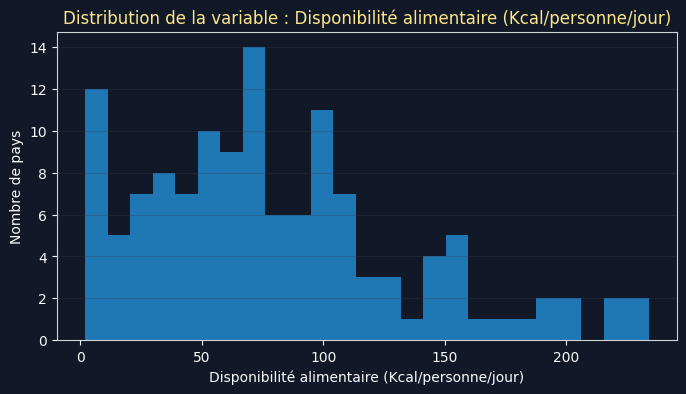

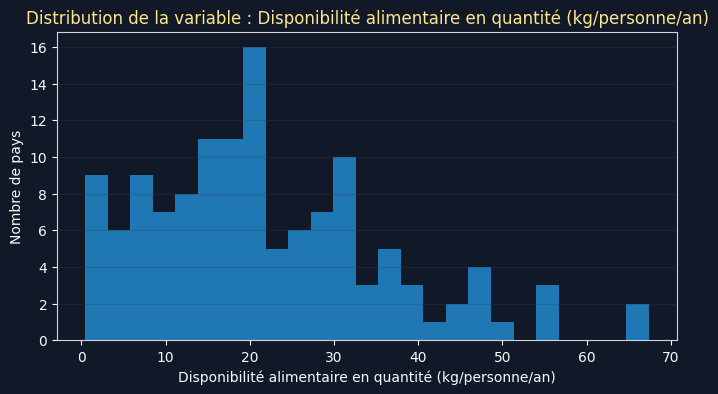

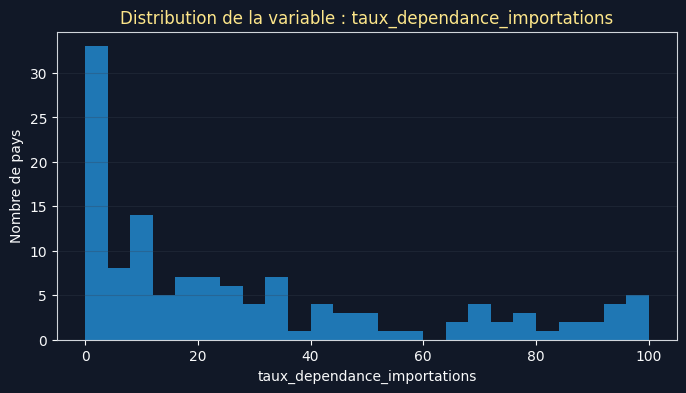

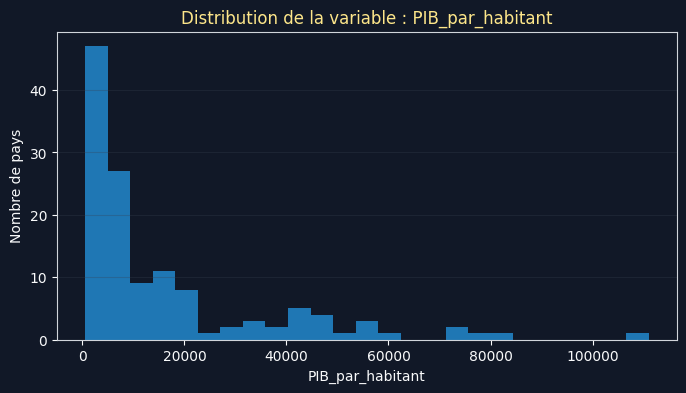

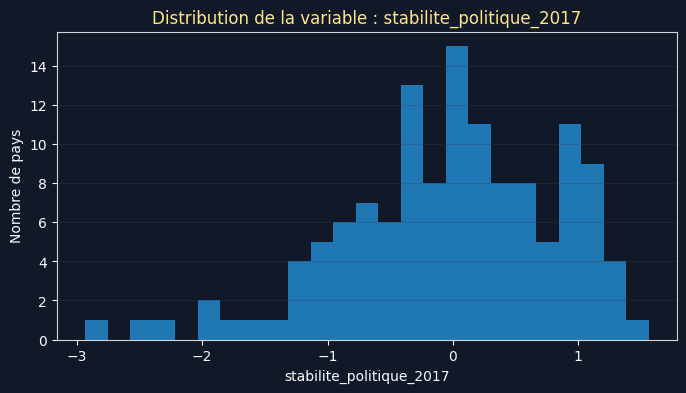

In [110]:
# Histogrammes des principales variables
# Ces graphiques permettent d'observer la forme des distributions avant l'ACP
plt.rcParams.update({
    "figure.facecolor": "#111827",
    "axes.facecolor": "#111827",
    "axes.edgecolor": "#D1D5DB",
    "axes.labelcolor": "#F9FAFB",
    "xtick.color": "#F9FAFB",
    "ytick.color": "#F9FAFB",
    "text.color": "#F9FAFB",
    "axes.titlecolor": "#FDE68A",
    "grid.color": "#374151",
    "figure.edgecolor": "#111827",
    "savefig.facecolor": "#111827",
    "savefig.edgecolor": "#111827"
})

for colonne in variables_distribution:
    plt.figure(figsize=(8, 4))
    plt.hist(df_eda[colonne].dropna(), bins=25)
    plt.title(f"Distribution de la variable : {colonne}")
    plt.xlabel(colonne)
    plt.ylabel("Nombre de pays")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

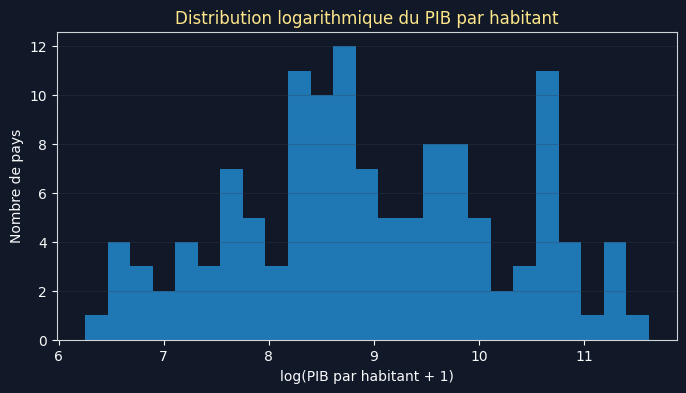

In [111]:
# Distribution logarithmique du PIB par habitant
# Cette transformation aide à lire une variable très asymétrique
plt.figure(figsize=(8, 4))
plt.hist(np.log1p(df_eda["PIB_par_habitant"].dropna()), bins=25)
plt.title("Distribution logarithmique du PIB par habitant")
plt.xlabel("log(PIB par habitant + 1)")
plt.ylabel("Nombre de pays")
plt.grid(axis="y", alpha=0.3)
plt.show()

<div style="max-width: 980px; margin: 35px auto; padding: 24px; border: 1px solid #CA8A04; border-radius: 14px; background: linear-gradient(135deg, rgba(63, 45, 10, 0.94), rgba(24, 24, 27, 0.97)); color: #fff; box-shadow: 0 0 25px rgba(202, 138, 4, 0.25);">

  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <b style="font-size:19px; color:#FDE68A;">📈 Étape 6.2 • Distribution des variables</b>
  </div>
  <p>
    Les distributions des principales variables ont été visualisées afin de mieux comprendre leur forme avant l'ACP.
    Cette étape permet d'identifier les variables symétriques, asymétriques ou fortement concentrées sur certains ordres de grandeur.
  </p>
  <div style="display:grid; grid-template-columns:1fr 1fr; gap:12px; margin-top:18px;">
    <div style="padding:2px; border:1px solid #22C55E; border-radius:10px; background:rgba(20,83,45,0.35);">
      <strong style="color:#86EFAC;">✅ Variables visualisées</strong>
      <ul style="margin-bottom:0;">
        <li>Disponibilité alimentaire en kcal</li>
        <li>Disponibilité alimentaire en quantité</li>
        <li>Taux de dépendance aux importations</li>
        <li>PIB par habitant</li>
        <li>Stabilité politique</li>
      </ul>
    </div>
    <div style="padding:2px; border:1px solid #38BDF8; border-radius:10px; background:rgba(8,47,73,0.35);">
      <strong style="color:#BAE6FD;">🔎 Ce que montrent les graphiques</strong>
      <ul style="margin-bottom:0;">
        <li>Les variables alimentaires sont dispersées mais lisibles</li>
        <li>Le taux de dépendance est très hétérogène selon les pays</li>
        <li>Le PIB par habitant est fortement asymétrique</li>
        <li>La stabilité politique est plus équilibrée autour de valeurs centrales</li>
      </ul>
    </div>
  </div>
  <div style="margin-top:14px; padding:6px; border:1px solid #F59E0B; border-radius:10px; background:rgba(120,53,15,0.35);">
    <strong style="color:#FDE68A;">⚠️ Point de vigilance :</strong>
    <p style="margin-bottom:0;">
      Le PIB par habitant présente une distribution très étirée vers les valeurs élevées. Une lecture logarithmique a donc été ajoutée
      pour mieux visualiser la structure de cette variable sans que les pays les plus riches écrasent l'ensemble du graphique.
    </p>
  </div>
  <div style="margin-top:14px; padding:6px; border:1px solid #A855F7; border-radius:10px; background:rgba(88,28,135,0.28);">
    <strong style="color:#E9D5FF;">📌 Interprétation :</strong>
    <p style="margin-bottom:0;">
      Les distributions confirment que les pays étudiés ne sont pas homogènes : certains marchés sont très grands, d'autres beaucoup plus petits,
      et certains pays présentent une forte dépendance aux importations. Ces différences justifient l'utilisation d'une ACP pour résumer l'information.
    </p>
  </div>
  <div style="margin-top:14px; padding:6px; border:1px solid #22C55E; border-radius:10px; background:rgba(6,78,59,0.35);">
    <strong style="color:#86EFAC;">👉 En clair :</strong>
    <p style="margin-bottom:0;">
      Les variables ont des formes de distribution différentes. La standardisation sera indispensable avant l'ACP afin que les variables à forte amplitude,
      comme le PIB ou la population, ne dominent pas artificiellement l'analyse.
    </p>
  </div>
</div>

<a id="etape6_3"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(253,230,138,0.28);
  border-radius:12px;
  background:rgba(253,230,138,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(92%) sepia(19%) saturate(938%) hue-rotate(335deg) brightness(102%) contrast(101%);
      ">
    </a>
    <span>6.3 • Détection des outliers</span>
  </h3>
</div>

In [112]:
# Sélection des variables sensibles aux effets de taille
# Ces variables permettent d'identifier les pays qui peuvent dominer fortement l'analyse
variables_outliers_taille = [
    "population_2017",
    "PIB_2017",
    "Disponibilité intérieure",
    "Production",
    "Importations - Quantité",
    "Exportations - Quantité"
]

print("Variables utilisées pour la détection des pays très atypiques :")
variables_outliers_taille

Variables utilisées pour la détection des pays très atypiques :


['population_2017',
 'PIB_2017',
 'Disponibilité intérieure',
 'Production',
 'Importations - Quantité',
 'Exportations - Quantité']

In [113]:
# Détection des pays extrêmes par quantile
# Un pays est signalé s'il appartient au top 5 % sur une ou plusieurs variables de taille
df_outliers = df_eda[["Zone"] + variables_outliers_taille].copy()

for colonne in variables_outliers_taille:
    seuil_haut = df_outliers[colonne].quantile(0.95)
    df_outliers[f"top_5pct_{colonne}"] = df_outliers[colonne] >= seuil_haut

colonnes_flags = [col for col in df_outliers.columns if col.startswith("top_5pct_")]

df_outliers["nb_flags_outliers"] = df_outliers[colonnes_flags].sum(axis=1)

display(
    df_outliers[["Zone", "nb_flags_outliers"] + variables_outliers_taille]
    .sort_values(["nb_flags_outliers", "population_2017", "PIB_2017"], ascending=False)
    .head(25)
)

,Zone,nb_flags_outliers,population_2017,PIB_2017,Disponibilité intérieure,Production,Importations - Quantité,Exportations - Quantité
161,États-Unis d'Amérique,5,325.08 millions,19477.34 milliards,18 266,21 914,123.00,3 692
33,"Chine, continentale",4,1.42 milliards,12537.56 milliards,18 161,18 236,452.00,576.00
65,Inde,4,1.34 milliards,2651.47 milliards,3 661,3 545,0.00,4.00
21,Brésil,4,207.83 millions,2063.51 milliards,9 982,14 201,3.00,4 223
74,Japon,3,127.50 millions,4930.84 milliards,2 415,2 215,1 069,10.00
95,Mexique,3,124.78 millions,1190.72 milliards,4 219,3 249,972.00,9.00
4,Allemagne,3,82.66 millions,3765.35 milliards,1 739,1 514,842.00,646.00
51,Fédération de Russie,2,145.53 millions,1574.20 milliards,4 556,4 444,226.00,115.00
120,Royaume-Uni de Grande-Bretagne et d'Irlande du Nord,2,66.73 millions,2699.12 milliards,2 234,1 814,779.00,359.00
115,Pologne,2,37.95 millions,528.36 milliards,1 156,2 351,55.00,1 025


In [114]:
# Liste des pays détectés comme très atypiques
# On ne les exclut pas automatiquement : ils sont d'abord analysés pour décider s'ils déforment trop l'analyse
pays_atypiques = (
    df_outliers[df_outliers["nb_flags_outliers"] >= 1]
    .sort_values(["nb_flags_outliers", "population_2017", "PIB_2017"], ascending=False)
)

print("Nombre de pays atypiques détectés :", pays_atypiques.shape[0])

display(
    pays_atypiques[
        ["Zone", "nb_flags_outliers"] + variables_outliers_taille
    ]
)

Nombre de pays atypiques détectés : 19


,Zone,nb_flags_outliers,population_2017,PIB_2017,Disponibilité intérieure,Production,Importations - Quantité,Exportations - Quantité
161,États-Unis d'Amérique,5,325.08 millions,19477.34 milliards,18 266,21 914,123.00,3 692
33,"Chine, continentale",4,1.42 milliards,12537.56 milliards,18 161,18 236,452.00,576.00
65,Inde,4,1.34 milliards,2651.47 milliards,3 661,3 545,0.00,4.00
21,Brésil,4,207.83 millions,2063.51 milliards,9 982,14 201,3.00,4 223
74,Japon,3,127.50 millions,4930.84 milliards,2 415,2 215,1 069,10.00
95,Mexique,3,124.78 millions,1190.72 milliards,4 219,3 249,972.00,9.00
4,Allemagne,3,82.66 millions,3765.35 milliards,1 739,1 514,842.00,646.00
51,Fédération de Russie,2,145.53 millions,1574.20 milliards,4 556,4 444,226.00,115.00
120,Royaume-Uni de Grande-Bretagne et d'Irlande du Nord,2,66.73 millions,2699.12 milliards,2 234,1 814,779.00,359.00
115,Pologne,2,37.95 millions,528.36 milliards,1 156,2 351,55.00,1 025


In [115]:
# Sélection des outliers majeurs à exclure
# On exclut uniquement les pays détectés comme atypiques sur au moins 4 variables de taille
# L'objectif est d'éviter que quelques très grands pays dominent l'ACP et le clustering
pays_outliers_a_exclure = (
    df_outliers.loc[df_outliers["nb_flags_outliers"] >= 4, "Zone"]
    .tolist()
)

print("Pays outliers majeurs proposés à l'exclusion :")
print(pays_outliers_a_exclure)

print("\nNombre de pays concernés :", len(pays_outliers_a_exclure))

Pays outliers majeurs proposés à l'exclusion :
['Brésil', 'Chine, continentale', 'Inde', "États-Unis d'Amérique"]

Nombre de pays concernés : 4


In [116]:
# Création du dataset exploratoire sans les outliers majeurs
# Ces pays sont retirés pour limiter l'effet de domination des très grandes économies dans les analyses multivariées
df_eda_filtre = df_eda[
    ~df_eda["Zone"].isin(pays_outliers_a_exclure)
].copy()

print("Nombre de pays avant exclusion :", df_eda["Zone"].nunique())
print("Nombre de pays exclus :", len(pays_outliers_a_exclure))
print("Nombre de pays après exclusion :", df_eda_filtre["Zone"].nunique())

display(df_eda_filtre.head())

Nombre de pays avant exclusion : 129
Nombre de pays exclus : 4
Nombre de pays après exclusion : 125


,Zone,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Production,population_2017,PIB_2017,stabilite_politique_2017,taux_dependance_importations,balance_commerciale_quantite,PIB_par_habitant
1,Afrique du Sud,143.00,35.69,2 118,63.00,514.00,1 667,57.01 millions,381.45 milliards,-0.28,23.57,-451.00,6 691
2,Albanie,85.00,16.36,47.00,0.00,38.00,13.00,2.88 millions,13.26 milliards,0.37,74.51,-38.00,4 597
3,Algérie,22.00,6.38,277.00,0.00,2.00,275.00,41.39 millions,189.88 milliards,-0.92,0.72,-2.00,4 588
4,Allemagne,71.00,19.47,1 739,646.00,842.00,1 514,82.66 millions,3765.35 milliards,0.57,35.74,-196.00,45 553
5,Angola,35.00,10.56,319.00,0.00,277.00,42.00,29.82 millions,84.38 milliards,-0.39,86.83,-277.00,2 830


<div style="max-width: 980px; margin: 35px auto; padding: 24px; border: 1px solid #CA8A04; border-radius: 14px; background: linear-gradient(135deg, rgba(63, 45, 10, 0.94), rgba(24, 24, 27, 0.97)); color: #fff; box-shadow: 0 0 25px rgba(202, 138, 4, 0.25);">

  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <b style="font-size:19px; color:#FDE68A;">🚨 Étape 6.3 • Détection des outliers</b>
  </div>
  <p>
    Une détection des pays atypiques a été réalisée sur les variables sensibles aux effets de taille. L'objectif n'est pas de supprimer automatiquement
    tous les pays atypiques, mais d'identifier ceux qui risquent de dominer excessivement l'ACP et le clustering.
  </p>
  <div style="display:grid; grid-template-columns:1fr 1fr; gap:12px; margin-top:18px;">
    <div style="padding:2px; border:1px solid #22C55E; border-radius:10px; background:rgba(20,83,45,0.35);">
      <strong style="color:#86EFAC;">✅ Méthode utilisée</strong>
      <ul style="margin-bottom:0;">
        <li>Repérage des pays dans le top 5 %</li>
        <li>Analyse sur les variables de taille</li>
        <li>Comptage du nombre de variables où chaque pays est atypique</li>
        <li>Exclusion uniquement des cas majeurs</li>
      </ul>
    </div>
    <div style="padding:2px; border:1px solid #38BDF8; border-radius:10px; background:rgba(8,47,73,0.35);">
      <strong style="color:#BAE6FD;">🌍 Pays les plus atypiques</strong>
      <ul style="margin-bottom:0;">
        <li>États-Unis d'Amérique : 5 indicateurs atypiques</li>
        <li>Chine continentale : 4 indicateurs atypiques</li>
        <li>Inde : 4 indicateurs atypiques</li>
        <li>Brésil : 4 indicateurs atypiques</li>
      </ul>
    </div>
  </div>
  <div style="margin-top:14px; padding:6px; border:1px solid #F59E0B; border-radius:10px; background:rgba(120,53,15,0.35);">
    <strong style="color:#FDE68A;">⚠️ Décision méthodologique :</strong>
    <p style="margin-bottom:0;">
      Les pays détectés comme atypiques sur une seule variable ne sont pas exclus automatiquement. Seuls les pays atypiques sur au moins 4 variables
      de taille sont retirés afin de limiter l'effet de domination des très grandes économies tout en conservant un périmètre d'analyse suffisamment large.
    </p>
  </div>
  <div style="margin-top:14px; padding:6px; border:1px solid #F43F5E; border-radius:10px; background:rgba(127,29,29,0.32);">
    <strong style="color:#FDA4AF;">📌 Pays exclus :</strong>
    <p style="margin-bottom:0;">
      4 pays sont proposés à l'exclusion : <strong>Brésil</strong>, <strong>Chine continentale</strong>, <strong>Inde</strong> et
      <strong>États-Unis d'Amérique</strong>. Ces pays correspondent à de très grands marchés qui peuvent écraser les autres profils dans les analyses multivariées.
    </p>
  </div>
  <div style="margin-top:14px; padding:6px; border:1px solid #22C55E; border-radius:10px; background:rgba(6,78,59,0.35);">
    <strong style="color:#86EFAC;">👉 En clair :</strong>
    <p style="margin-bottom:0;">
      La détection des outliers permet de sécuriser la suite de l'analyse. Le dataset reste représentatif avec 125 pays après exclusion,
      tout en réduisant le risque que quelques très grandes économies dominent l'ACP et le clustering.
    </p>
  </div>
</div>

<a id="etape6_4"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(253,230,138,0.28);
  border-radius:12px;
  background:rgba(253,230,138,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(92%) sepia(19%) saturate(938%) hue-rotate(335deg) brightness(102%) contrast(101%);
      ">
    </a>
    <span>6.4 • Première lecture business des profils pays</span>
  </h3>
</div>

In [117]:
# Première lecture business des profils pays
# Cette étape donne une première intuition sur les profils de pays avant l'ACP et le clustering
# Elle ne remplace pas l'analyse finale, mais permet d'identifier quelques tendances métier
colonnes_lecture_business = [
    "Zone",
    "Disponibilité alimentaire (Kcal/personne/jour)",
    "Disponibilité alimentaire en quantité (kg/personne/an)",
    "Importations - Quantité",
    "Exportations - Quantité",
    "taux_dependance_importations",
    "balance_commerciale_quantite",
    "PIB_par_habitant",
    "stabilite_politique_2017"
]

lecture_business = df_eda[
    colonnes_lecture_business
].copy()

display(lecture_business.head())

,Zone,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Importations - Quantité,Exportations - Quantité,taux_dependance_importations,balance_commerciale_quantite,PIB_par_habitant,stabilite_politique_2017
1,Afrique du Sud,143.00,35.69,514.00,63.00,23.57,-451.00,6 691,-0.28
2,Albanie,85.00,16.36,38.00,0.00,74.51,-38.00,4 597,0.37
3,Algérie,22.00,6.38,2.00,0.00,0.72,-2.00,4 588,-0.92
4,Allemagne,71.00,19.47,842.00,646.00,35.74,-196.00,45 553,0.57
5,Angola,35.00,10.56,277.00,0.00,86.83,-277.00,2 830,-0.39


In [118]:
# Pays les plus dépendants aux importations
# Ces pays peuvent représenter des marchés déjà habitués à importer de la viande de volailles
top_import_dependance = lecture_business.sort_values(
    "taux_dependance_importations",
    ascending=False
).head(10)

display(top_import_dependance)

,Zone,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Importations - Quantité,Exportations - Quantité,taux_dependance_importations,balance_commerciale_quantite,PIB_par_habitant,stabilite_politique_2017
6,Antigua-et-Barbuda,233.00,54.10,7.00,0.00,100.00,-7.00,16 084,0.73
163,Îles Salomon,18.00,4.45,6.00,0.00,100.00,-6.00,2 311,0.19
43,Dominique,150.00,35.19,4.00,0.00,100.00,-4.00,7 884,1.17
129,Samoa,217.00,64.77,17.00,0.00,100.00,-17.00,4 529,1.16
85,Luxembourg,69.00,18.33,11.00,1.00,100.00,-10.00,111 017,1.31
86,Macédoine du Nord,68.00,19.73,40.00,1.00,95.24,-39.00,5 431,-0.26
52,Gabon,99.00,29.33,76.00,0.00,95.00,-76.00,7 230,-0.11
107,Oman,73.00,21.63,126.00,16.00,94.74,-110.00,17 329,0.75
36,Congo,72.00,21.53,104.00,0.00,93.69,-104.00,2 316,-0.53
159,Émirats arabes unis,147.00,43.47,433.00,94.00,90.02,-339.00,42 517,0.60


In [119]:
# Pays avec les meilleurs profils économiques parmi les pays dépendants aux importations
# On croise ici dépendance aux importations, PIB par habitant et stabilité politique
profils_interessants = lecture_business[
    lecture_business["taux_dependance_importations"] >= lecture_business["taux_dependance_importations"].median()
].sort_values(
    ["PIB_par_habitant", "stabilite_politique_2017"],
    ascending=False
).head(10)

display(profils_interessants)

,Zone,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Importations - Quantité,Exportations - Quantité,taux_dependance_importations,balance_commerciale_quantite,PIB_par_habitant,stabilite_politique_2017
85,Luxembourg,69.00,18.33,11.00,1.00,100.00,-10.00,111 017,1.31
137,Suisse,55.00,15.72,51.00,4.00,35.92,-47.00,82 216,1.24
69,Irlande,100.00,25.82,99.00,93.00,47.37,-6.00,73 287,0.99
41,Danemark,112.00,28.98,133.00,139.00,43.46,6.00,57 850,0.85
139,Suède,61.00,16.60,84.00,23.00,34.85,-61.00,54 031,0.97
113,Pays-Bas,70.00,20.33,608.00,1 418,35.60,810.00,49 834,0.91
11,Autriche,65.00,18.20,110.00,78.00,42.64,-32.00,47 044,1.03
4,Allemagne,71.00,19.47,842.00,646.00,35.74,-196.00,45 553,0.57
16,Belgique,44.00,12.65,338.00,656.00,42.20,318.00,43 863,0.42
159,Émirats arabes unis,147.00,43.47,433.00,94.00,90.02,-339.00,42 517,0.60


<div style="max-width: 980px; margin: 35px auto; padding: 24px; border: 1px solid #CA8A04; border-radius: 14px; background: linear-gradient(135deg, rgba(63, 45, 10, 0.94), rgba(24, 24, 27, 0.97)); color: #fff; box-shadow: 0 0 25px rgba(202, 138, 4, 0.25);">

  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <b style="font-size:19px; color:#FDE68A;">💼 Étape 6.4 • Première lecture business des profils pays</b>
  </div>
  <p>
    Une première lecture métier a été réalisée afin d'identifier quelques tendances avant l'ACP et le clustering.
    Cette étape ne remplace pas l'analyse finale, mais elle permet déjà de repérer des profils de pays potentiellement intéressants pour l'exportation.
  </p>
  <div style="display:grid; grid-template-columns:1fr 1fr; gap:12px; margin-top:18px;">
    <div style="padding:2px; border:1px solid #22C55E; border-radius:10px; background:rgba(20,83,45,0.35);">
      <strong style="color:#86EFAC;">✅ Pays dépendants aux importations</strong>
      <ul style="margin-bottom:0;">
        <li>Certains pays ont un taux de dépendance proche de 100 %</li>
        <li>Ces marchés produisent peu ou pas localement</li>
        <li>Ils peuvent représenter des marchés déjà habitués à importer</li>
        <li>La dépendance seule ne suffit pas à prioriser un pays</li>
      </ul>
    </div>
    <div style="padding:2px; border:1px solid #38BDF8; border-radius:10px; background:rgba(8,47,73,0.35);">
      <strong style="color:#BAE6FD;">🌍 Profils économiques intéressants</strong>
      <ul style="margin-bottom:0;">
        <li>PIB par habitant élevé</li>
        <li>Stabilité politique favorable</li>
        <li>Dépendance aux importations significative</li>
        <li>Marchés potentiellement plus accessibles commercialement</li>
      </ul>
    </div>
  </div>
  <div style="margin-top:14px; padding:6px; border:1px solid #A855F7; border-radius:10px; background:rgba(88,28,135,0.28);">
    <strong style="color:#E9D5FF;">📌 Exemples de profils repérés :</strong>
    <p style="margin-bottom:0;">
      Parmi les pays dépendants aux importations, certains présentent également un PIB par habitant élevé et une stabilité politique positive,
      comme le Luxembourg, la Suisse, l'Irlande, le Danemark, la Suède ou encore les Pays-Bas. Ces profils pourront être étudiés plus finement après clustering.
    </p>
  </div>
  <div style="margin-top:14px; padding:6px; border:1px solid #F59E0B; border-radius:10px; background:rgba(120,53,15,0.35);">
    <strong style="color:#FDE68A;">⚠️ Limite de lecture :</strong>
    <p style="margin-bottom:0;">
      Cette lecture reste volontairement exploratoire. Elle ne constitue pas encore une recommandation finale, car les pays doivent être comparés
      sur l'ensemble des variables et regroupés par profils cohérents via l'ACP et le clustering.
    </p>
  </div>
  <div style="margin-top:14px; padding:6px; border:1px solid #22C55E; border-radius:10px; background:rgba(6,78,59,0.35);">
    <strong style="color:#86EFAC;">👉 En clair :</strong>
    <p style="margin-bottom:0;">
      Cette étape donne une première intuition business : les marchés les plus intéressants ne sont pas seulement ceux qui importent beaucoup,
      mais ceux qui combinent dépendance aux importations, pouvoir d'achat et stabilité politique.
    </p>
  </div>
</div>

<a id="etape6_5"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(253,230,138,0.28);
  border-radius:12px;
  background:rgba(253,230,138,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(92%) sepia(19%) saturate(938%) hue-rotate(335deg) brightness(102%) contrast(101%);
      ">
    </a>
    <span>6.5 Création du dataset retenu pour la suite</span>
  </h3>
</div>

In [120]:
# Création du dataset retenu pour la suite
# Ce fichier servira de base propre pour le notebook d'ACP et de clustering
dataset_retenu = df_eda_filtre.copy()

print("Dimensions du dataset retenu :", dataset_retenu.shape)
print("Nombre de pays retenus :", dataset_retenu["Zone"].nunique())

display(dataset_retenu.head())

Dimensions du dataset retenu : (125, 13)
Nombre de pays retenus : 125


,Zone,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Production,population_2017,PIB_2017,stabilite_politique_2017,taux_dependance_importations,balance_commerciale_quantite,PIB_par_habitant
1,Afrique du Sud,143.00,35.69,2 118,63.00,514.00,1 667,57.01 millions,381.45 milliards,-0.28,23.57,-451.00,6 691
2,Albanie,85.00,16.36,47.00,0.00,38.00,13.00,2.88 millions,13.26 milliards,0.37,74.51,-38.00,4 597
3,Algérie,22.00,6.38,277.00,0.00,2.00,275.00,41.39 millions,189.88 milliards,-0.92,0.72,-2.00,4 588
4,Allemagne,71.00,19.47,1 739,646.00,842.00,1 514,82.66 millions,3765.35 milliards,0.57,35.74,-196.00,45 553
5,Angola,35.00,10.56,319.00,0.00,277.00,42.00,29.82 millions,84.38 milliards,-0.39,86.83,-277.00,2 830


In [121]:
# Export du dataset retenu au format CSV
# Le fichier exporté pourra être réutilisé dans le notebook suivant consacré à l'ACP et au clustering

# dataset_retenu.to_csv(
#     "data/dataset_pays_volaille_retenu.csv",
#     index=False,
#     encoding="utf-8-sig"
# )

# print("✅ Fichier CSV exporté : dataset_pays_volaille_retenu.csv")

<div style="max-width: 980px; margin: 35px auto; padding: 24px; border: 1px solid #CA8A04; border-radius: 14px; background: linear-gradient(135deg, rgba(63, 45, 10, 0.94), rgba(24, 24, 27, 0.97)); color: #fff; box-shadow: 0 0 25px rgba(202, 138, 4, 0.25);">

  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <b style="font-size:19px; color:#FDE68A;">📦 Étape 6.5 • Création du dataset retenu pour la suite</b>
  </div>
  <p>
    Un dataset retenu a été créé à partir du dataset exploratoire après exclusion des outliers majeurs.
    Ce fichier constitue la base propre qui sera utilisée dans le notebook suivant pour l'ACP et le clustering.
  </p>
  <div style="display:grid; grid-template-columns:1fr 1fr; gap:12px; margin-top:18px;">
    <div style="padding:2px; border:1px solid #22C55E; border-radius:10px; background:rgba(20,83,45,0.35);">
      <strong style="color:#86EFAC;">✅ Dataset retenu</strong>
      <ul style="margin-bottom:0;">
        <li>125 pays conservés après exclusion</li>
        <li>13 colonnes conservées</li>
        <li>Variables alimentaires, économiques et politiques intégrées</li>
        <li>Base prête pour l'ACP et le clustering</li>
      </ul>
    </div>
    <div style="padding:2px; border:1px solid #38BDF8; border-radius:10px; background:rgba(8,47,73,0.35);">
      <strong style="color:#BAE6FD;">📁 Export prévu</strong>
      <ul style="margin-bottom:0;">
        <li>Nom du fichier : dataset_pays_volaille_retenu.csv</li>
        <li>Format : CSV</li>
        <li>Encodage conseillé : utf-8-sig</li>
        <li>Réutilisable dans le notebook d'ACP</li>
      </ul>
    </div>
  </div>
  <div style="margin-top:14px; padding:6px; border:1px solid #F59E0B; border-radius:10px; background:rgba(120,53,15,0.35);">
    <strong style="color:#FDE68A;">📌 Choix méthodologique :</strong>
    <p style="margin-bottom:0;">
      Les outliers majeurs ont été retirés afin de limiter l'effet de domination des très grandes économies.
      Le dataset final reste largement au-dessus du seuil minimal demandé de 100 pays, avec 125 pays retenus.
    </p>
  </div>
  <div style="margin-top:14px; padding:6px; border:1px solid #A855F7; border-radius:10px; background:rgba(88,28,135,0.28);">
    <strong style="color:#E9D5FF;">🔎 Rôle du fichier exporté :</strong>
    <p style="margin-bottom:0;">
      Ce fichier permettra de séparer clairement la phase de préparation/nettoyage de la phase d'analyse multivariée.
      Le notebook suivant pourra repartir directement d'une base propre, documentée et cohérente.
    </p>
  </div>
  <div style="margin-top:14px; padding:6px; border:1px solid #22C55E; border-radius:10px; background:rgba(6,78,59,0.35);">
    <strong style="color:#86EFAC;">👉 En clair :</strong>
    <p style="margin-bottom:0;">
      Le dataset exploratoire est maintenant transformé en base retenue pour la suite : 125 pays, des variables complètes,
      des outliers majeurs retirés, et un fichier prêt à être exporté pour l'ACP et le clustering.
    </p>
  </div>
</div>

<a id="conclusion1"></a>
<div style="
  width:78%;
  margin:18px auto 14px auto;
  border:1px solid rgba(34,211,238,0.34);
  border-radius:14px;
  background:linear-gradient(135deg, rgba(5,72,86,0.96), rgba(4,34,42,0.98));
  box-sizing:border-box;
">
  <h2 style="
    margin:0;
    padding:15px 20px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:22px;
    font-weight:750;
    gap:12px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:24px; height:24px; display:block;
        filter: brightness(0) saturate(100%) invert(82%) sepia(22%) saturate(1433%) hue-rotate(148deg) brightness(104%) contrast(102%);
      ">
    </a>
    <span style="color:#FFFFFF;">✅ Conclusion • Synthèse du notebook 1</span>
  </h2>
</div>

<div style="max-width: 1050px; margin: 40px auto; padding: 26px; border: 1px solid #0891B2; border-radius: 16px; background: linear-gradient(135deg, rgba(8, 47, 73, 0.94), rgba(15, 23, 42, 0.97)); color: #fff; box-shadow: 0 0 28px rgba(8, 145, 178, 0.28);">

  <div style="display:flex; align-items:center; gap:10px; margin-bottom:14px;">
    <b style="font-size:21px; color:#A5F3FC;">✅ Conclusion • Synthèse du notebook 1</b>
  </div>
  <p>
    Ce premier notebook avait pour objectif de préparer une base de données fiable, exploitable et cohérente pour identifier des groupes de pays
    potentiellement intéressants pour l’exportation de viande de volailles. Le travail a permis de passer de fichiers sources bruts à un dataset final
    structuré, enrichi et prêt pour l’analyse multivariée.
  </p>
  <div style="display:grid; grid-template-columns:1fr 1fr; gap:12px; margin-top:18px;">
    <div style="padding:4px; border:1px solid #22C55E; border-radius:11px; background:rgba(20,83,45,0.35);">
      <strong style="color:#86EFAC;">📦 Dataset final retenu</strong>
      <ul style="margin-bottom:0;">
        <li><strong>125 pays</strong> conservés pour la suite</li>
        <li><strong>13 colonnes</strong> disponibles</li>
        <li>Minimum de <strong>100 pays</strong> respecté</li>
        <li>Base prête pour l’ACP et le clustering</li>
      </ul>
    </div>
    <div style="padding:4px; border:1px solid #38BDF8; border-radius:11px; background:rgba(8,47,73,0.38);">
      <strong style="color:#BAE6FD;">🌍 Sources et enrichissement</strong>
      <ul style="margin-bottom:0;">
        <li>Données FAO sur la viande de volailles</li>
        <li>Population 2017 intégrée</li>
        <li>PIB 2017 ajouté</li>
        <li>Stabilité politique 2017 ajoutée</li>
      </ul>
    </div>
  </div>
  <div style="display:grid; grid-template-columns:1fr 1fr; gap:12px; margin-top:14px;">
    <div style="padding:4px; border:1px solid #F59E0B; border-radius:11px; background:rgba(120,53,15,0.35);">
      <strong style="color:#FDE68A;">🧹 Nettoyage réalisé</strong>
      <ul style="margin-bottom:0;">
        <li>Filtrage sur l’année <strong>2017</strong></li>
        <li>Sélection du produit <strong>Viande de Volailles</strong></li>
        <li>Pivot des indicateurs par pays</li>
        <li>Contrôle des types, unités, doublons et valeurs manquantes</li>
      </ul>
    </div>
    <div style="padding:4px; border:1px solid #A855F7; border-radius:11px; background:rgba(88,28,135,0.30);">
      <strong style="color:#E9D5FF;">🧪 Variables préparées</strong>
      <ul style="margin-bottom:0;">
        <li>Disponibilité alimentaire en kcal</li>
        <li>Disponibilité alimentaire en quantité</li>
        <li>Production, importations et exportations</li>
        <li>Dépendance aux importations, balance commerciale et PIB par habitant</li>
      </ul>
    </div>
  </div>
  <div style="margin-top:14px; padding:6px; border:1px solid #F43F5E; border-radius:11px; background:rgba(127,29,29,0.32);">
    <strong style="color:#FDA4AF;">🚨 Gestion des pays atypiques :</strong>
    <p style="margin-bottom:0;">
      Les petits territoires peu représentatifs ont été exclus en amont afin de fiabiliser le périmètre d’analyse.
      Les très grands outliers économiques et démographiques ont ensuite été identifiés : <strong>Brésil</strong>,
      <strong>Chine continentale</strong>, <strong>Inde</strong> et <strong>États-Unis d’Amérique</strong> ont été retirés du dataset retenu
      afin d’éviter qu’ils dominent excessivement l’ACP et le clustering.
    </p>
  </div>
  <div style="margin-top:14px; padding:6px; border:1px solid #FACC15; border-radius:11px; background:rgba(113,63,18,0.35);">
    <strong style="color:#FEF08A;">📌 Lecture business intermédiaire :</strong>
    <p style="margin-bottom:0;">
      Une première lecture exploratoire montre que les marchés les plus intéressants ne sont pas uniquement les plus grands.
      Les pays à étudier en priorité seront probablement ceux qui combinent une dépendance aux importations, un pouvoir d’achat suffisant,
      une stabilité politique correcte et une consommation de volaille déjà existante.
    </p>
  </div>
  <div style="margin-top:14px; padding:6px; border:1px solid #22C55E; border-radius:11px; background:rgba(6,78,59,0.36);">
    <strong style="color:#86EFAC;">✅ Résultat final :</strong>
    <p style="margin-bottom:0;">
      Le notebook 1 aboutit à un fichier propre et documenté : <strong>dataset_pays_volaille_retenu.csv</strong>.
      Ce dataset servira de base au notebook suivant, consacré à la réduction de dimension par <strong>ACP</strong>,
      puis au regroupement des pays par <strong>classification ascendante hiérarchique</strong> et <strong>k-means</strong>.
    </p>
  </div>
  <div style="margin-top:14px; padding:6px; border:1px solid #06B6D4; border-radius:11px; background:rgba(22,78,99,0.35);">
    <strong style="color:#A5F3FC;">👉 En clair :</strong>
    <p style="margin-bottom:0;">
      La phase de préparation est terminée : les données sont nettoyées, enrichies, contrôlées et exportées.
      Le projet peut maintenant passer à l’analyse multivariée pour construire des groupes de pays et formuler des recommandations d’expansion internationale.
    </p>
  </div>
</div>